<a href="https://colab.research.google.com/github/don-jose07/EDA-for-Hotel-Booking-Data/blob/main/EDA_for_Hotel_Booking_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Exploratory Data Analysis (EDA) for Hotel Booking Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('hotel_booking_dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [2]:
# Get a concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type                   25180 non-null  object 
 2   Hotel_Location               25074 non-null  object 
 3   Booking_Date                 25180 non-null  object 
 4   Arrival_Date                 25180 non-null  object 
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  object 
 12  Market_Segment               25180 non-null  object 
 13  Distribution_Cha

### 1.2. Handle Missing Values

In [16]:
# Calculate the percentage of missing values for each column
missing_values_percentage = df.isnull().sum() / len(df) * 100

# Display columns with missing values and their percentages, sorted in descending order
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': missing_values_percentage
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(by='Missing_Percentage', ascending=False)
display(missing_data)

# Decision on how to handle missing values based on their percentage and nature

# 'Company_ID' has a very high percentage of missing values, likely not useful. Drop it.
if 'Company_ID' in df.columns:
    df.drop('Company_ID', axis=1, inplace=True)
    print("Dropped 'Company_ID' due to high number of missing values.")
else:
    print("'Company_ID' column not found or already dropped.")

# Impute missing values for 'Children' with 0 (as it's a count and NaN likely means no children)
df['Children'] = df['Children'].fillna(0)

# For 'Agent_ID', 'Satisfaction_Score', 'ADR', we can impute with the median or mean depending on distribution.
# Let's use the median for now, as it's more robust to outliers.
df['Agent_ID'] = df['Agent_ID'].fillna(df['Agent_ID'].median())
df['ADR'] = df['ADR'].fillna(df['ADR'].median())
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median())

# For categorical columns 'Hotel_Location', 'Country', 'Meal_Type', impute with the mode
df['Hotel_Location'] = df['Hotel_Location'].fillna(df['Hotel_Location'].mode()[0])
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])
df['Meal_Type'] = df['Meal_Type'].fillna(df['Meal_Type'].mode()[0])

# Convert 'Children' and 'Agent_ID' to integer type after imputation
df['Children'] = df['Children'].astype(int)
df['Agent_ID'] = df['Agent_ID'].astype(int)

print("Missing values imputed and data types adjusted for 'Children' and 'Agent_ID'.")

# Verify that there are no more missing values
print("\nMissing values after handling:")
display(df.isnull().sum().sort_values(ascending=False))

,Missing_Count,Missing_Percentage


'Company_ID' column not found or already dropped.
Missing values imputed and data types adjusted for 'Children' and 'Agent_ID'.

Missing values after handling:


,0
Booking_ID,0
Hotel_Type,0
Hotel_Location,0
Booking_Date,0
Arrival_Date,0
Lead_Time_Days,0
Weekend_Nights,0
Weekday_Nights,0
Adults,0
Children,0


### 1.3. Inconsistent Values (Categorical Data)

In [20]:
# Check unique values for categorical columns to identify inconsistencies

# Define categorical columns to check (excluding Booking_ID, dates, and numerical)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Unique values for categorical columns (top 10 if many):")
for col in categorical_cols:
    print(f"\nColumn '{col}':")
    unique_vals = df[col].unique()
    if len(unique_vals) > 10:
        print(unique_vals[:10], "... (truncated)")
    else:
        print(unique_vals)

# Specific checks for columns identified from initial df.describe(include='all') or df.info()
print("\nUnique values for 'Reservation_Status':", df['Reservation_Status'].unique())
print("Unique values for 'Hotel_Type':", df['Hotel_Type'].unique())
print("Unique values for 'Market_Segment':", df['Market_Segment'].unique())
print("Unique values for 'Distribution_Channel':", df['Distribution_Channel'].unique())
print("Unique values for 'Deposit_Type':", df['Deposit_Type'].unique())
print("Unique values for 'Customer_Type':", df['Customer_Type'].unique())
print("Unique values for 'Meal_Type':", df['Meal_Type'].unique())
print("Unique values for 'Room_Type_Reserved':", df['Room_Type_Reserved'].unique())
print("Unique values for 'Room_Type_Assigned':", df['Room_Type_Assigned'].unique())
print("Unique values for 'Country':", df['Country'].unique())
print("Unique values for 'Hotel_Location':", df['Hotel_Location'].unique())

# Standardize inconsistent categorical values
# Convert to lowercase and strip whitespace for consistency
df['Hotel_Type'] = df['Hotel_Type'].str.lower().str.strip().replace({'city hotel': 'City Hotel', 'resort hotel': 'Resort Hotel'})
df['Market_Segment'] = df['Market_Segment'].str.lower().str.strip().replace({'online ta': 'Online TA'})
df['Meal_Type'] = df['Meal_Type'].str.lower().str.strip().replace({'bb': 'BB', 'b&b': 'BB', 'undefined': 'Undefined', 'sc': 'SC', 'fb': 'FB', 'hb': 'HB', 'unknown': 'Unknown'})
df['Hotel_Location'] = df['Hotel_Location'].str.strip()

print("\nStandardized inconsistent categorical values in 'Hotel_Type', 'Market_Segment', 'Meal_Type', 'Hotel_Location'.")

# Re-check unique values after standardization (optional, for verification)
print("\nUnique values for 'Hotel_Type' after standardization:", df['Hotel_Type'].unique())
print("Unique values for 'Market_Segment' after standardization:", df['Market_Segment'].unique())
print("Unique values for 'Meal_Type' after standardization:", df['Meal_Type'].unique())

# Data Cleaning - Room Type Consistency check (Reserved vs. Assigned)
# Create a new feature to indicate if the assigned room type is different from the reserved one.
df['Is_Room_Type_Changed'] = (df['Room_Type_Reserved'] != df['Room_Type_Assigned']).astype(int)
print("\nAdded 'Is_Room_Type_Changed' column.")

Unique values for categorical columns (top 10 if many):

Column 'Booking_ID':
['HTL024548' 'HTL019878' 'HTL017377' 'HTL003352' 'HTL012521' 'HTL014174'
 'HTL005872' 'HTL015091' 'HTL009423' 'HTL001216'] ... (truncated)

Column 'Hotel_Type':
['City Hotel' 'Resort Hotel' 'CITY HOTEL' 'city hotel' 'City hotel']

Column 'Hotel_Location':
['London' 'Lisbon' 'Dubai' 'Maldives' 'Amsterdam' 'Algarve' 'Barcelona'
 'Goa' 'Bali' 'Phuket'] ... (truncated)

Column 'Country':
['ARE' 'JPN' 'POL' 'CAN' 'PRT' 'DNK' 'BRA' 'AUS' 'GBR' 'ESP'] ... (truncated)

Column 'Market_Segment':
['Direct' 'Groups' 'Online TA' 'Offline TA/TO' 'Online TA ' 'Corporate'
 'online ta' 'ONLINE TA']

Column 'Distribution_Channel':
['Direct' 'TA/TO' 'Corporate']

Column 'Room_Type_Reserved':
['H' 'D' 'C' 'G' 'A' 'E' 'B' 'F']

Column 'Room_Type_Assigned':
['H' 'D' 'C' 'E' 'G' 'B' 'A' 'F']

Column 'Deposit_Type':
['Non Refund' 'No Deposit' 'Refundable']

Column 'Customer_Type':
['Contract' 'Transient' 'Group' 'Transient-Party']



In [3]:
# Generate descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution
display(df.describe(include='all'))

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
count,25180,25180,25074,25180,25180,25180.000000,25180.000000,25180.000000,25180.000000,25059.000000,...,24935,25180.000000,25098.000000,25180.000000,25180.000000,25016.000000,25180,25180.000000,25180,25180.000000
unique,25000,5,11,731,1073,NaN,NaN,NaN,NaN,NaN,...,9,NaN,NaN,NaN,NaN,NaN,3,NaN,1076,NaN
top,HTL004101,City Hotel,Dubai,2025-12-10,2026-01-02,NaN,NaN,NaN,NaN,NaN,...,BB,NaN,NaN,NaN,NaN,NaN,Canceled,NaN,2025-02-26,NaN
freq,2,15606,3171,58,54,NaN,NaN,NaN,NaN,NaN,...,5027,NaN,NaN,NaN,NaN,NaN,16723,NaN,55,NaN
mean,NaN,NaN,NaN,NaN,NaN,182.200556,1.240429,2.451072,2.198967,0.372122,...,NaN,3.693090,140.628124,0.228753,1.097458,3.854402,NaN,0.721763,NaN,535.495478
std,NaN,NaN,NaN,NaN,NaN,105.604452,1.063802,2.031003,0.662379,0.657811,...,NaN,2.085623,47.808034,0.530060,1.047671,0.405110,NaN,0.448140,NaN,389.700003
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.000000,0.000000,...,NaN,1.000000,30.800000,0.000000,0.000000,0.300000,NaN,0.000000,NaN,31.820000
25%,NaN,NaN,NaN,NaN,NaN,91.000000,0.000000,1.000000,2.000000,0.000000,...,NaN,2.000000,105.620000,0.000000,0.000000,3.590000,NaN,0.000000,NaN,230.540000
50%,NaN,NaN,NaN,NaN,NaN,182.000000,1.000000,2.000000,2.000000,0.000000,...,NaN,4.000000,134.425000,0.000000,1.000000,3.860000,NaN,1.000000,NaN,448.735000
75%,NaN,NaN,NaN,NaN,NaN,273.000000,2.000000,4.000000,2.000000,1.000000,...,NaN,5.000000,169.097500,0.000000,2.000000,4.130000,NaN,1.000000,NaN,737.577500


## 1. Data Quality Assessment and Cleaning
### 1.1. Handle Duplicate Records

In [8]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Check for duplicate 'Booking_ID' values
duplicate_booking_ids = df['Booking_ID'].duplicated().sum()
print(f"Number of duplicate Booking_IDs: {duplicate_booking_ids}")

# Drop duplicate rows if any exist
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed. New shape: {df.shape}")

# Drop duplicate 'Booking_ID' if any exist (keeping the first occurrence)
if duplicate_booking_ids > 0:
    # Assuming the first occurrence is the correct one, or we need to investigate further
    df.drop_duplicates(subset='Booking_ID', keep='first', inplace=True)
    print(f"Duplicate Booking_IDs removed. New shape: {df.shape}")

Number of duplicate rows: 0
Number of duplicate Booking_IDs: 0


### 1.2. Correct Data Types

In [9]:
# Convert date columns to datetime objects
date_columns = ['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Display data types after conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Booking_ID                   25000 non-null  object        
 1   Hotel_Type                   25000 non-null  object        
 2   Hotel_Location               25000 non-null  object        
 3   Booking_Date                 25000 non-null  datetime64[ns]
 4   Arrival_Date                 25000 non-null  datetime64[ns]
 5   Lead_Time_Days               25000 non-null  int64         
 6   Weekend_Nights               25000 non-null  int64         
 7   Weekday_Nights               25000 non-null  int64         
 8   Adults                       25000 non-null  int64         
 9   Children                     25000 non-null  int64         
 10  Babies                       25000 non-null  int64         
 11  Country                      25000 non-null  o

### 1.3. Handle Missing Values

In [17]:
# Calculate the percentage of missing values for each column
missing_values_percentage = df.isnull().sum() / len(df) * 100

# Display columns with missing values and their percentages, sorted in descending order
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': missing_values_percentage
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(by='Missing_Percentage', ascending=False)
display(missing_data)

# Decision on how to handle missing values based on their percentage and nature

# 'Company_ID' has a very high percentage of missing values, likely not useful. Drop it.
if 'Company_ID' in df.columns:
    df.drop('Company_ID', axis=1, inplace=True)
    print("Dropped 'Company_ID' due to high number of missing values.")
else:
    print("'Company_ID' column not found or already dropped.")

# Impute missing values for 'Children' with 0 (as it's a count and NaN likely means no children)
df['Children'] = df['Children'].fillna(0)

# For 'Agent_ID', 'Satisfaction_Score', 'ADR', we can impute with the median or mean depending on distribution.
# Let's use the median for now, as it's more robust to outliers.
df['Agent_ID'] = df['Agent_ID'].fillna(df['Agent_ID'].median())
df['ADR'] = df['ADR'].fillna(df['ADR'].median())
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median())

# For categorical columns 'Hotel_Location', 'Country', 'Meal_Type', impute with the mode
df['Hotel_Location'] = df['Hotel_Location'].fillna(df['Hotel_Location'].mode()[0])
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])
df['Meal_Type'] = df['Meal_Type'].fillna(df['Meal_Type'].mode()[0])

# Convert 'Children' and 'Agent_ID' to integer type after imputation
df['Children'] = df['Children'].astype(int)
df['Agent_ID'] = df['Agent_ID'].astype(int)

print("Missing values imputed and data types adjusted for 'Children' and 'Agent_ID'.")

# Verify that there are no more missing values
print("\nMissing values after handling:")
display(df.isnull().sum().sort_values(ascending=False))

,Missing_Count,Missing_Percentage


'Company_ID' column not found or already dropped.
Missing values imputed and data types adjusted for 'Children' and 'Agent_ID'.

Missing values after handling:


,0
Booking_ID,0
Hotel_Type,0
Hotel_Location,0
Booking_Date,0
Arrival_Date,0
Lead_Time_Days,0
Weekend_Nights,0
Weekday_Nights,0
Adults,0
Children,0


In [26]:
# Re-executing cell to handle missing values after modification
# Calculate the percentage of missing values for each column
missing_values_percentage = df.isnull().sum() / len(df) * 100

# Display columns with missing values and their percentages, sorted in descending order
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': missing_values_percentage
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(by='Missing_Percentage', ascending=False)
display(missing_data)

# 'Company_ID' has a very high percentage of missing values, likely not useful. Drop it.
if 'Company_ID' in df.columns:
    df.drop('Company_ID', axis=1, inplace=True)
    print("Dropped 'Company_ID' due to high number of missing values.")
else:
    print("'Company_ID' column not found or already dropped.")

# Impute missing values for 'Children' with 0 (as it's a count and NaN likely means no children)
df['Children'] = df['Children'].fillna(0)

# For 'Agent_ID', 'Satisfaction_Score', 'ADR', we can impute with the median or mean depending on distribution.
# Let's use the median for now, as it's more robust to outliers.
df['Agent_ID'] = df['Agent_ID'].fillna(df['Agent_ID'].median())
df['ADR'] = df['ADR'].fillna(df['ADR'].median())
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median())

# For categorical columns 'Hotel_Location', 'Country', 'Meal_Type', impute with the mode
df['Hotel_Location'] = df['Hotel_Location'].fillna(df['Hotel_Location'].mode()[0])
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])
df['Meal_Type'] = df['Meal_Type'].fillna(df['Meal_Type'].mode()[0])

# Convert 'Children' and 'Agent_ID' to integer type after imputation
df['Children'] = df['Children'].astype(int)
df['Agent_ID'] = df['Agent_ID'].astype(int)

print("Missing values imputed and data types adjusted for 'Children' and 'Agent_ID'.")

# Verify that there are no more missing values
print("\nMissing values after handling:")
display(df.isnull().sum().sort_values(ascending=False))

,Missing_Count,Missing_Percentage


'Company_ID' column not found or already dropped.
Missing values imputed and data types adjusted for 'Children' and 'Agent_ID'.

Missing values after handling:


,0
Booking_ID,0
Hotel_Type,0
Hotel_Location,0
Booking_Date,0
Arrival_Date,0
Lead_Time_Days,0
Weekend_Nights,0
Weekday_Nights,0
Adults,0
Children,0


In [22]:
# Re-executing cell to handle missing values after modification
# Calculate the percentage of missing values for each column
missing_values_percentage = df.isnull().sum() / len(df) * 100

# Display columns with missing values and their percentages, sorted in descending order
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': missing_values_percentage
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(by='Missing_Percentage', ascending=False)
display(missing_data)

# 'Company_ID' has a very high percentage of missing values, likely not useful. Drop it.
if 'Company_ID' in df.columns:
    df.drop('Company_ID', axis=1, inplace=True)
    print("Dropped 'Company_ID' due to high number of missing values.")
else:
    print("'Company_ID' column not found or already dropped.")

# Impute missing values for 'Children' with 0 (as it's a count and NaN likely means no children)
df['Children'] = df['Children'].fillna(0)

# For 'Agent_ID', 'Satisfaction_Score', 'ADR', we can impute with the median or mean depending on distribution.
# Let's use the median for now, as it's more robust to outliers.
df['Agent_ID'] = df['Agent_ID'].fillna(df['Agent_ID'].median())
df['ADR'] = df['ADR'].fillna(df['ADR'].median())
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median())

# For categorical columns 'Hotel_Location', 'Country', 'Meal_Type', impute with the mode
df['Hotel_Location'] = df['Hotel_Location'].fillna(df['Hotel_Location'].mode()[0])
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])
df['Meal_Type'] = df['Meal_Type'].fillna(df['Meal_Type'].mode()[0])

# Convert 'Children' and 'Agent_ID' to integer type after imputation
df['Children'] = df['Children'].astype(int)
df['Agent_ID'] = df['Agent_ID'].astype(int)

print("Missing values imputed and data types adjusted for 'Children' and 'Agent_ID'.")

# Verify that there are no more missing values
print("\nMissing values after handling:")
display(df.isnull().sum().sort_values(ascending=False))

,Missing_Count,Missing_Percentage


'Company_ID' column not found or already dropped.
Missing values imputed and data types adjusted for 'Children' and 'Agent_ID'.

Missing values after handling:


,0
Booking_ID,0
Hotel_Type,0
Hotel_Location,0
Booking_Date,0
Arrival_Date,0
Lead_Time_Days,0
Weekend_Nights,0
Weekday_Nights,0
Adults,0
Children,0


In [23]:
# Re-executing cell to handle inconsistent values after modification
# Define categorical columns to check (excluding Booking_ID, dates, and numerical)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Unique values for categorical columns (top 10 if many):")
for col in categorical_cols:
    print(f"\nColumn '{col}':")
    unique_vals = df[col].unique()
    if len(unique_vals) > 10:
        print(unique_vals[:10], "... (truncated)")
    else:
        print(unique_vals)

# Specific checks for columns identified from initial df.describe(include='all') or df.info()
print("\nUnique values for 'Reservation_Status':", df['Reservation_Status'].unique())
print("Unique values for 'Hotel_Type':", df['Hotel_Type'].unique())
print("Unique values for 'Market_Segment':", df['Market_Segment'].unique())
print("Unique values for 'Distribution_Channel':", df['Distribution_Channel'].unique())
print("Unique values for 'Deposit_Type':", df['Deposit_Type'].unique())
print("Unique values for 'Customer_Type':", df['Customer_Type'].unique())
print("Unique values for 'Meal_Type':", df['Meal_Type'].unique())
print("Unique values for 'Room_Type_Reserved':", df['Room_Type_Reserved'].unique())
print("Unique values for 'Room_Type_Assigned':", df['Room_Type_Assigned'].unique())
print("Unique values for 'Country':", df['Country'].unique())
print("Unique values for 'Hotel_Location':", df['Hotel_Location'].unique())

# Standardize inconsistent categorical values
# Convert to lowercase and strip whitespace for consistency
df['Hotel_Type'] = df['Hotel_Type'].str.lower().str.strip().replace({'city hotel': 'City Hotel', 'resort hotel': 'Resort Hotel'})
df['Market_Segment'] = df['Market_Segment'].str.lower().str.strip().replace({'online ta': 'Online TA'})
df['Meal_Type'] = df['Meal_Type'].str.lower().str.strip().replace({'bb': 'BB', 'b&b': 'BB', 'undefined': 'Undefined', 'sc': 'SC', 'fb': 'FB', 'hb': 'HB', 'unknown': 'Unknown'})
df['Hotel_Location'] = df['Hotel_Location'].str.strip()

print("\nStandardized inconsistent categorical values in 'Hotel_Type', 'Market_Segment', 'Meal_Type', 'Hotel_Location'.")

# Re-check unique values after standardization (optional, for verification)
print("\nUnique values for 'Hotel_Type' after standardization:", df['Hotel_Type'].unique())
print("Unique values for 'Market_Segment' after standardization:", df['Market_Segment'].unique())
print("Unique values for 'Meal_Type' after standardization:", df['Meal_Type'].unique())

# Data Cleaning - Room Type Consistency check (Reserved vs. Assigned)
# Create a new feature to indicate if the assigned room type is different from the reserved one.
df['Is_Room_Type_Changed'] = (df['Room_Type_Reserved'] != df['Room_Type_Assigned']).astype(int)
print("\nAdded 'Is_Room_Type_Changed' column.")

Unique values for categorical columns (top 10 if many):

Column 'Booking_ID':
['HTL024548' 'HTL019878' 'HTL017377' 'HTL003352' 'HTL012521' 'HTL014174'
 'HTL005872' 'HTL015091' 'HTL009423' 'HTL001216'] ... (truncated)

Column 'Hotel_Type':
['City Hotel' 'Resort Hotel']

Column 'Hotel_Location':
['London' 'Lisbon' 'Dubai' 'Maldives' 'Amsterdam' 'Algarve' 'Barcelona'
 'Goa' 'Bali' 'Phuket'] ... (truncated)

Column 'Country':
['ARE' 'JPN' 'POL' 'CAN' 'PRT' 'DNK' 'BRA' 'AUS' 'GBR' 'ESP'] ... (truncated)

Column 'Market_Segment':
['direct' 'groups' 'Online TA' 'offline ta/to' 'corporate']

Column 'Distribution_Channel':
['Direct' 'TA/TO' 'Corporate']

Column 'Room_Type_Reserved':
['H' 'D' 'C' 'G' 'A' 'E' 'B' 'F']

Column 'Room_Type_Assigned':
['H' 'D' 'C' 'E' 'G' 'B' 'A' 'F']

Column 'Deposit_Type':
['Non Refund' 'No Deposit' 'Refundable']

Column 'Customer_Type':
['Contract' 'Transient' 'Group' 'Transient-Party']

Column 'Meal_Type':
['HB' 'Undefined' 'FB' 'SC' 'BB' 'Unknown']

Column 'Rese

Numerical columns to check for outliers: ['Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights', 'Adults', 'Children', 'Babies', 'Is_Repeated_Guest', 'Previous_Cancellations', 'Previous_Bookings', 'Booking_Changes', 'Agent_ID', 'Days_In_Waiting_List', 'Total_Nights', 'ADR', 'Required_Car_Parking_Spaces', 'Total_Special_Requests', 'Satisfaction_Score', 'Is_Canceled', 'Estimated_Revenue', 'Is_Room_Type_Changed']


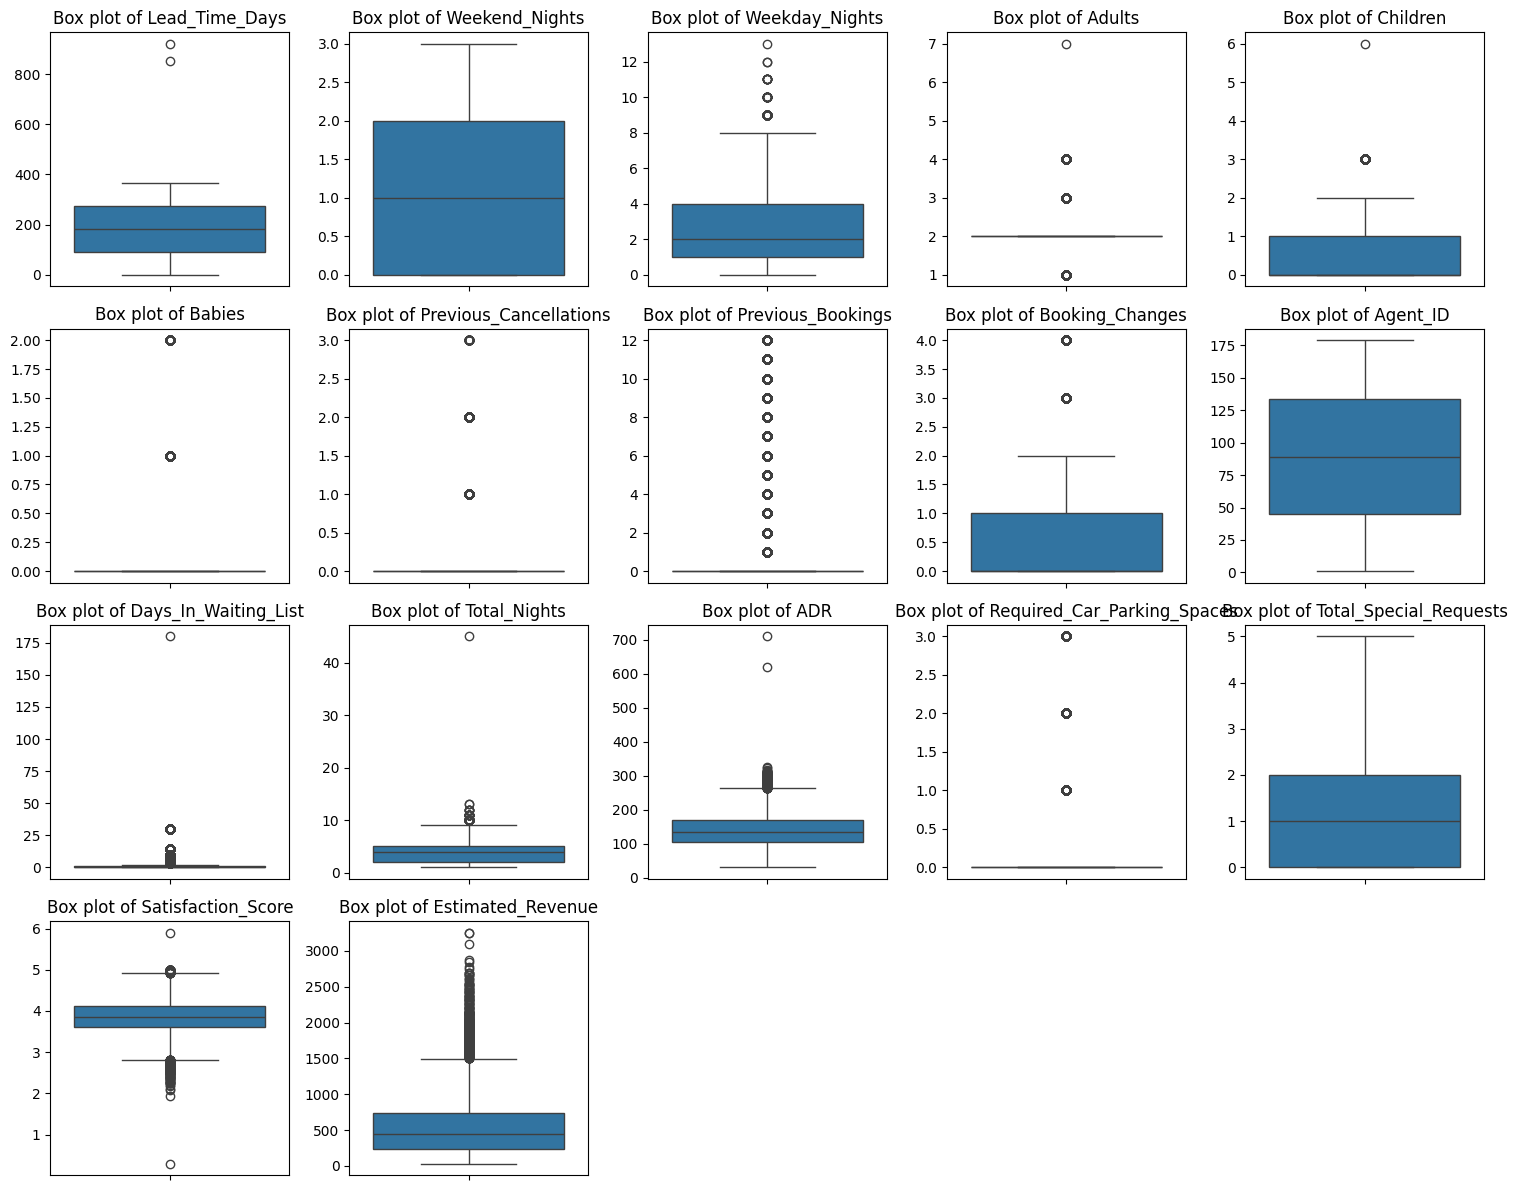


Outliers detected in 'Lead_Time_Days': 2 records (0.01% of total)

Outliers detected in 'Adults': 7529 records (30.12% of total)

Outliers detected in 'Children': 210 records (0.84% of total)

Outliers detected in 'Babies': 959 records (3.84% of total)

No significant outliers detected in 'Weekend_Nights'.

Outliers detected in 'Weekday_Nights': 143 records (0.57% of total)

Outliers detected in 'Total_Nights': 136 records (0.54% of total)

Outliers detected in 'ADR': 360 records (1.44% of total)

Outliers detected in 'Previous_Cancellations': 687 records (2.75% of total)

Outliers detected in 'Previous_Bookings': 4322 records (17.29% of total)

Outliers detected in 'Booking_Changes': 1279 records (5.12% of total)

Outliers detected in 'Days_In_Waiting_List': 4082 records (16.33% of total)

No significant outliers detected in 'Total_Special_Requests'.

Outliers detected in 'Satisfaction_Score': 282 records (1.13% of total)

Outliers detected in 'Estimated_Revenue': 652 records (2.61% 

In [24]:
# Re-executing cell for Outlier Detection and Handling after modification
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns to check for outliers:", numerical_cols)

# Exclude 'Is_Canceled' and 'Is_Repeated_Guest' and 'Is_Room_Type_Changed' as they are binary/categorical in nature
outlier_check_cols = [col for col in numerical_cols if col not in ['Is_Canceled', 'Is_Repeated_Guest', 'Is_Room_Type_Changed']]

# Calculate the number of rows and columns for the subplot grid
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

# Visualize outliers using box plots for key numerical features
plt.figure(figsize=(num_cols * 3, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# Identify outliers using IQR method for key numerical columns
# For this EDA, we will identify potential outliers but might not remove them directly, as they can represent valid data points.
# The decision to remove or transform outliers depends on the specific analysis goals.

for col in ['Lead_Time_Days', 'Adults', 'Children', 'Babies', 'Weekend_Nights', 'Weekday_Nights', 'Total_Nights', 'ADR', 'Previous_Cancellations', 'Previous_Bookings', 'Booking_Changes', 'Days_In_Waiting_List', 'Total_Special_Requests', 'Satisfaction_Score', 'Estimated_Revenue']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        if not outliers.empty:
            print(f"\nOutliers detected in '{col}': {len(outliers)} records ({len(outliers)/len(df)*100:.2f}% of total)")
            # Example of how to cap outliers (winsorization) - not applying directly, just for demonstration
            # df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
            # df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        else:
            print(f"\nNo significant outliers detected in '{col}'.")

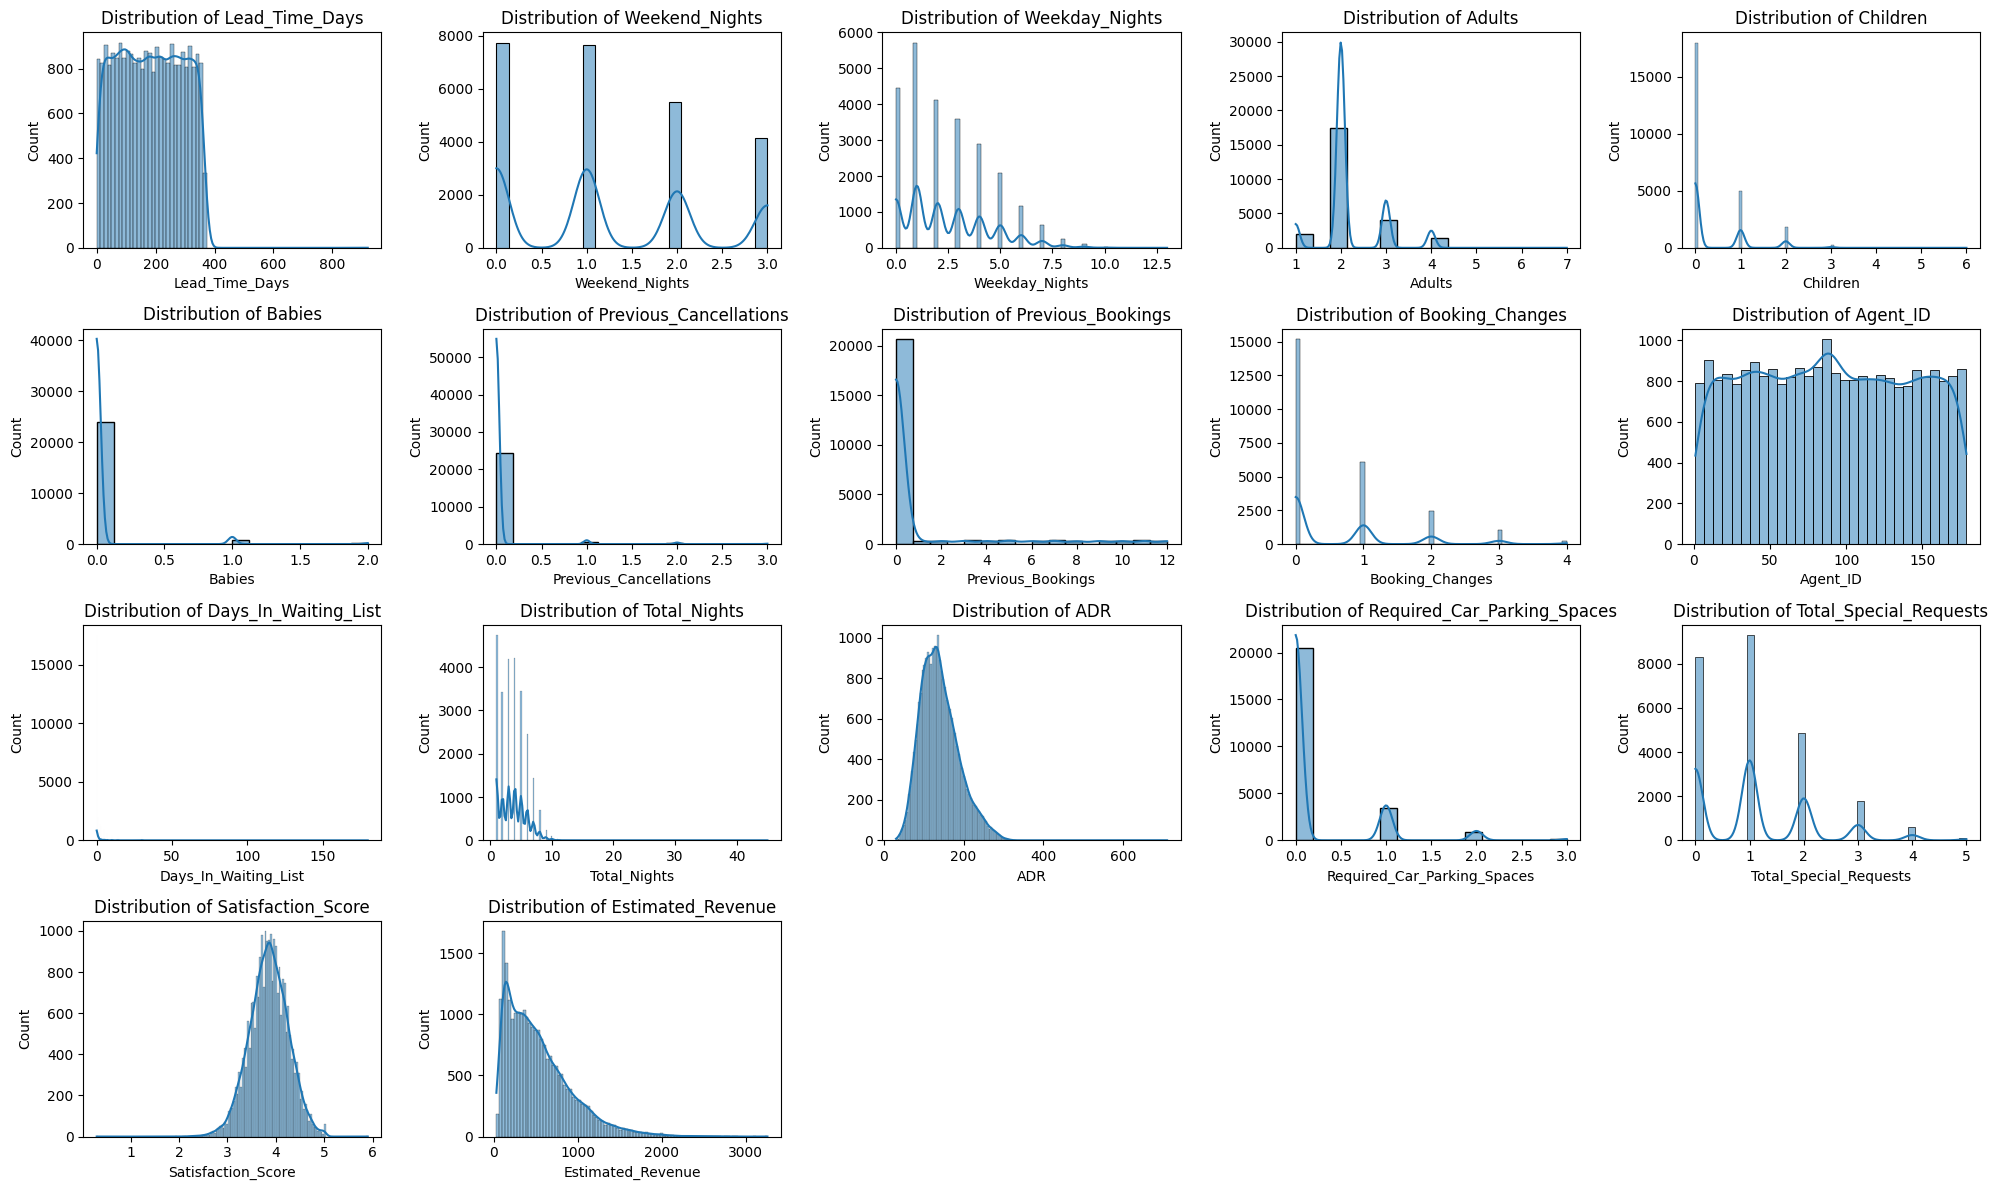

In [25]:
# Re-executing cell for Distribution of Numerical Features after modification
# Plot histograms for numerical features to visualize their distributions
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 4, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 1.4. Inconsistent Values (Categorical Data)

In [21]:
# Check unique values for categorical columns to identify inconsistencies

# Define categorical columns to check (excluding Booking_ID, dates, and numerical)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Unique values for categorical columns (top 10 if many):")
for col in categorical_cols:
    print(f"\nColumn '{col}':")
    unique_vals = df[col].unique()
    if len(unique_vals) > 10:
        print(unique_vals[:10], "... (truncated)")
    else:
        print(unique_vals)

# Specific checks for columns identified from initial df.describe(include='all') or df.info()
print("\nUnique values for 'Reservation_Status':", df['Reservation_Status'].unique())
print("Unique values for 'Hotel_Type':", df['Hotel_Type'].unique())
print("Unique values for 'Market_Segment':", df['Market_Segment'].unique())
print("Unique values for 'Distribution_Channel':", df['Distribution_Channel'].unique())
print("Unique values for 'Deposit_Type':", df['Deposit_Type'].unique())
print("Unique values for 'Customer_Type':", df['Customer_Type'].unique())
print("Unique values for 'Meal_Type':", df['Meal_Type'].unique())
print("Unique values for 'Room_Type_Reserved':", df['Room_Type_Reserved'].unique())
print("Unique values for 'Room_Type_Assigned':", df['Room_Type_Assigned'].unique())
print("Unique values for 'Country':", df['Country'].unique())
print("Unique values for 'Hotel_Location':", df['Hotel_Location'].unique())

# Standardize inconsistent categorical values
# Convert to lowercase and strip whitespace for consistency
df['Hotel_Type'] = df['Hotel_Type'].str.lower().str.strip().replace({'city hotel': 'City Hotel', 'resort hotel': 'Resort Hotel'})
df['Market_Segment'] = df['Market_Segment'].str.lower().str.strip().replace({'online ta': 'Online TA', 'online ta ': 'Online TA', 'ONLINE TA': 'Online TA'})
df['Meal_Type'] = df['Meal_Type'].str.lower().str.strip().replace({'bb': 'BB', 'b&b': 'BB', 'undefined': 'Undefined', 'sc': 'SC', 'fb': 'FB', 'hb': 'HB', 'unknown': 'Unknown'})
df['Hotel_Location'] = df['Hotel_Location'].str.strip()

print("\nStandardized inconsistent categorical values in 'Hotel_Type', 'Market_Segment', 'Meal_Type', 'Hotel_Location'.")

# Re-check unique values after standardization (optional, for verification)
print("\nUnique values for 'Hotel_Type' after standardization:", df['Hotel_Type'].unique())
print("Unique values for 'Market_Segment' after standardization:", df['Market_Segment'].unique())
print("Unique values for 'Meal_Type' after standardization:", df['Meal_Type'].unique())

# Data Cleaning - Room Type Consistency check (Reserved vs. Assigned)
# Create a new feature to indicate if the assigned room type is different from the reserved one.
df['Is_Room_Type_Changed'] = (df['Room_Type_Reserved'] != df['Room_Type_Assigned']).astype(int)
print("\nAdded 'Is_Room_Type_Changed' column.")

Unique values for categorical columns (top 10 if many):

Column 'Booking_ID':
['HTL024548' 'HTL019878' 'HTL017377' 'HTL003352' 'HTL012521' 'HTL014174'
 'HTL005872' 'HTL015091' 'HTL009423' 'HTL001216'] ... (truncated)

Column 'Hotel_Type':
['City Hotel' 'Resort Hotel']

Column 'Hotel_Location':
['London' 'Lisbon' 'Dubai' 'Maldives' 'Amsterdam' 'Algarve' 'Barcelona'
 'Goa' 'Bali' 'Phuket'] ... (truncated)

Column 'Country':
['ARE' 'JPN' 'POL' 'CAN' 'PRT' 'DNK' 'BRA' 'AUS' 'GBR' 'ESP'] ... (truncated)

Column 'Market_Segment':
['direct' 'groups' 'Online TA' 'offline ta/to' 'corporate']

Column 'Distribution_Channel':
['Direct' 'TA/TO' 'Corporate']

Column 'Room_Type_Reserved':
['H' 'D' 'C' 'G' 'A' 'E' 'B' 'F']

Column 'Room_Type_Assigned':
['H' 'D' 'C' 'E' 'G' 'B' 'A' 'F']

Column 'Deposit_Type':
['Non Refund' 'No Deposit' 'Refundable']

Column 'Customer_Type':
['Contract' 'Transient' 'Group' 'Transient-Party']

Column 'Meal_Type':
['HB' 'Undefined' 'FB' 'SC' 'BB' 'Unknown']

Column 'Rese

In [27]:
# Re-executing cell to handle inconsistent values after modification
# Define categorical columns to check (excluding Booking_ID, dates, and numerical)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Unique values for categorical columns (top 10 if many):")
for col in categorical_cols:
    print(f"\nColumn '{col}':")
    unique_vals = df[col].unique()
    if len(unique_vals) > 10:
        print(unique_vals[:10], "... (truncated)")
    else:
        print(unique_vals)

# Specific checks for columns identified from initial df.describe(include='all') or df.info()
print("\nUnique values for 'Reservation_Status':", df['Reservation_Status'].unique())
print("Unique values for 'Hotel_Type':", df['Hotel_Type'].unique())
print("Unique values for 'Market_Segment':", df['Market_Segment'].unique())
print("Unique values for 'Distribution_Channel':", df['Distribution_Channel'].unique())
print("Unique values for 'Deposit_Type':", df['Deposit_Type'].unique())
print("Unique values for 'Customer_Type':", df['Customer_Type'].unique())
print("Unique values for 'Meal_Type':", df['Meal_Type'].unique())
print("Unique values for 'Room_Type_Reserved':", df['Room_Type_Reserved'].unique())
print("Unique values for 'Room_Type_Assigned':", df['Room_Type_Assigned'].unique())
print("Unique values for 'Country':", df['Country'].unique())
print("Unique values for 'Hotel_Location':", df['Hotel_Location'].unique())

# Standardize inconsistent categorical values
# Convert to lowercase and strip whitespace for consistency
df['Hotel_Type'] = df['Hotel_Type'].str.lower().str.strip().replace({'city hotel': 'City Hotel', 'resort hotel': 'Resort Hotel'})
df['Market_Segment'] = df['Market_Segment'].str.lower().str.strip().replace({'online ta': 'Online TA', 'online ta ': 'Online TA', 'ONLINE TA': 'Online TA'})
df['Meal_Type'] = df['Meal_Type'].str.lower().str.strip().replace({'bb': 'BB', 'b&b': 'BB', 'undefined': 'Undefined', 'sc': 'SC', 'fb': 'FB', 'hb': 'HB', 'unknown': 'Unknown'})
df['Hotel_Location'] = df['Hotel_Location'].str.strip()

print("\nStandardized inconsistent categorical values in 'Hotel_Type', 'Market_Segment', 'Meal_Type', 'Hotel_Location'.")

# Re-check unique values after standardization (optional, for verification)
print("\nUnique values for 'Hotel_Type' after standardization:", df['Hotel_Type'].unique())
print("Unique values for 'Market_Segment' after standardization:", df['Market_Segment'].unique())
print("Unique values for 'Meal_Type' after standardization:", df['Meal_Type'].unique())

# Data Cleaning - Room Type Consistency check (Reserved vs. Assigned)
# Create a new feature to indicate if the assigned room type is different from the reserved one.
df['Is_Room_Type_Changed'] = (df['Room_Type_Reserved'] != df['Room_Type_Assigned']).astype(int)
print("\nAdded 'Is_Room_Type_Changed' column.")

Unique values for categorical columns (top 10 if many):

Column 'Booking_ID':
['HTL024548' 'HTL019878' 'HTL017377' 'HTL003352' 'HTL012521' 'HTL014174'
 'HTL005872' 'HTL015091' 'HTL009423' 'HTL001216'] ... (truncated)

Column 'Hotel_Type':
['City Hotel' 'Resort Hotel']

Column 'Hotel_Location':
['London' 'Lisbon' 'Dubai' 'Maldives' 'Amsterdam' 'Algarve' 'Barcelona'
 'Goa' 'Bali' 'Phuket'] ... (truncated)

Column 'Country':
['ARE' 'JPN' 'POL' 'CAN' 'PRT' 'DNK' 'BRA' 'AUS' 'GBR' 'ESP'] ... (truncated)

Column 'Market_Segment':
['direct' 'groups' 'Online TA' 'offline ta/to' 'corporate']

Column 'Distribution_Channel':
['Direct' 'TA/TO' 'Corporate']

Column 'Room_Type_Reserved':
['H' 'D' 'C' 'G' 'A' 'E' 'B' 'F']

Column 'Room_Type_Assigned':
['H' 'D' 'C' 'E' 'G' 'B' 'A' 'F']

Column 'Deposit_Type':
['Non Refund' 'No Deposit' 'Refundable']

Column 'Customer_Type':
['Contract' 'Transient' 'Group' 'Transient-Party']

Column 'Meal_Type':
['HB' 'Undefined' 'FB' 'SC' 'BB' 'Unknown']

Column 'Rese

### 1.5. Outlier Detection and Handling

Numerical columns to check for outliers: ['Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights', 'Adults', 'Children', 'Babies', 'Is_Repeated_Guest', 'Previous_Cancellations', 'Previous_Bookings', 'Booking_Changes', 'Agent_ID', 'Days_In_Waiting_List', 'Total_Nights', 'ADR', 'Required_Car_Parking_Spaces', 'Total_Special_Requests', 'Satisfaction_Score', 'Is_Canceled', 'Estimated_Revenue', 'Is_Room_Type_Changed']


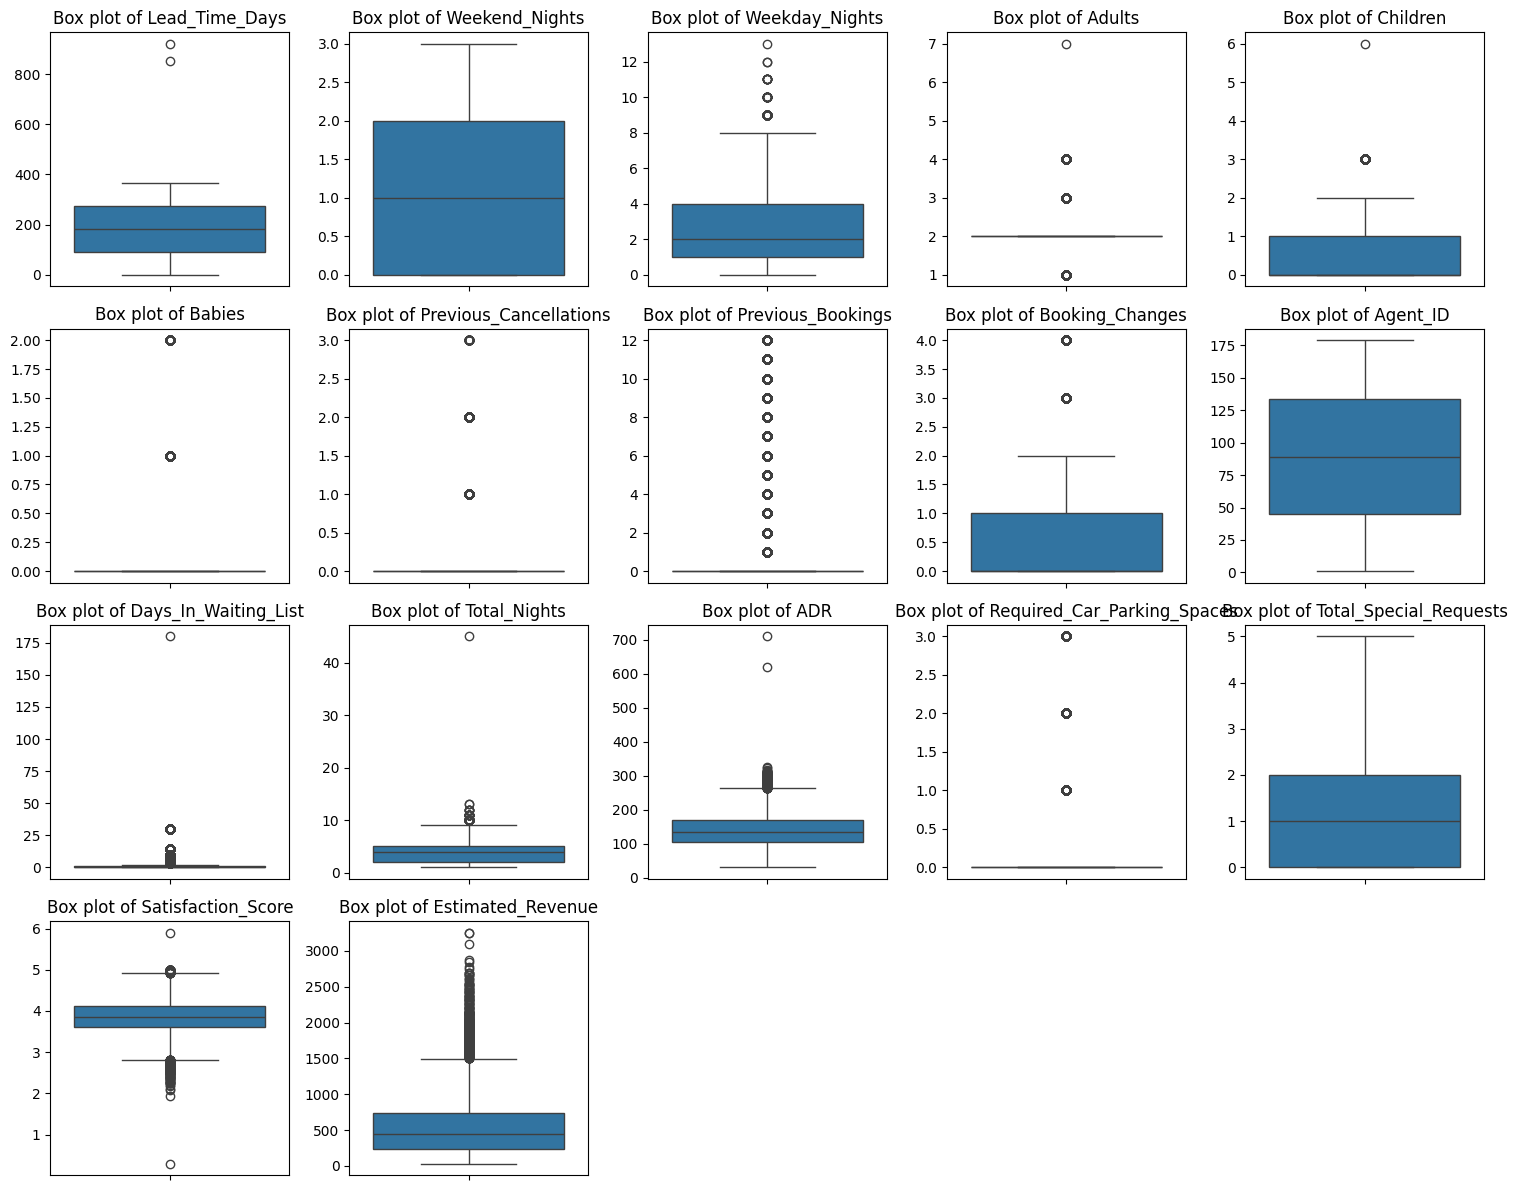


Outliers detected in 'Lead_Time_Days': 2 records (0.01% of total)

Outliers detected in 'Adults': 7529 records (30.12% of total)

Outliers detected in 'Children': 210 records (0.84% of total)

Outliers detected in 'Babies': 959 records (3.84% of total)

No significant outliers detected in 'Weekend_Nights'.

Outliers detected in 'Weekday_Nights': 143 records (0.57% of total)

Outliers detected in 'Total_Nights': 136 records (0.54% of total)

Outliers detected in 'ADR': 360 records (1.44% of total)

Outliers detected in 'Previous_Cancellations': 687 records (2.75% of total)

Outliers detected in 'Previous_Bookings': 4322 records (17.29% of total)

Outliers detected in 'Booking_Changes': 1279 records (5.12% of total)

Outliers detected in 'Days_In_Waiting_List': 4082 records (16.33% of total)

No significant outliers detected in 'Total_Special_Requests'.

Outliers detected in 'Satisfaction_Score': 282 records (1.13% of total)

Outliers detected in 'Estimated_Revenue': 652 records (2.61% 

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns to check for outliers:", numerical_cols)

# Exclude 'Is_Canceled' and 'Is_Repeated_Guest' and 'Is_Room_Type_Changed' as they are binary/categorical in nature
outlier_check_cols = [col for col in numerical_cols if col not in ['Is_Canceled', 'Is_Repeated_Guest', 'Is_Room_Type_Changed']]

# Calculate the number of rows and columns for the subplot grid
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed using ceiling division

# Visualize outliers using box plots for key numerical features
plt.figure(figsize=(num_cols * 3, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1) # Use calculated num_rows and num_cols
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# Identify outliers using IQR method for key numerical columns
# For this EDA, we will identify potential outliers but might not remove them directly, as they can represent valid data points.
# The decision to remove or transform outliers depends on the specific analysis goals.

for col in ['Lead_Time_Days', 'Adults', 'Children', 'Babies', 'Weekend_Nights', 'Weekday_Nights', 'Total_Nights', 'ADR', 'Previous_Cancellations', 'Previous_Bookings', 'Booking_Changes', 'Days_In_Waiting_List', 'Total_Special_Requests', 'Satisfaction_Score', 'Estimated_Revenue']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        if not outliers.empty:
            print(f"\nOutliers detected in '{col}': {len(outliers)} records ({len(outliers)/len(df)*100:.2f}% of total)")
            # Example of how to cap outliers (winsorization) - not applying directly, just for demonstration
            # df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
            # df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        else:
            print(f"\nNo significant outliers detected in '{col}'.")

Numerical columns to check for outliers: ['Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights', 'Adults', 'Children', 'Babies', 'Is_Repeated_Guest', 'Previous_Cancellations', 'Previous_Bookings', 'Booking_Changes', 'Agent_ID', 'Days_In_Waiting_List', 'Total_Nights', 'ADR', 'Required_Car_Parking_Spaces', 'Total_Special_Requests', 'Satisfaction_Score', 'Is_Canceled', 'Estimated_Revenue', 'Is_Room_Type_Changed']


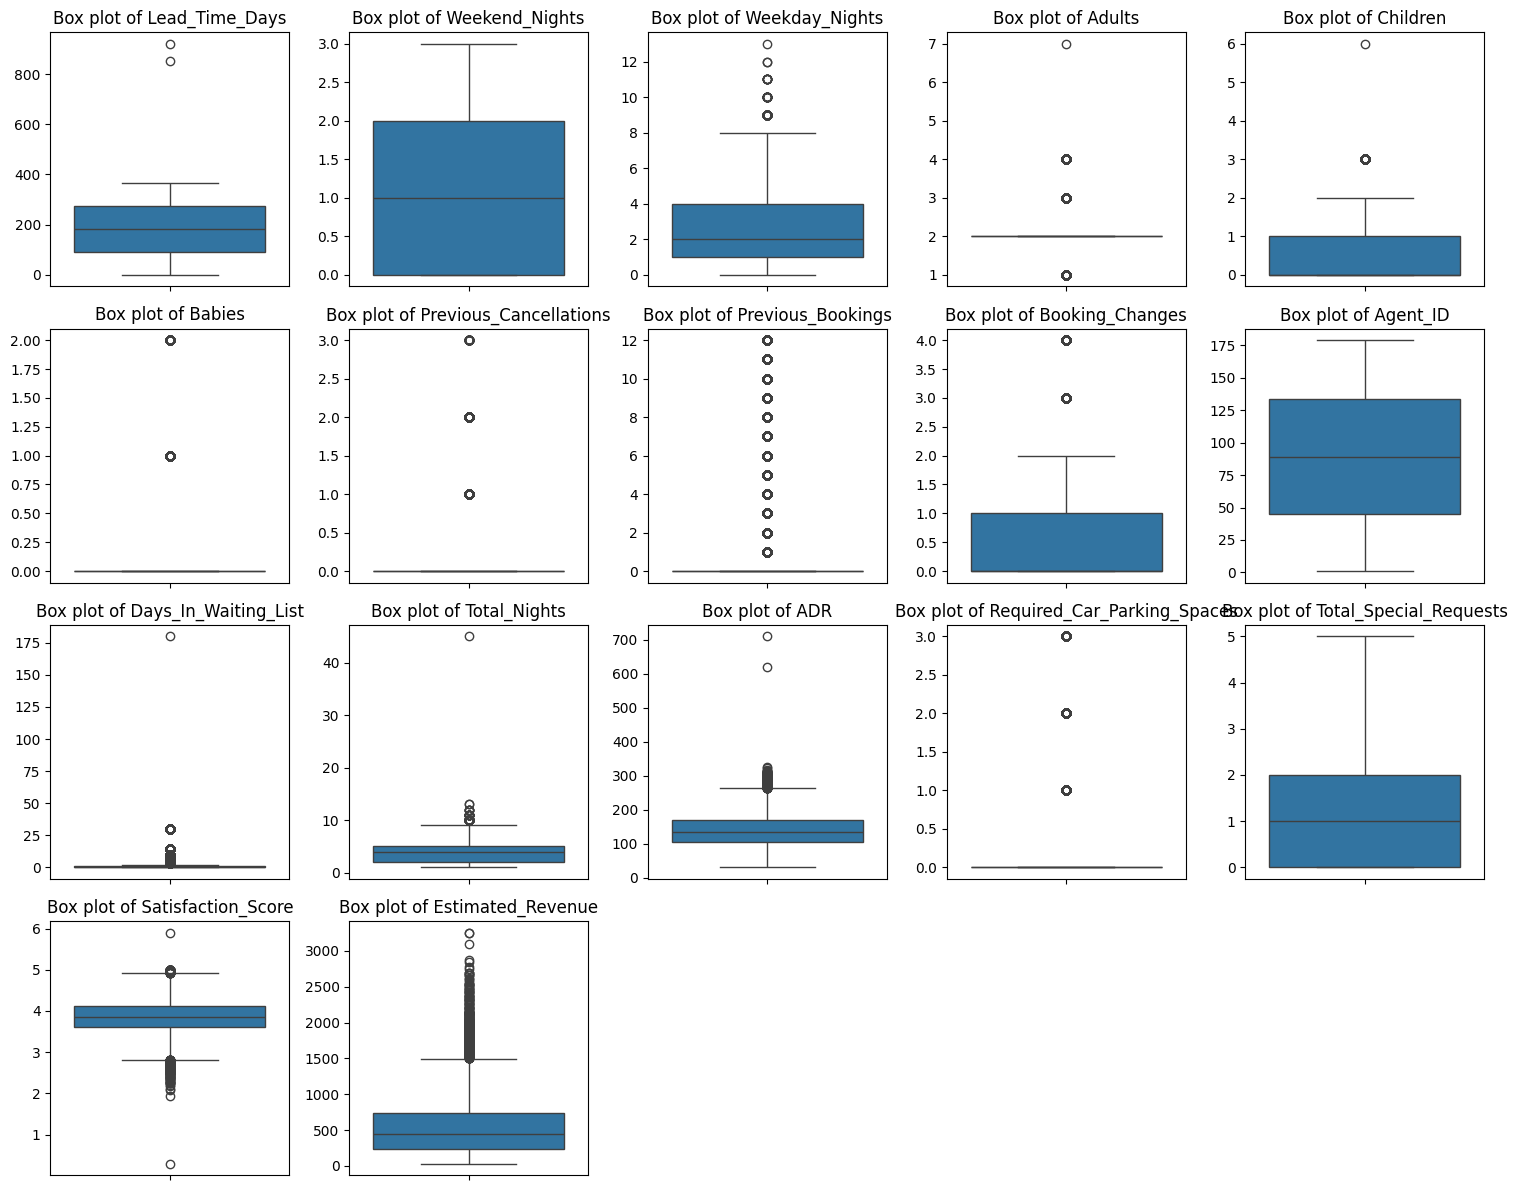


Outliers detected in 'Lead_Time_Days': 2 records (0.01% of total)

Outliers detected in 'Adults': 7529 records (30.12% of total)

Outliers detected in 'Children': 210 records (0.84% of total)

Outliers detected in 'Babies': 959 records (3.84% of total)

No significant outliers detected in 'Weekend_Nights'.

Outliers detected in 'Weekday_Nights': 143 records (0.57% of total)

Outliers detected in 'Total_Nights': 136 records (0.54% of total)

Outliers detected in 'ADR': 360 records (1.44% of total)

Outliers detected in 'Previous_Cancellations': 687 records (2.75% of total)

Outliers detected in 'Previous_Bookings': 4322 records (17.29% of total)

Outliers detected in 'Booking_Changes': 1279 records (5.12% of total)

Outliers detected in 'Days_In_Waiting_List': 4082 records (16.33% of total)

No significant outliers detected in 'Total_Special_Requests'.

Outliers detected in 'Satisfaction_Score': 282 records (1.13% of total)

Outliers detected in 'Estimated_Revenue': 652 records (2.61% 

In [30]:
# Re-executing cell for Outlier Detection and Handling after modification
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns to check for outliers:", numerical_cols)

# Exclude 'Is_Canceled' and 'Is_Repeated_Guest' and 'Is_Room_Type_Changed' as they are binary/categorical in nature
outlier_check_cols = [col for col in numerical_cols if col not in ['Is_Canceled', 'Is_Repeated_Guest', 'Is_Room_Type_Changed']]

# Calculate the number of rows and columns for the subplot grid
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed using ceiling division

# Visualize outliers using box plots for key numerical features
plt.figure(figsize=(num_cols * 3, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1) # Use calculated num_rows and num_cols
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# Identify outliers using IQR method for key numerical columns
# For this EDA, we will identify potential outliers but might not remove them directly, as they can represent valid data points.
# The decision to remove or transform outliers depends on the specific analysis goals.

for col in ['Lead_Time_Days', 'Adults', 'Children', 'Babies', 'Weekend_Nights', 'Weekday_Nights', 'Total_Nights', 'ADR', 'Previous_Cancellations', 'Previous_Bookings', 'Booking_Changes', 'Days_In_Waiting_List', 'Total_Special_Requests', 'Satisfaction_Score', 'Estimated_Revenue']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        if not outliers.empty:
            print(f"\nOutliers detected in '{col}': {len(outliers)} records ({len(outliers)/len(df)*100:.2f}% of total)")
            # Example of how to cap outliers (winsorization) - not applying directly, just for demonstration
            # df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
            # df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        else:
            print(f"\nNo significant outliers detected in '{col}'.")

Numerical columns to check for outliers: ['Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights', 'Adults', 'Children', 'Babies', 'Is_Repeated_Guest', 'Previous_Cancellations', 'Previous_Bookings', 'Booking_Changes', 'Agent_ID', 'Days_In_Waiting_List', 'Total_Nights', 'ADR', 'Required_Car_Parking_Spaces', 'Total_Special_Requests', 'Satisfaction_Score', 'Is_Canceled', 'Estimated_Revenue', 'Is_Room_Type_Changed']


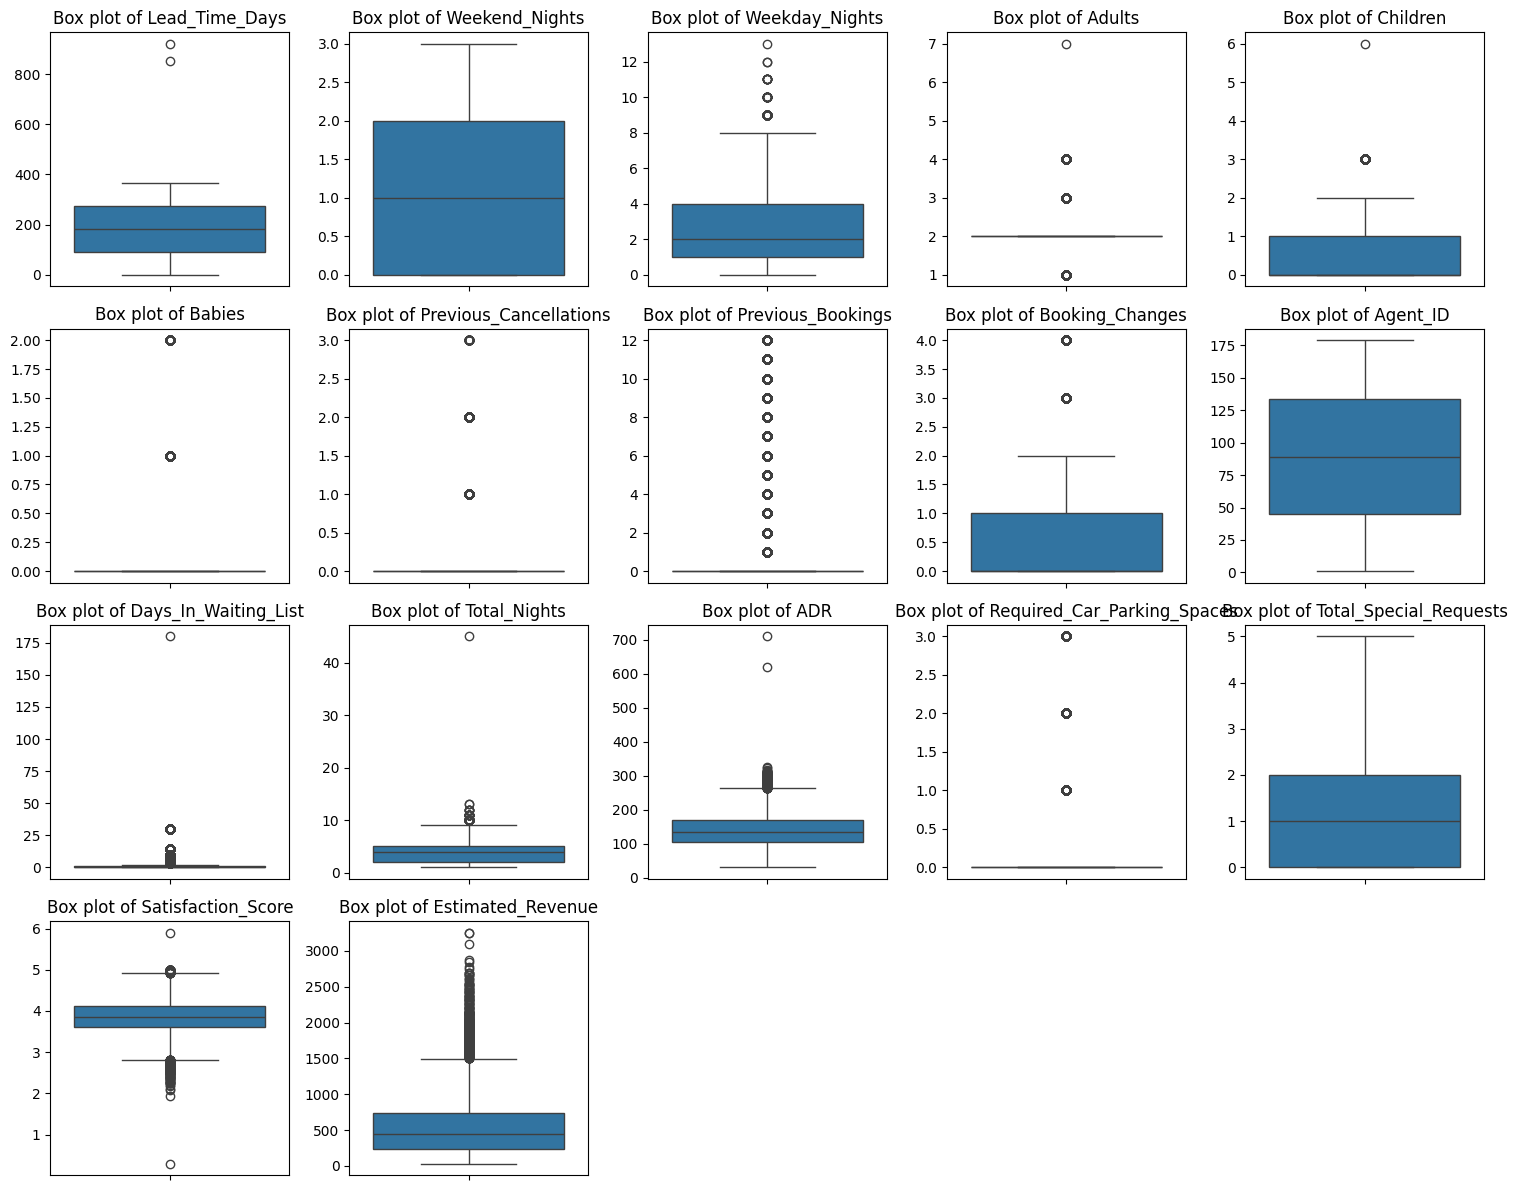


Outliers detected in 'Lead_Time_Days': 2 records (0.01% of total)

Outliers detected in 'Adults': 7529 records (30.12% of total)

Outliers detected in 'Children': 210 records (0.84% of total)

Outliers detected in 'Babies': 959 records (3.84% of total)

No significant outliers detected in 'Weekend_Nights'.

Outliers detected in 'Weekday_Nights': 143 records (0.57% of total)

Outliers detected in 'Total_Nights': 136 records (0.54% of total)

Outliers detected in 'ADR': 360 records (1.44% of total)

Outliers detected in 'Previous_Cancellations': 687 records (2.75% of total)

Outliers detected in 'Previous_Bookings': 4322 records (17.29% of total)

Outliers detected in 'Booking_Changes': 1279 records (5.12% of total)

Outliers detected in 'Days_In_Waiting_List': 4082 records (16.33% of total)

No significant outliers detected in 'Total_Special_Requests'.

Outliers detected in 'Satisfaction_Score': 282 records (1.13% of total)

Outliers detected in 'Estimated_Revenue': 652 records (2.61% 

In [28]:
# Re-executing cell for Outlier Detection and Handling after modification
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns to check for outliers:", numerical_cols)

# Exclude 'Is_Canceled' and 'Is_Repeated_Guest' and 'Is_Room_Type_Changed' as they are binary/categorical in nature
outlier_check_cols = [col for col in numerical_cols if col not in ['Is_Canceled', 'Is_Repeated_Guest', 'Is_Room_Type_Changed']]

# Calculate the number of rows and columns for the subplot grid
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed using ceiling division

# Visualize outliers using box plots for key numerical features
plt.figure(figsize=(num_cols * 3, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# Identify outliers using IQR method for key numerical columns
# For this EDA, we will identify potential outliers but might not remove them directly, as they can represent valid data points.
# The decision to remove or transform outliers depends on the specific analysis goals.

for col in ['Lead_Time_Days', 'Adults', 'Children', 'Babies', 'Weekend_Nights', 'Weekday_Nights', 'Total_Nights', 'ADR', 'Previous_Cancellations', 'Previous_Bookings', 'Booking_Changes', 'Days_In_Waiting_List', 'Total_Special_Requests', 'Satisfaction_Score', 'Estimated_Revenue']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        if not outliers.empty:
            print(f"\nOutliers detected in '{col}': {len(outliers)} records ({len(outliers)/len(df)*100:.2f}% of total)")
            # Example of how to cap outliers (winsorization) - not applying directly, just for demonstration
            # df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
            # df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        else:
            print(f"\nNo significant outliers detected in '{col}'.")

## 2. Univariate Analysis
### 2.1. Descriptive Statistics for Numerical Features

In [13]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Is_Room_Type_Changed
count,25000,25000,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,...,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,2025-07-04 02:15:31.967999744,535.367978,0.119480
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000,0.000000
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,2025-01-01 00:00:00,230.620000,0.000000
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000,0.000000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,...,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.570000,0.000000
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,...,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000,1.000000
std,NaN,NaN,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,...,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,NaN,389.640257,0.324359


In [46]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Is_Room_Type_Changed
count,25000,25000,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,...,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,2025-07-04 02:15:31.967999744,535.367978,0.119480
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000,0.000000
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,2025-01-01 00:00:00,230.620000,0.000000
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000,0.000000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,...,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.570000,0.000000
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,...,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000,1.000000
std,NaN,NaN,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,...,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,NaN,389.640257,0.324359


In [43]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Is_Room_Type_Changed
count,25000,25000,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,...,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,2025-07-04 02:15:31.967999744,535.367978,0.119480
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000,0.000000
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,2025-01-01 00:00:00,230.620000,0.000000
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000,0.000000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,...,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.570000,0.000000
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,...,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000,1.000000
std,NaN,NaN,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,...,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,NaN,389.640257,0.324359


In [40]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Is_Room_Type_Changed
count,25000,25000,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,...,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,2025-07-04 02:15:31.967999744,535.367978,0.119480
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000,0.000000
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,2025-01-01 00:00:00,230.620000,0.000000
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000,0.000000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,...,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.570000,0.000000
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,...,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000,1.000000
std,NaN,NaN,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,...,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,NaN,389.640257,0.324359


In [37]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Is_Room_Type_Changed
count,25000,25000,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,...,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,2025-07-04 02:15:31.967999744,535.367978,0.119480
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000,0.000000
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,2025-01-01 00:00:00,230.620000,0.000000
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000,0.000000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,...,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.570000,0.000000
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,...,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000,1.000000
std,NaN,NaN,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,...,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,NaN,389.640257,0.324359


In [34]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Is_Room_Type_Changed
count,25000,25000,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,...,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,2025-07-04 02:15:31.967999744,535.367978,0.119480
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000,0.000000
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,2025-01-01 00:00:00,230.620000,0.000000
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000,0.000000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,...,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.570000,0.000000
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,...,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000,1.000000
std,NaN,NaN,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,...,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,NaN,389.640257,0.324359


In [31]:
# Re-executing cell for Descriptive Statistics for Numerical Features
display(df.describe())

,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Is_Room_Type_Changed
count,25000,25000,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,...,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,2025-07-04 02:15:31.967999744,535.367978,0.119480
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000,0.000000
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,2025-01-01 00:00:00,230.620000,0.000000
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000,0.000000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,...,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.570000,0.000000
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,...,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000,1.000000
std,NaN,NaN,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,...,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,NaN,389.640257,0.324359


### 2.2. Distribution of Numerical Features

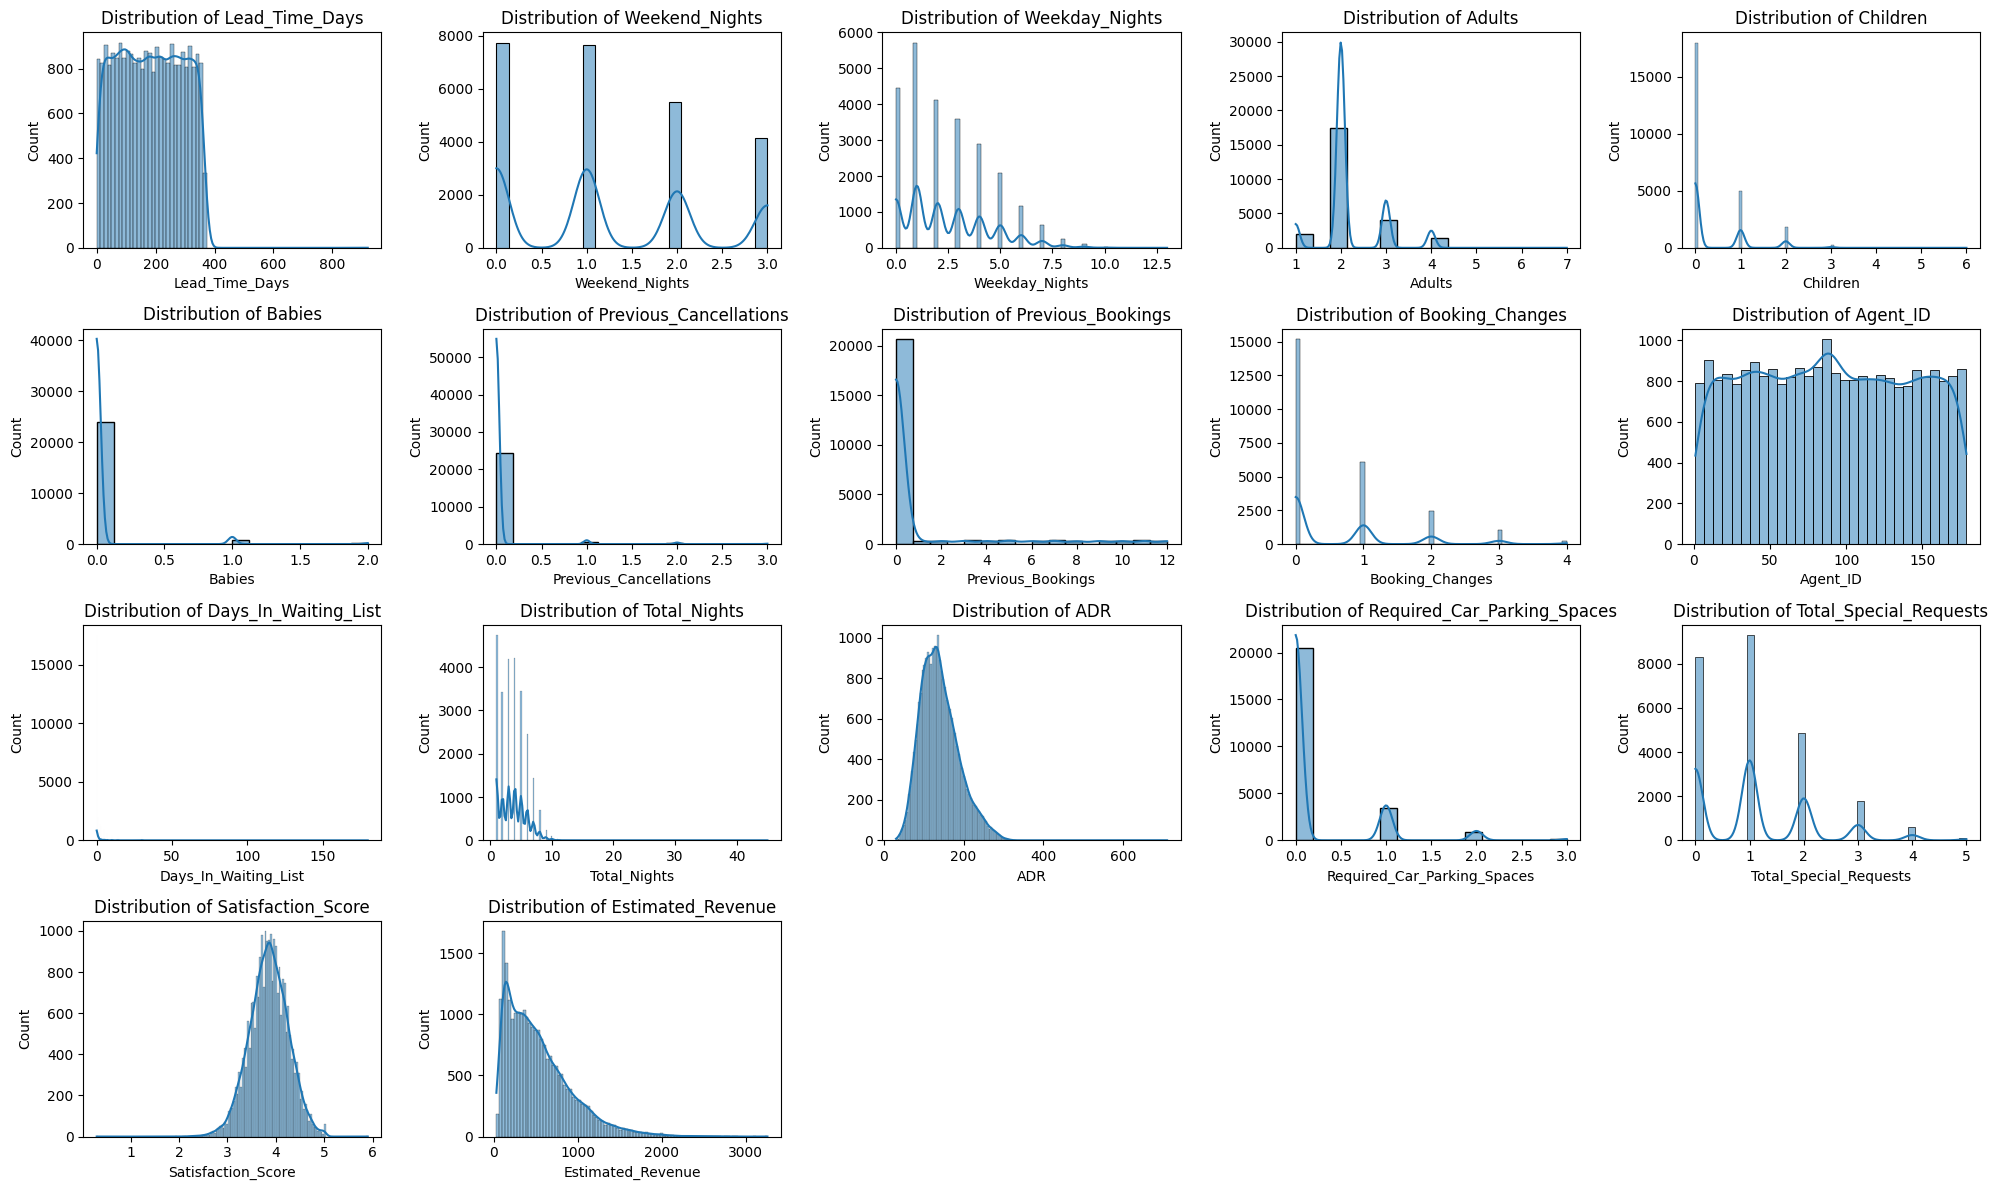

In [19]:
# Plot histograms for numerical features to visualize their distributions

# Re-calculate num_plots, num_cols, num_rows to ensure it matches the current state after potential column drops
# This assumes outlier_check_cols is correctly defined by a preceding cell execution.
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed using ceiling division

plt.figure(figsize=(num_cols * 4, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

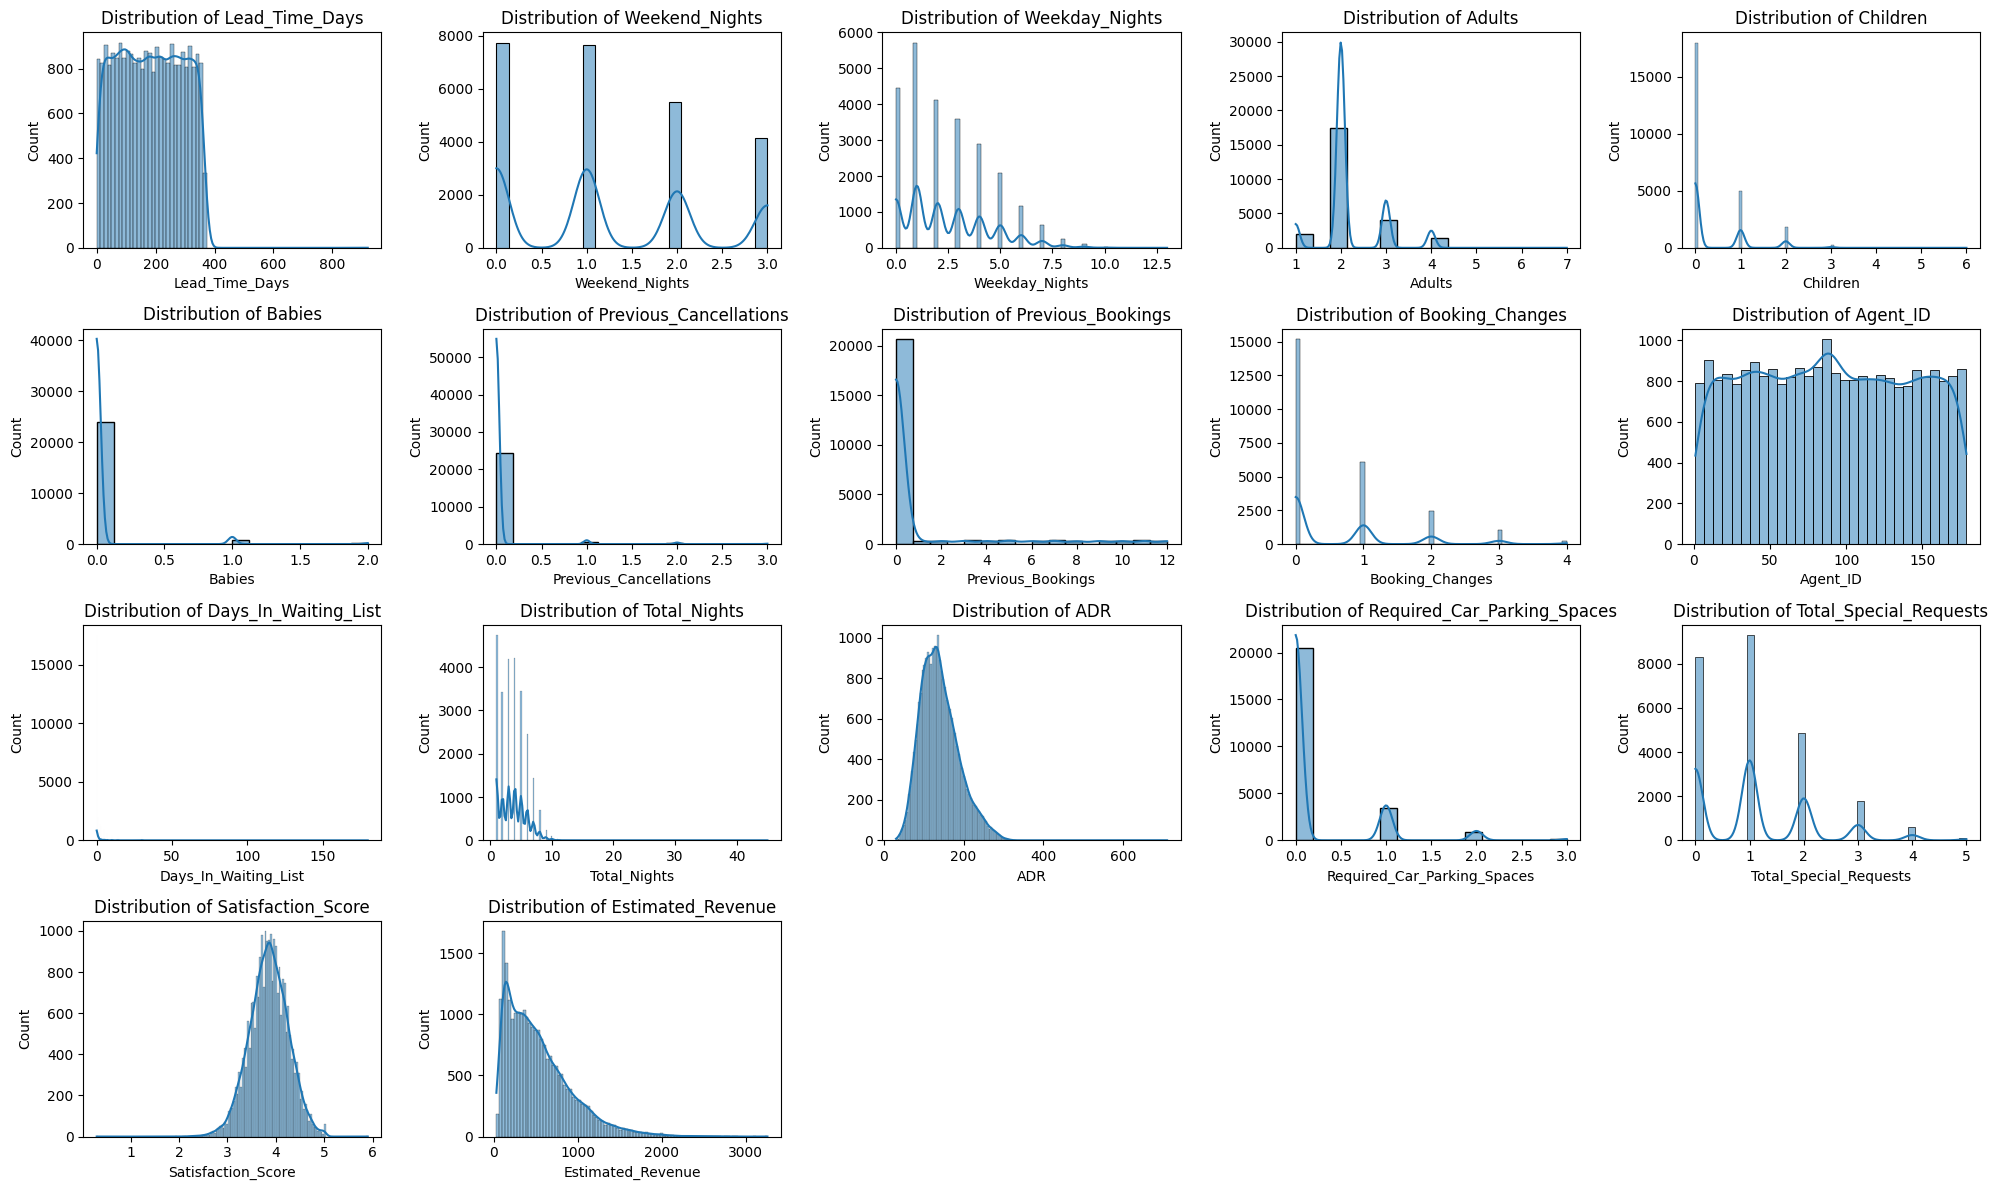

In [47]:
# Plot histograms for numerical features to visualize their distributions

# Re-calculate num_plots, num_cols, num_rows to ensure it matches the current state after potential column drops
# This assumes outlier_check_cols is correctly defined by a preceding cell execution.
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed using ceiling division

plt.figure(figsize=(num_cols * 4, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

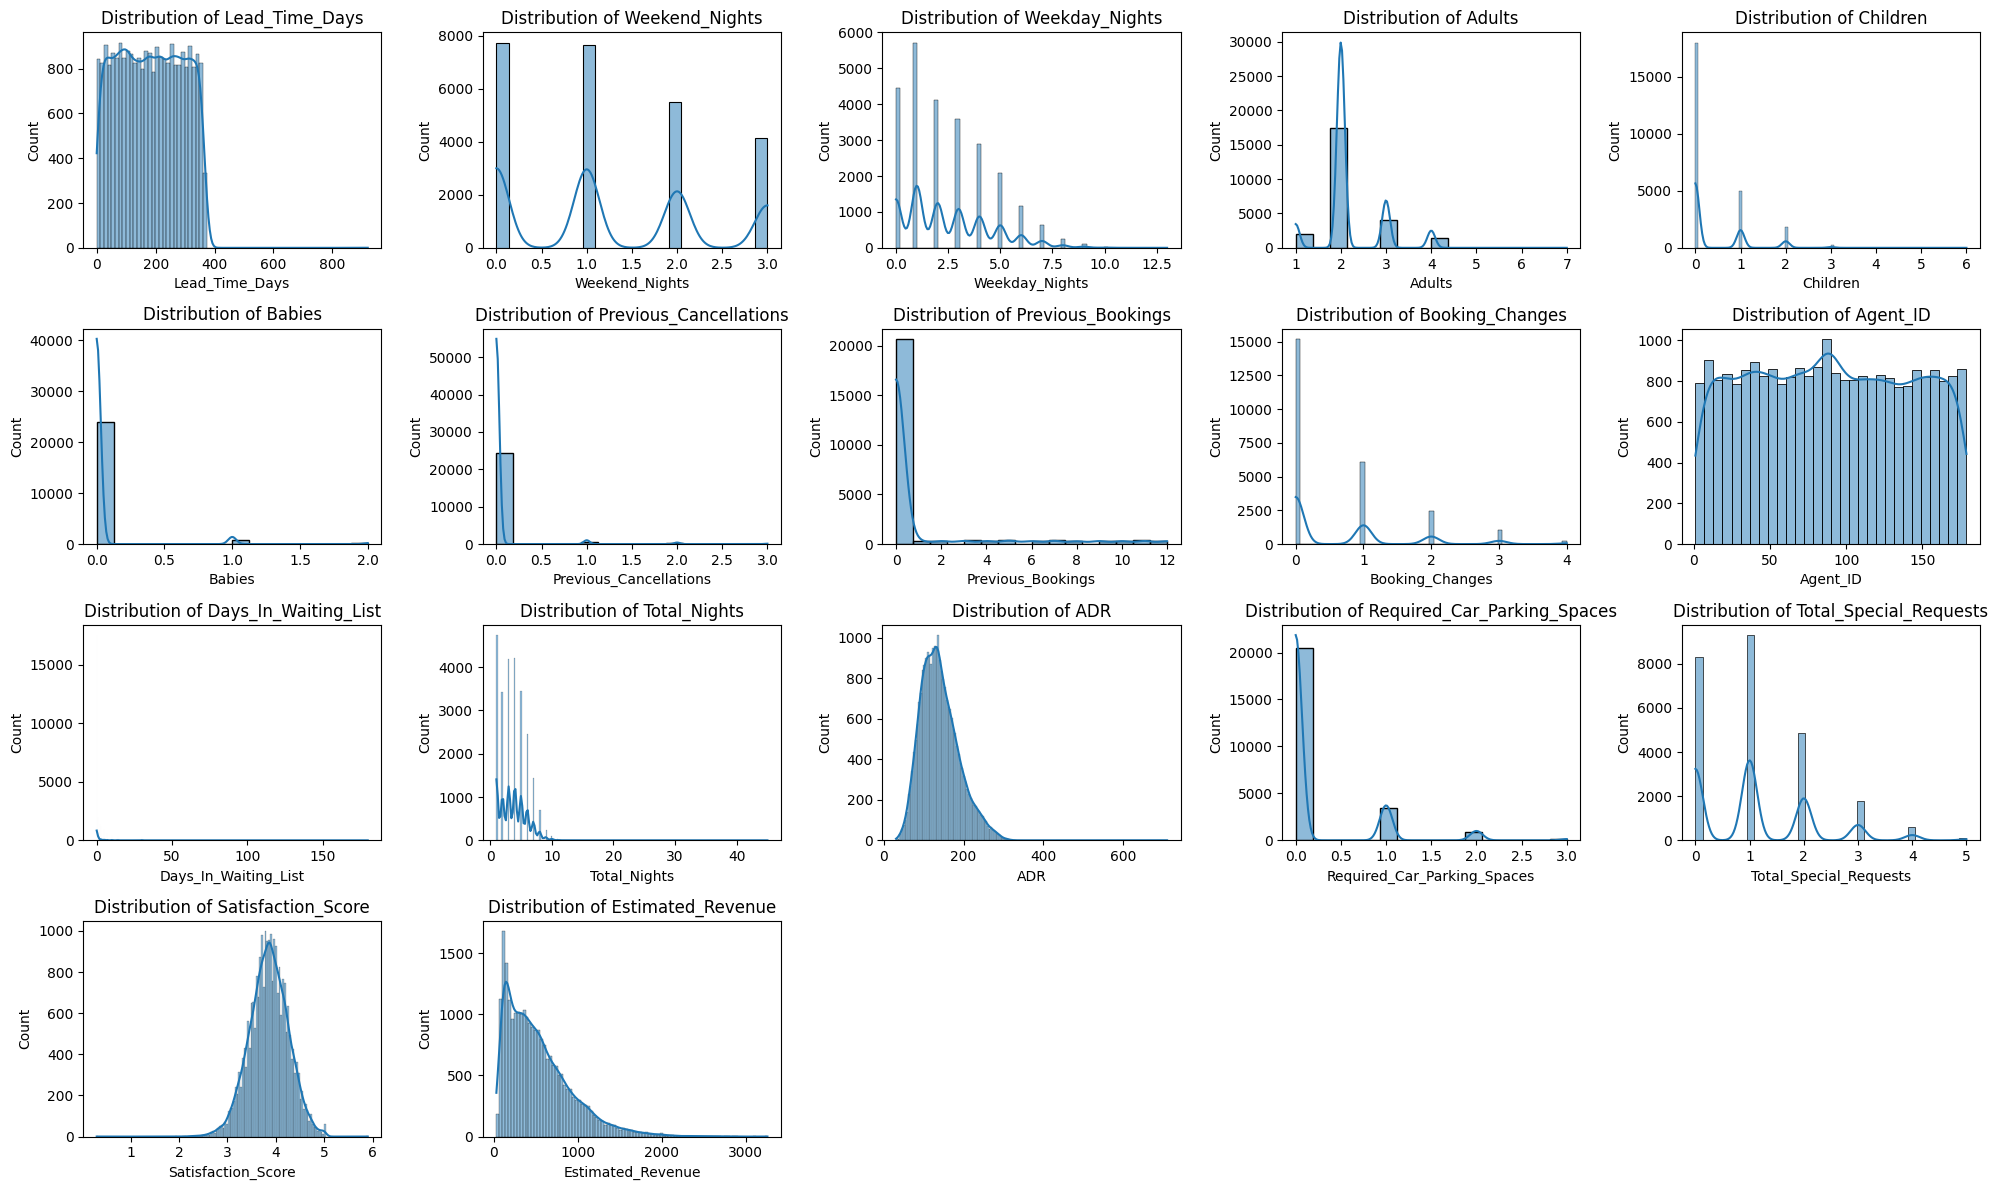

In [44]:
# Plot histograms for numerical features to visualize their distributions

# Re-calculate num_plots, num_cols, num_rows to ensure it matches the current state after potential column drops
# This assumes outlier_check_cols is correctly defined by a preceding cell execution.
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed using ceiling division

plt.figure(figsize=(num_cols * 4, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

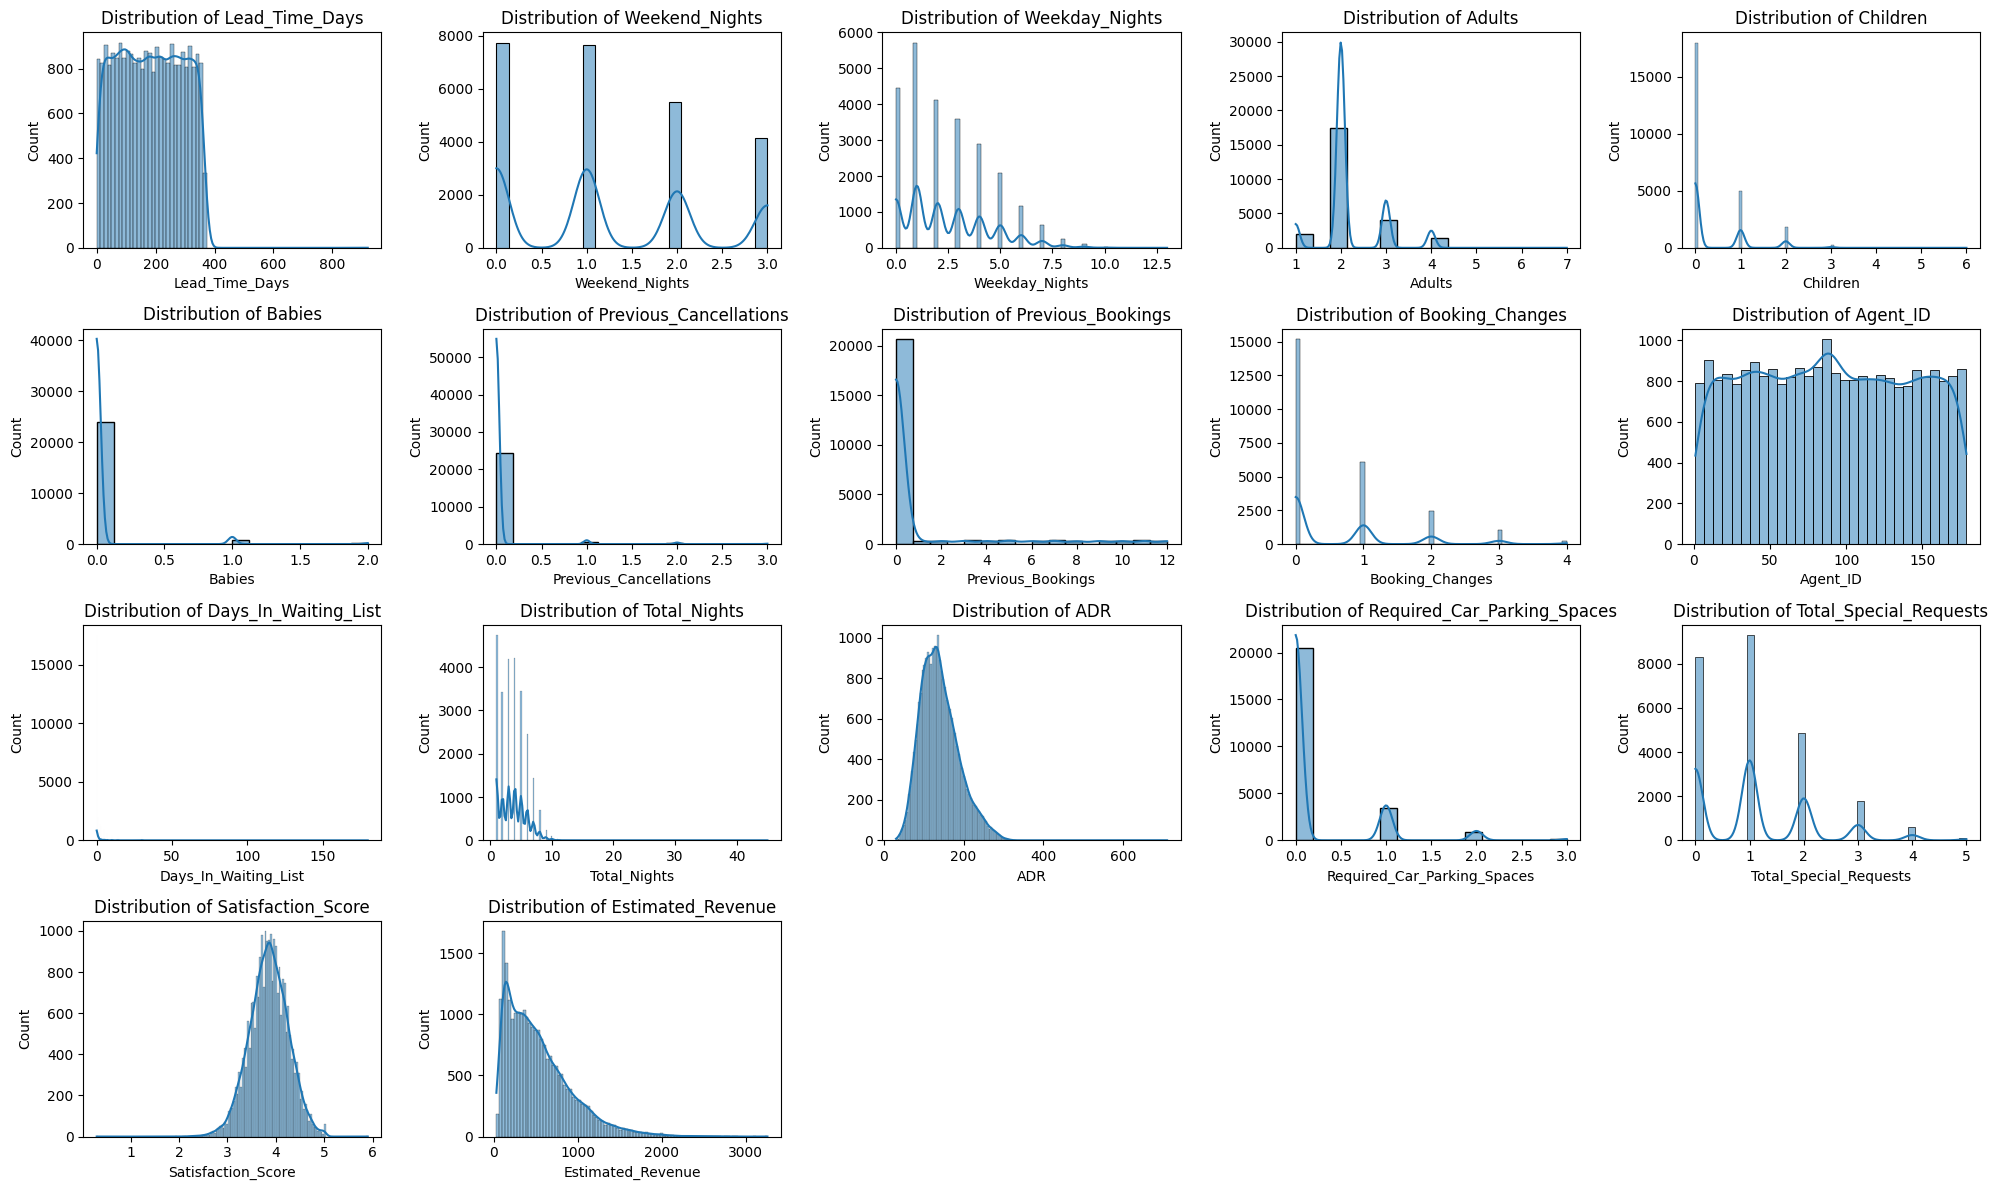

In [41]:
# Plot histograms for numerical features to visualize their distributions

# Re-calculate num_plots, num_cols, num_rows to ensure it matches the current state after potential column drops
# This assumes outlier_check_cols is correctly defined by a preceding cell execution.
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed using ceiling division

plt.figure(figsize=(num_cols * 4, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

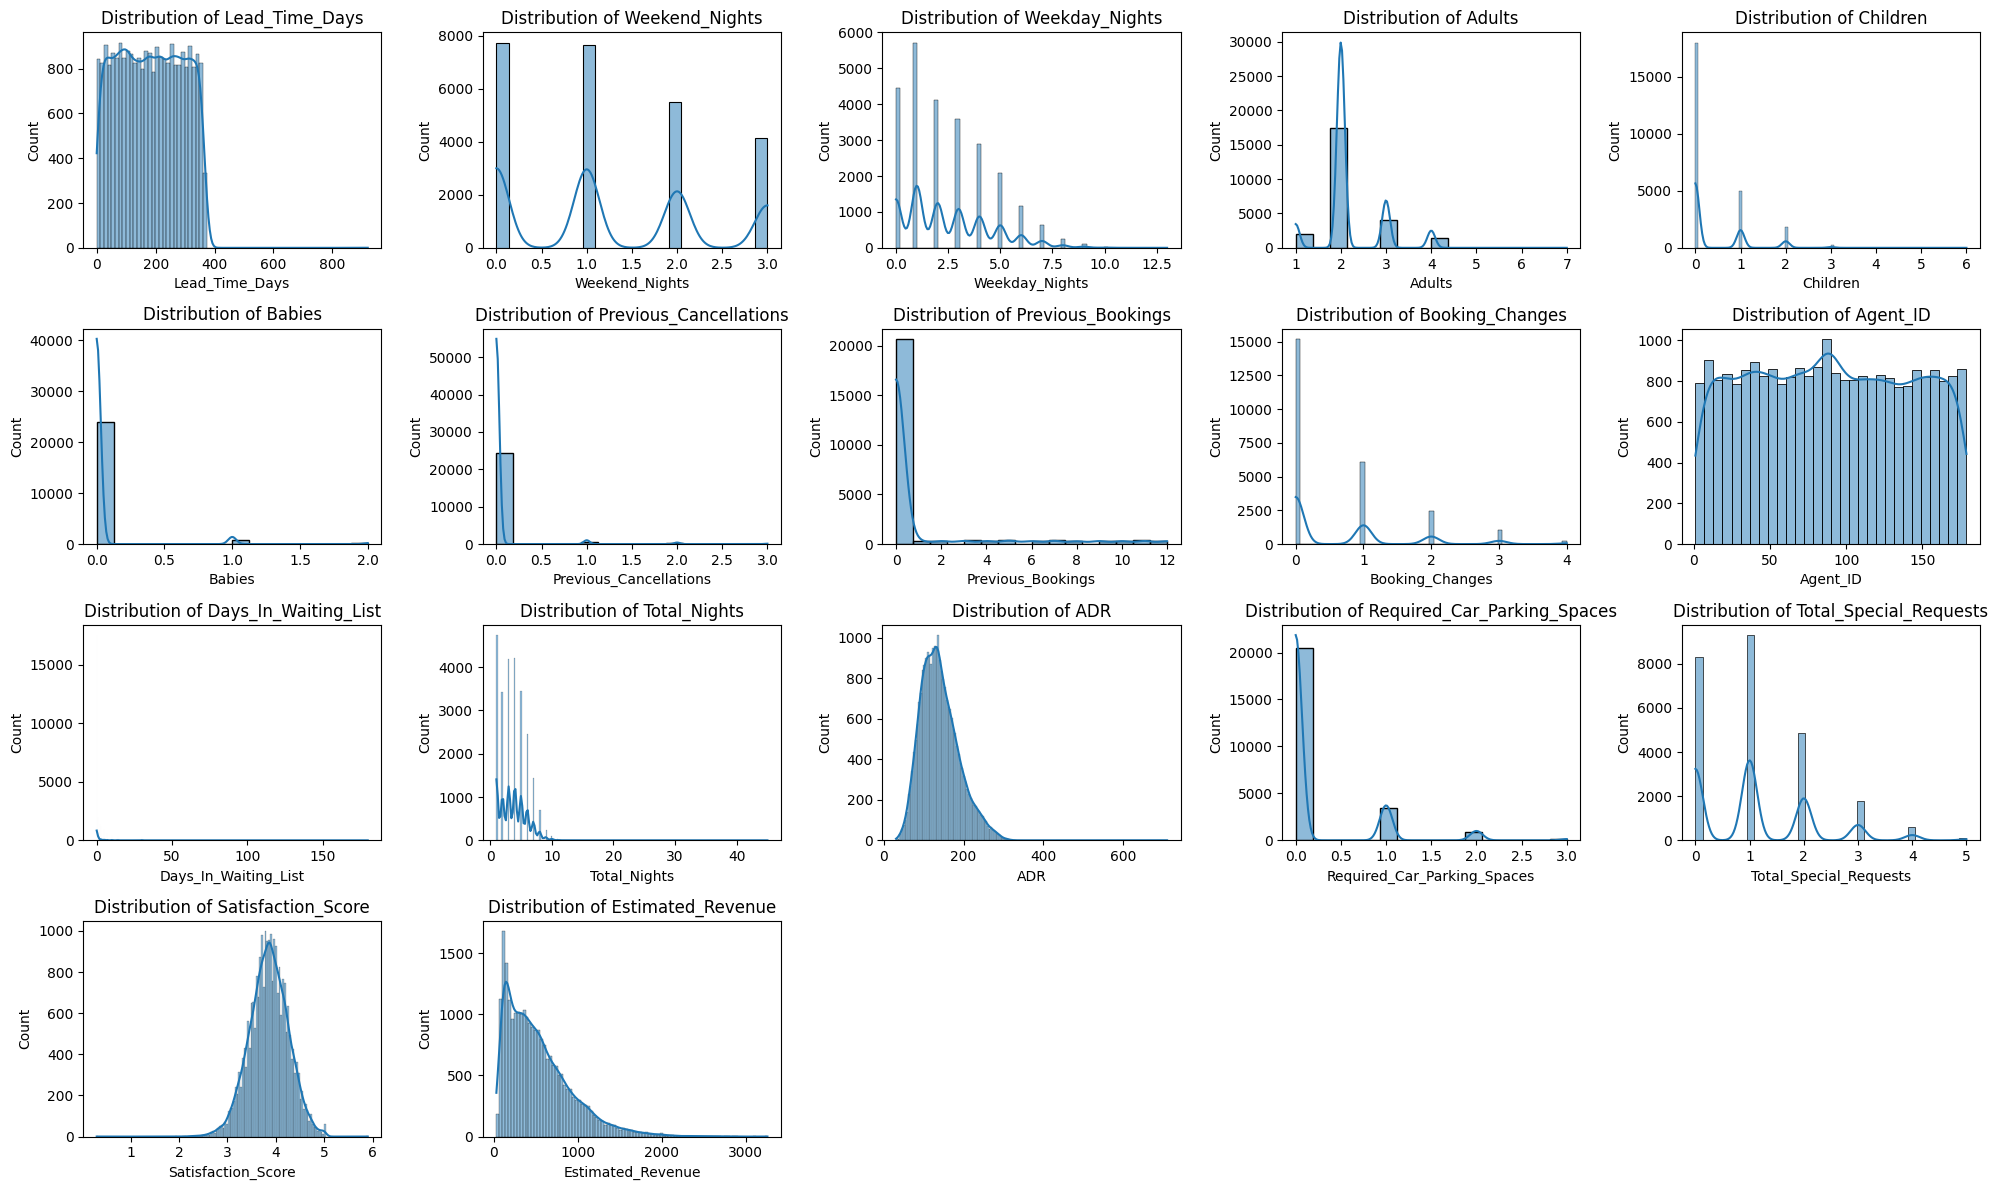

In [38]:
# Plot histograms for numerical features to visualize their distributions

# Re-calculate num_plots, num_cols, num_rows to ensure it matches the current state after potential column drops
# This assumes outlier_check_cols is correctly defined by a preceding cell execution.
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed using ceiling division

plt.figure(figsize=(num_cols * 4, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

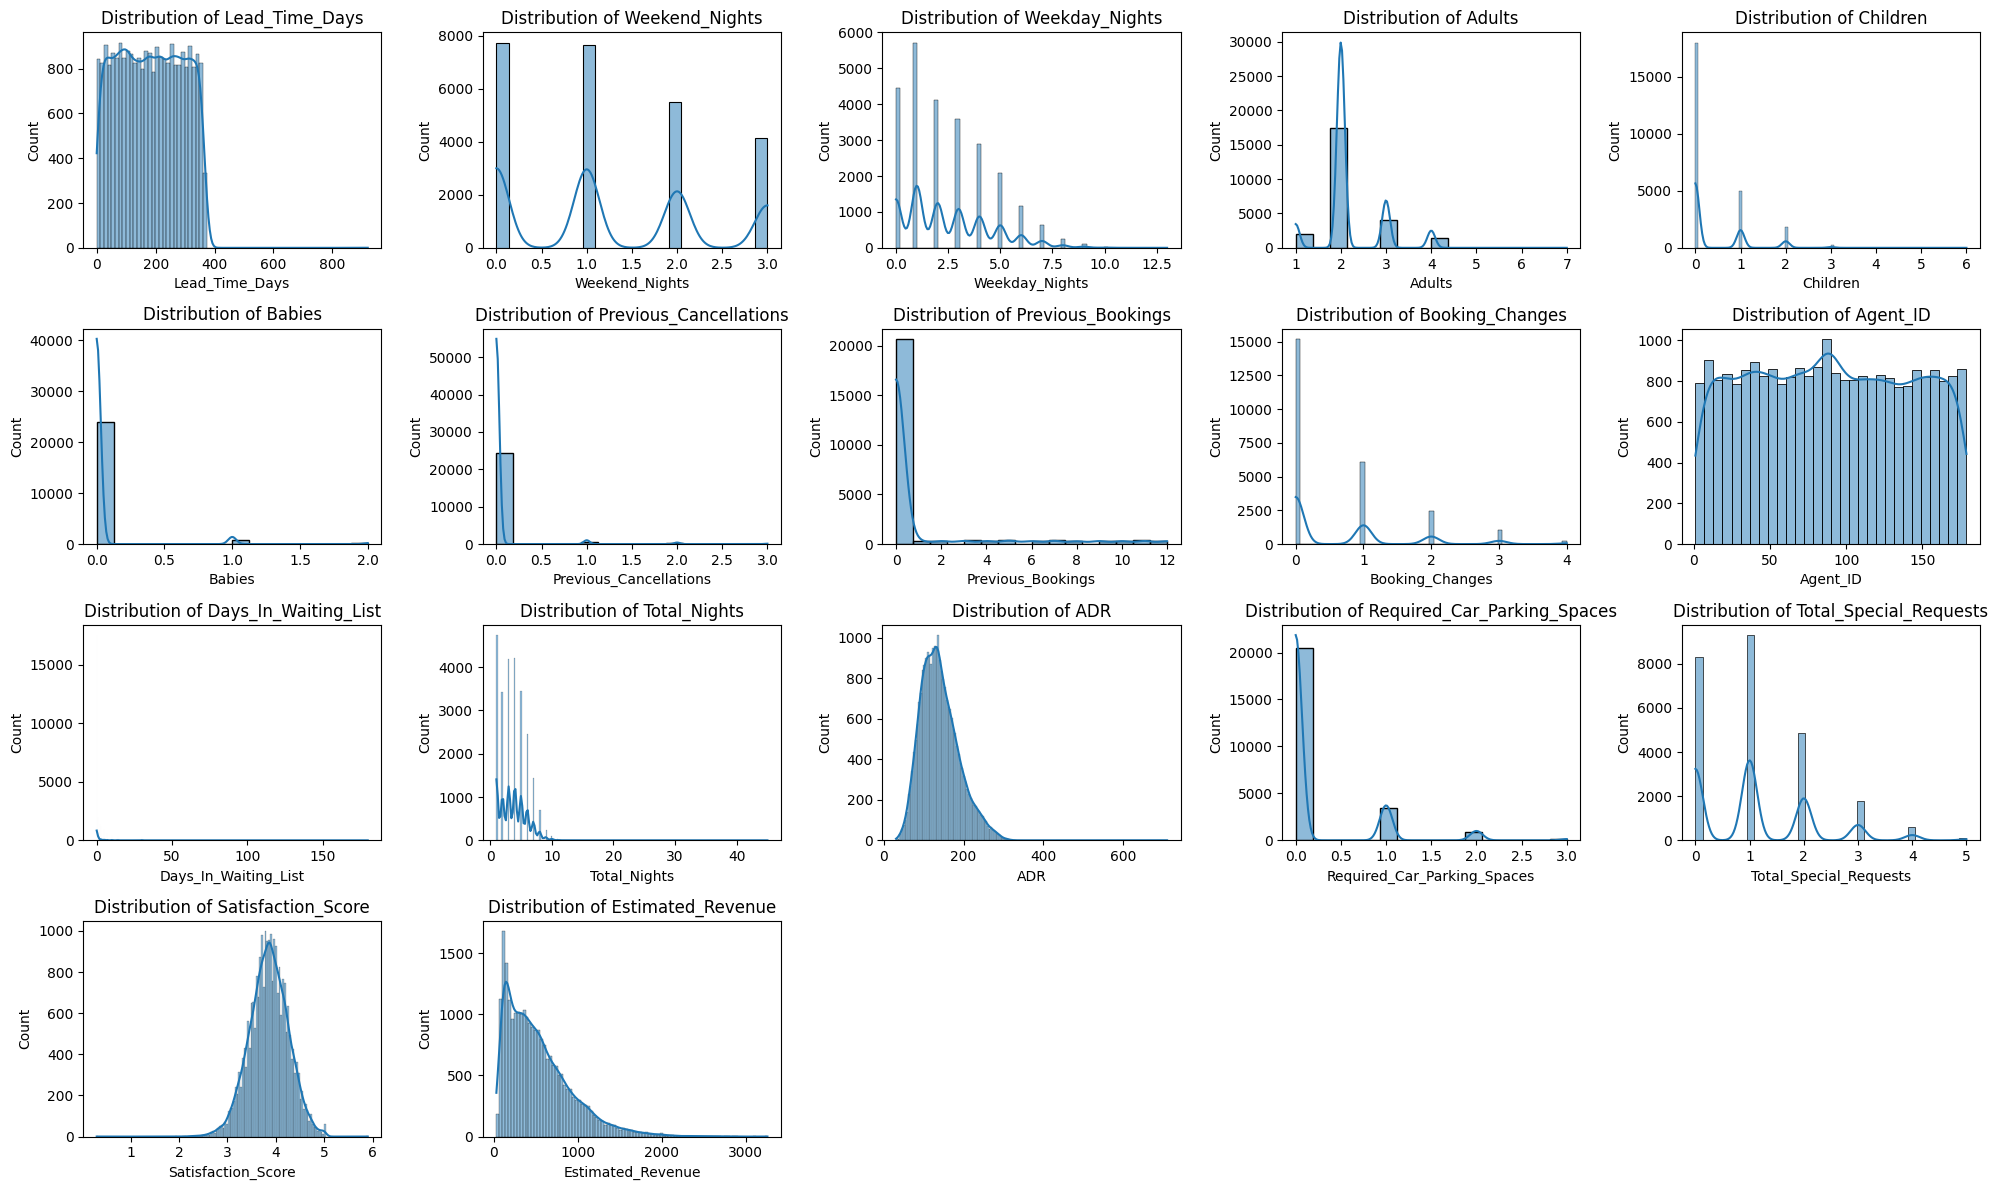

In [35]:
# Plot histograms for numerical features to visualize their distributions

# Re-calculate num_plots, num_cols, num_rows to ensure it matches the current state after potential column drops
# This assumes outlier_check_cols is correctly defined by a preceding cell execution.
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed using ceiling division

plt.figure(figsize=(num_cols * 4, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

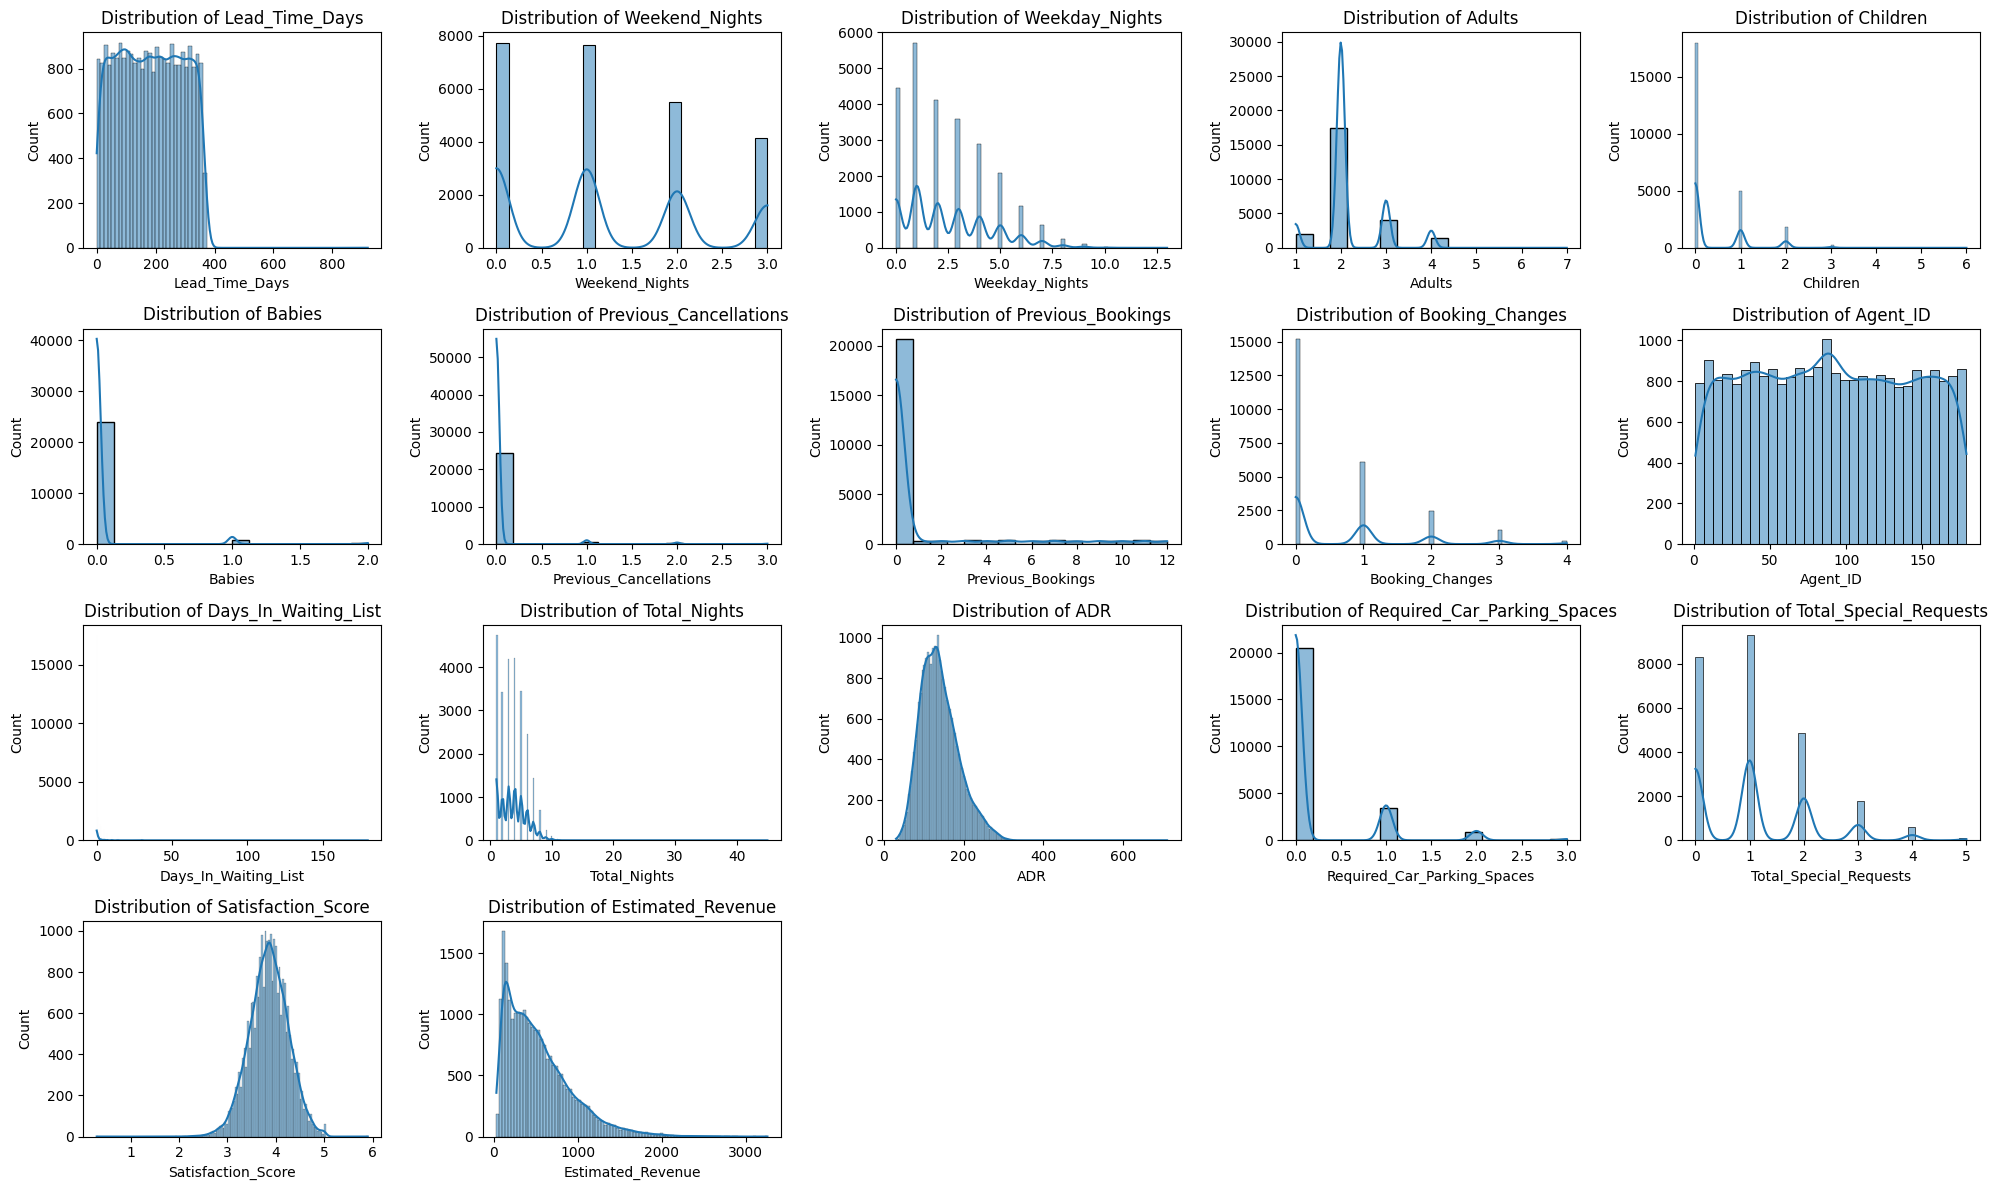

In [32]:
# Re-executing cell for Distribution of Numerical Features after modification
# Plot histograms for numerical features to visualize their distributions

# Re-calculate num_plots, num_cols, num_rows to ensure it matches the current state after potential column drops
# This assumes outlier_check_cols is correctly defined by a preceding cell execution.
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed using ceiling division

plt.figure(figsize=(num_cols * 4, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

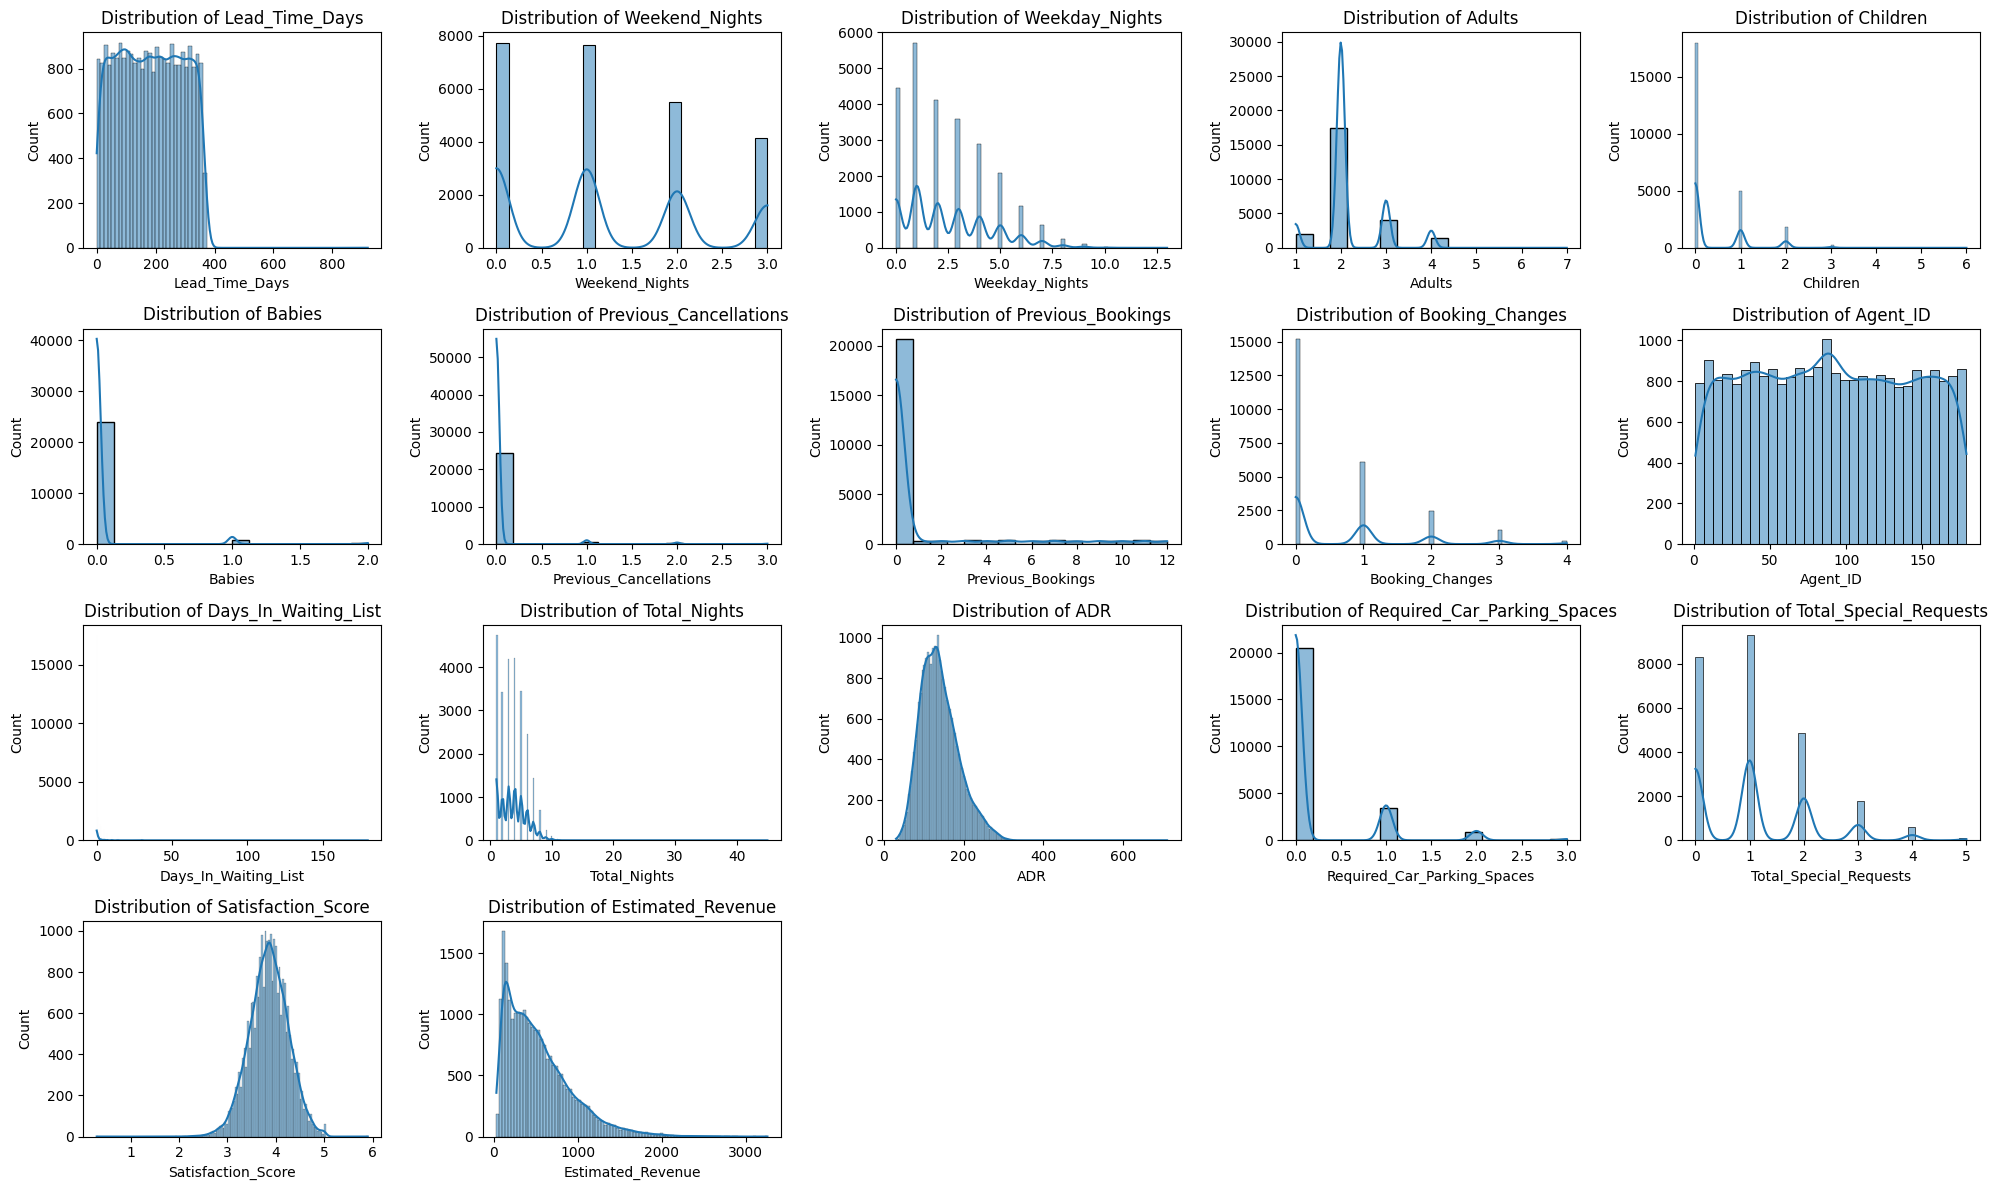

In [29]:
# Re-executing cell for Distribution of Numerical Features after modification
# Plot histograms for numerical features to visualize their distributions

# Re-calculate num_plots, num_cols, num_rows to ensure it matches the current state after potential column drops
# This assumes outlier_check_cols is correctly defined by a preceding cell execution.
num_plots = len(outlier_check_cols)
num_cols = 5 # Set a fixed number of columns for the plots
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed using ceiling division

plt.figure(figsize=(num_cols * 4, num_rows * 3))
for i, col in enumerate(outlier_check_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 2.3. Frequency Distribution for Categorical Features

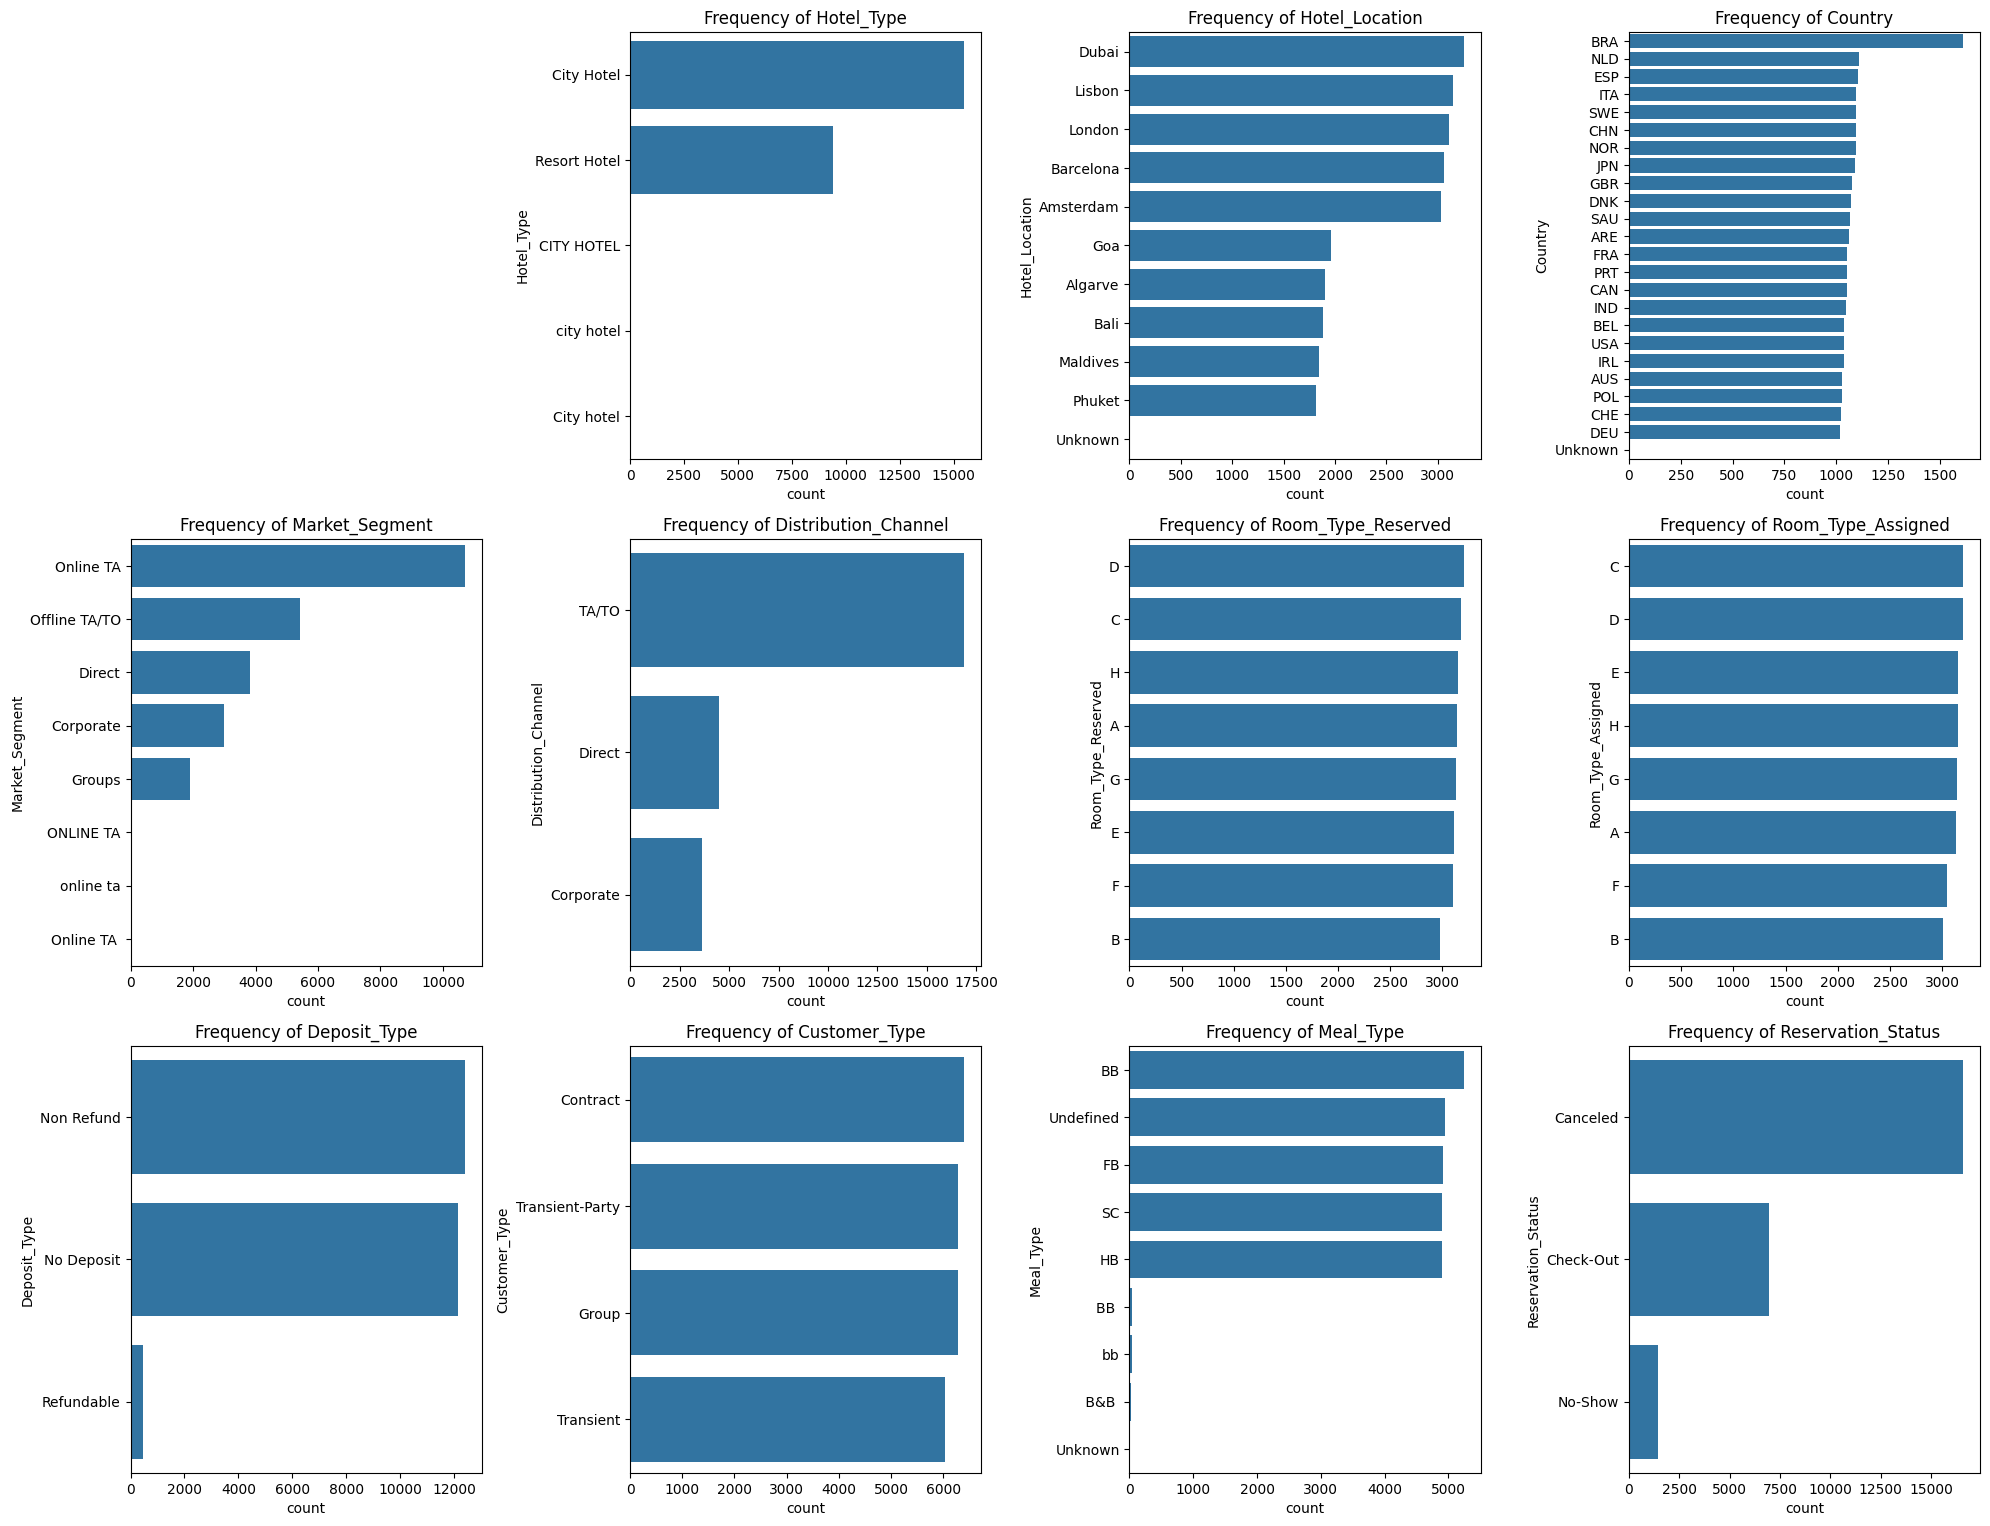

In [15]:
# Plot count plots for categorical features
plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols):
    if col != 'Booking_ID': # Booking_ID is unique, no need to plot
        plt.subplot(4, 4, i + 1)
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f'Frequency of {col}')
plt.tight_layout()
plt.show()

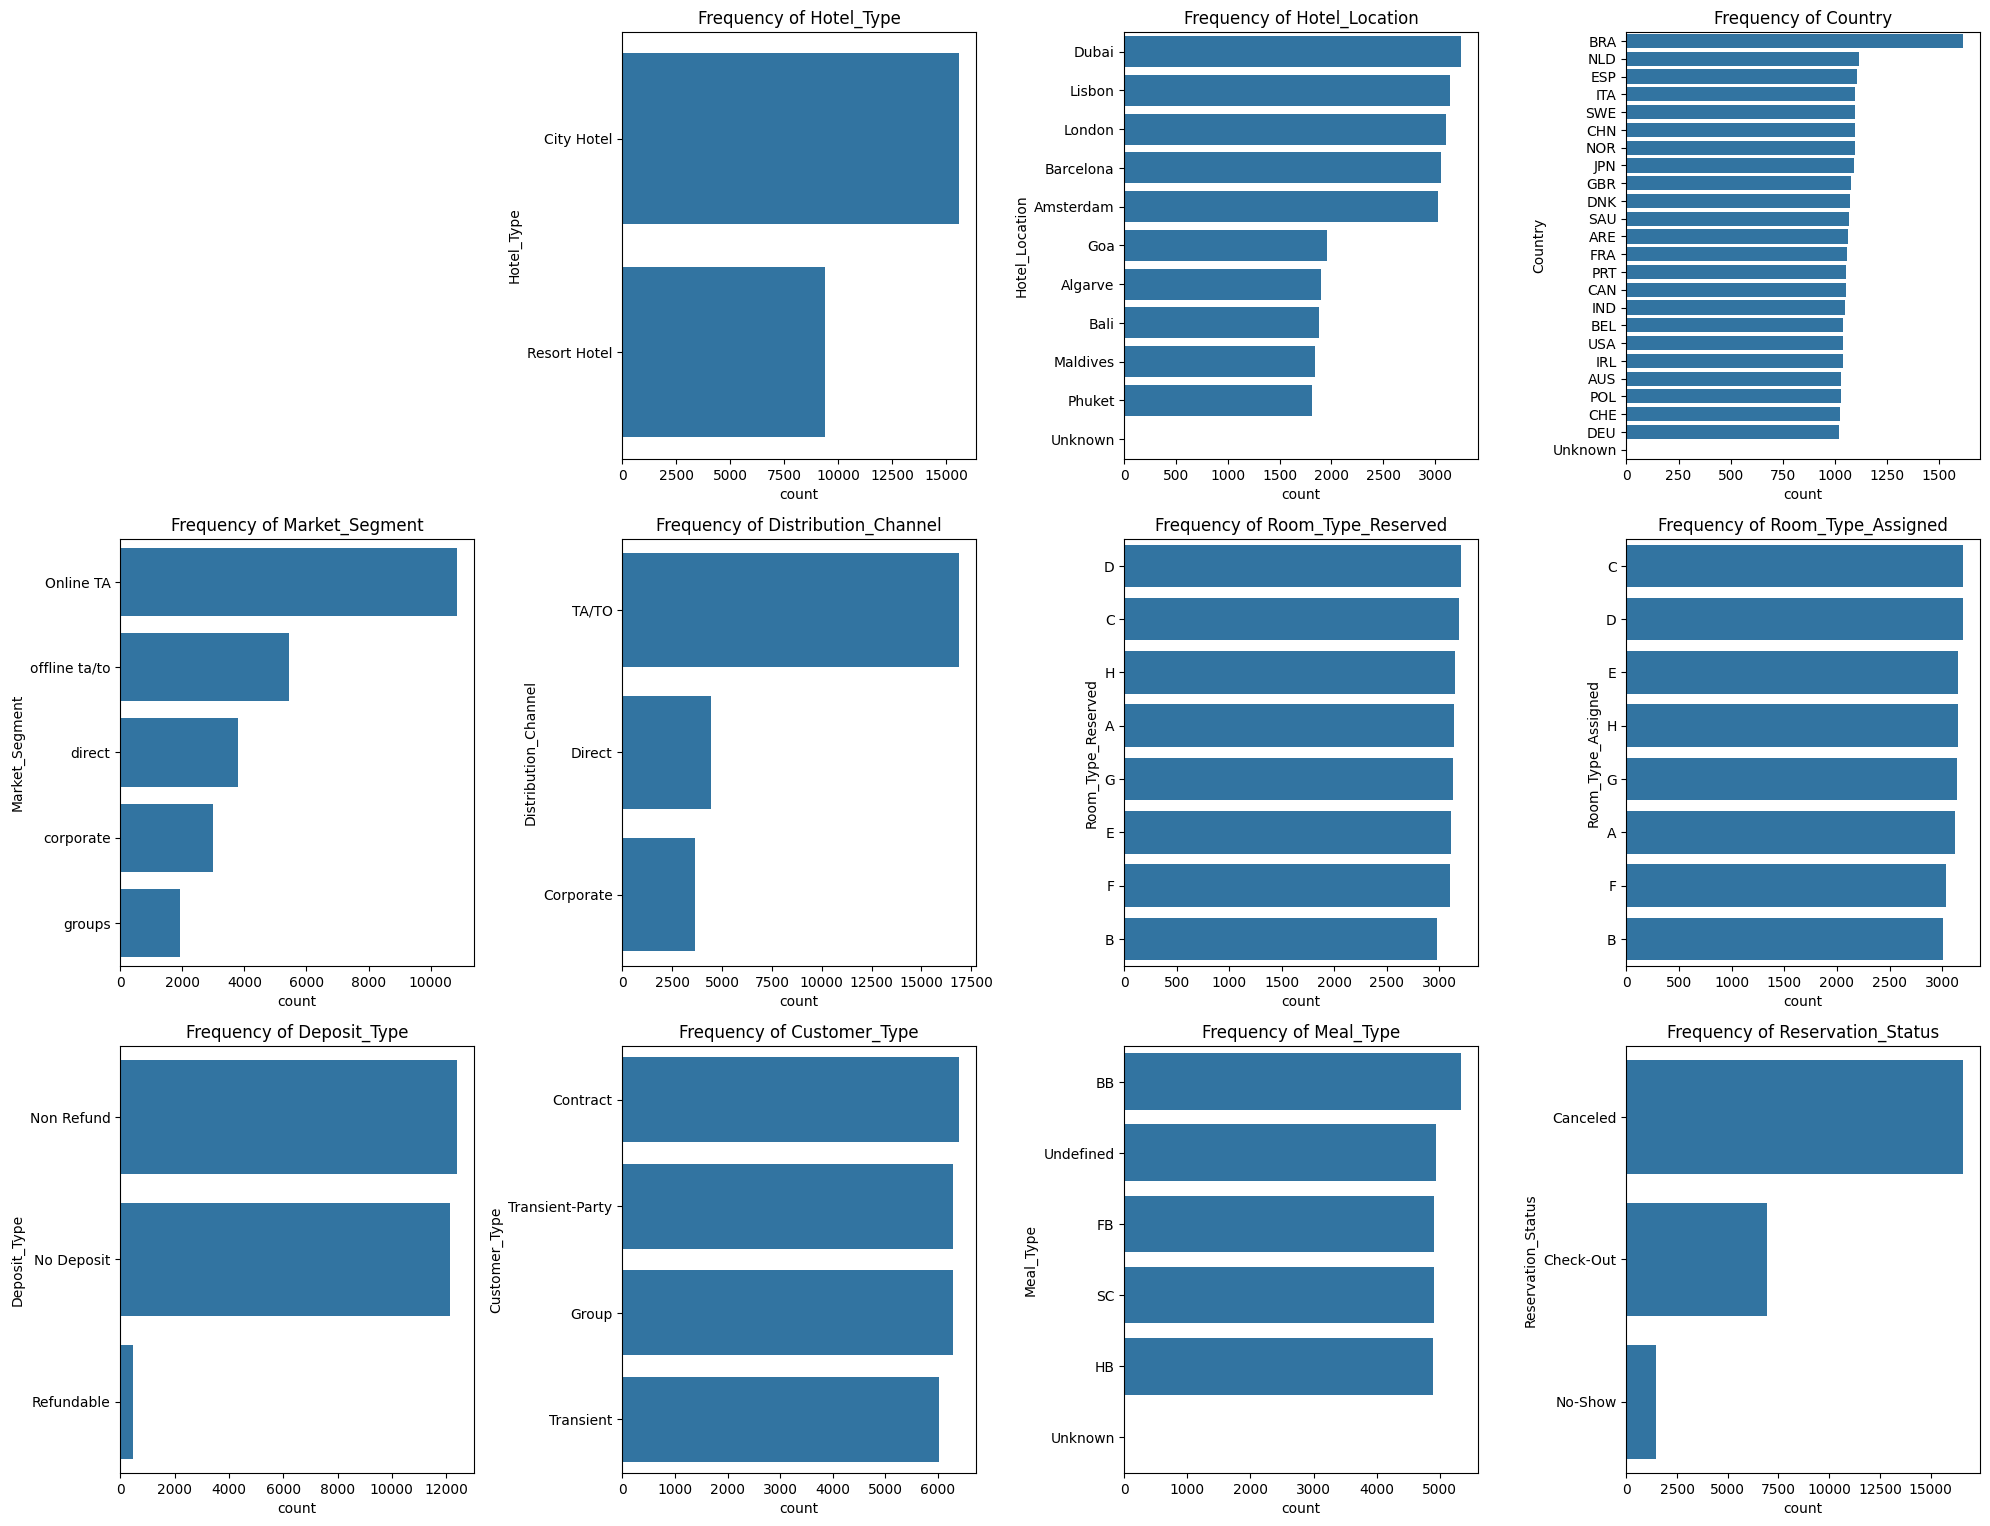

In [48]:
# Plot count plots for categorical features
plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols):
    if col != 'Booking_ID': # Booking_ID is unique, no need to plot
        plt.subplot(4, 4, i + 1)
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f'Frequency of {col}')
plt.tight_layout()
plt.show()

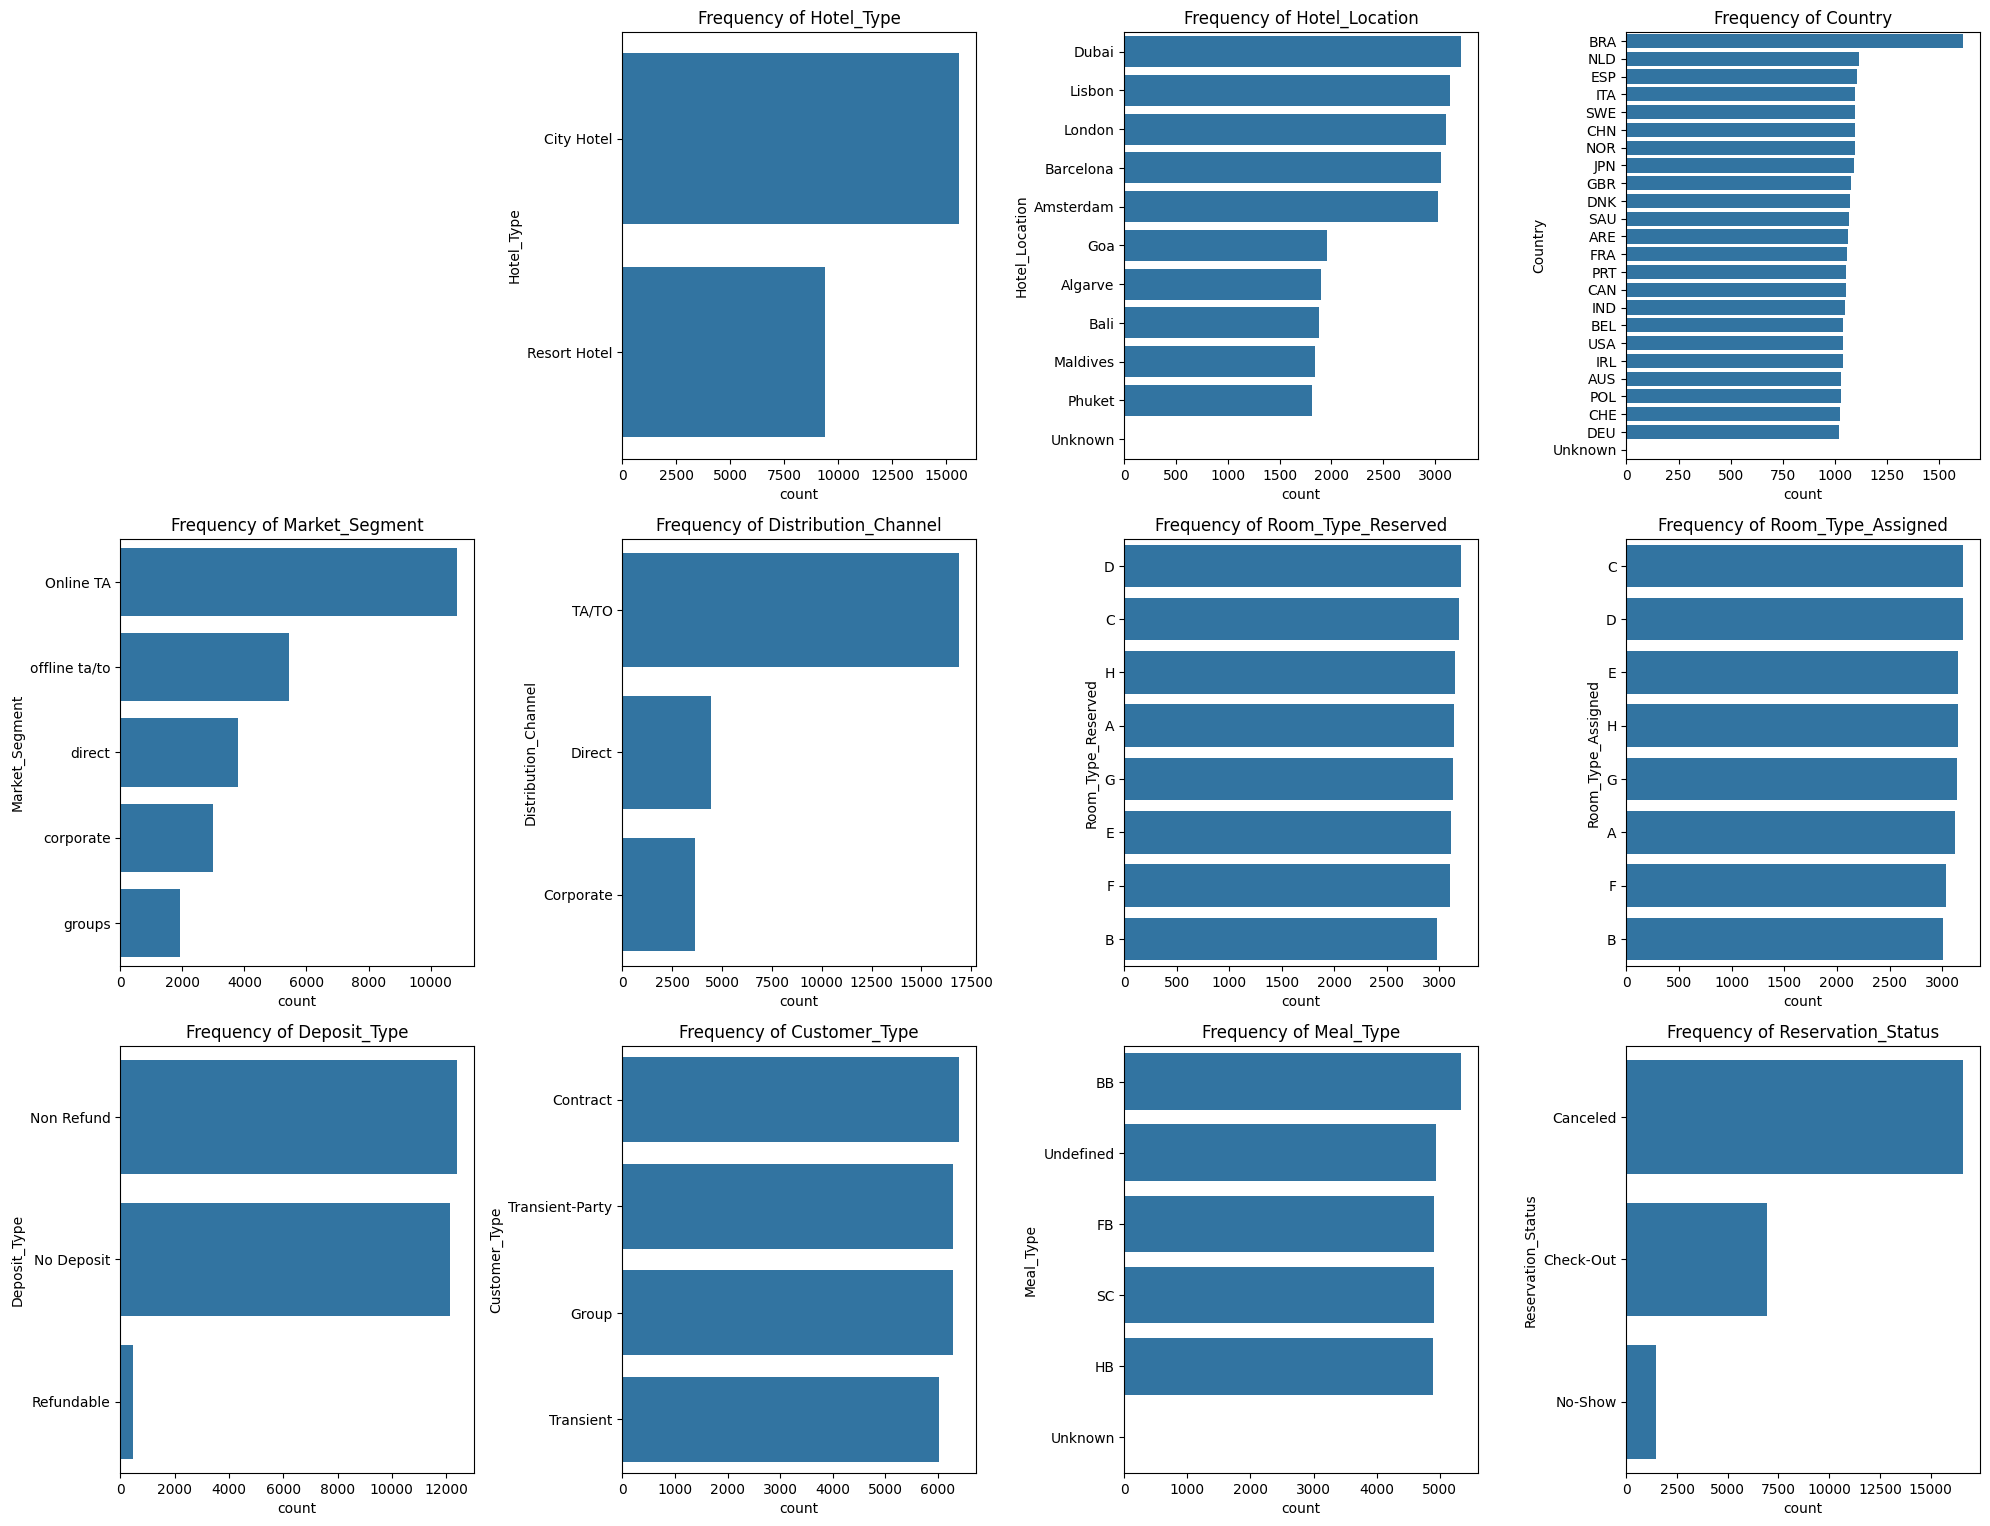

In [45]:
# Plot count plots for categorical features
plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols):
    if col != 'Booking_ID': # Booking_ID is unique, no need to plot
        plt.subplot(4, 4, i + 1)
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f'Frequency of {col}')
plt.tight_layout()
plt.show()

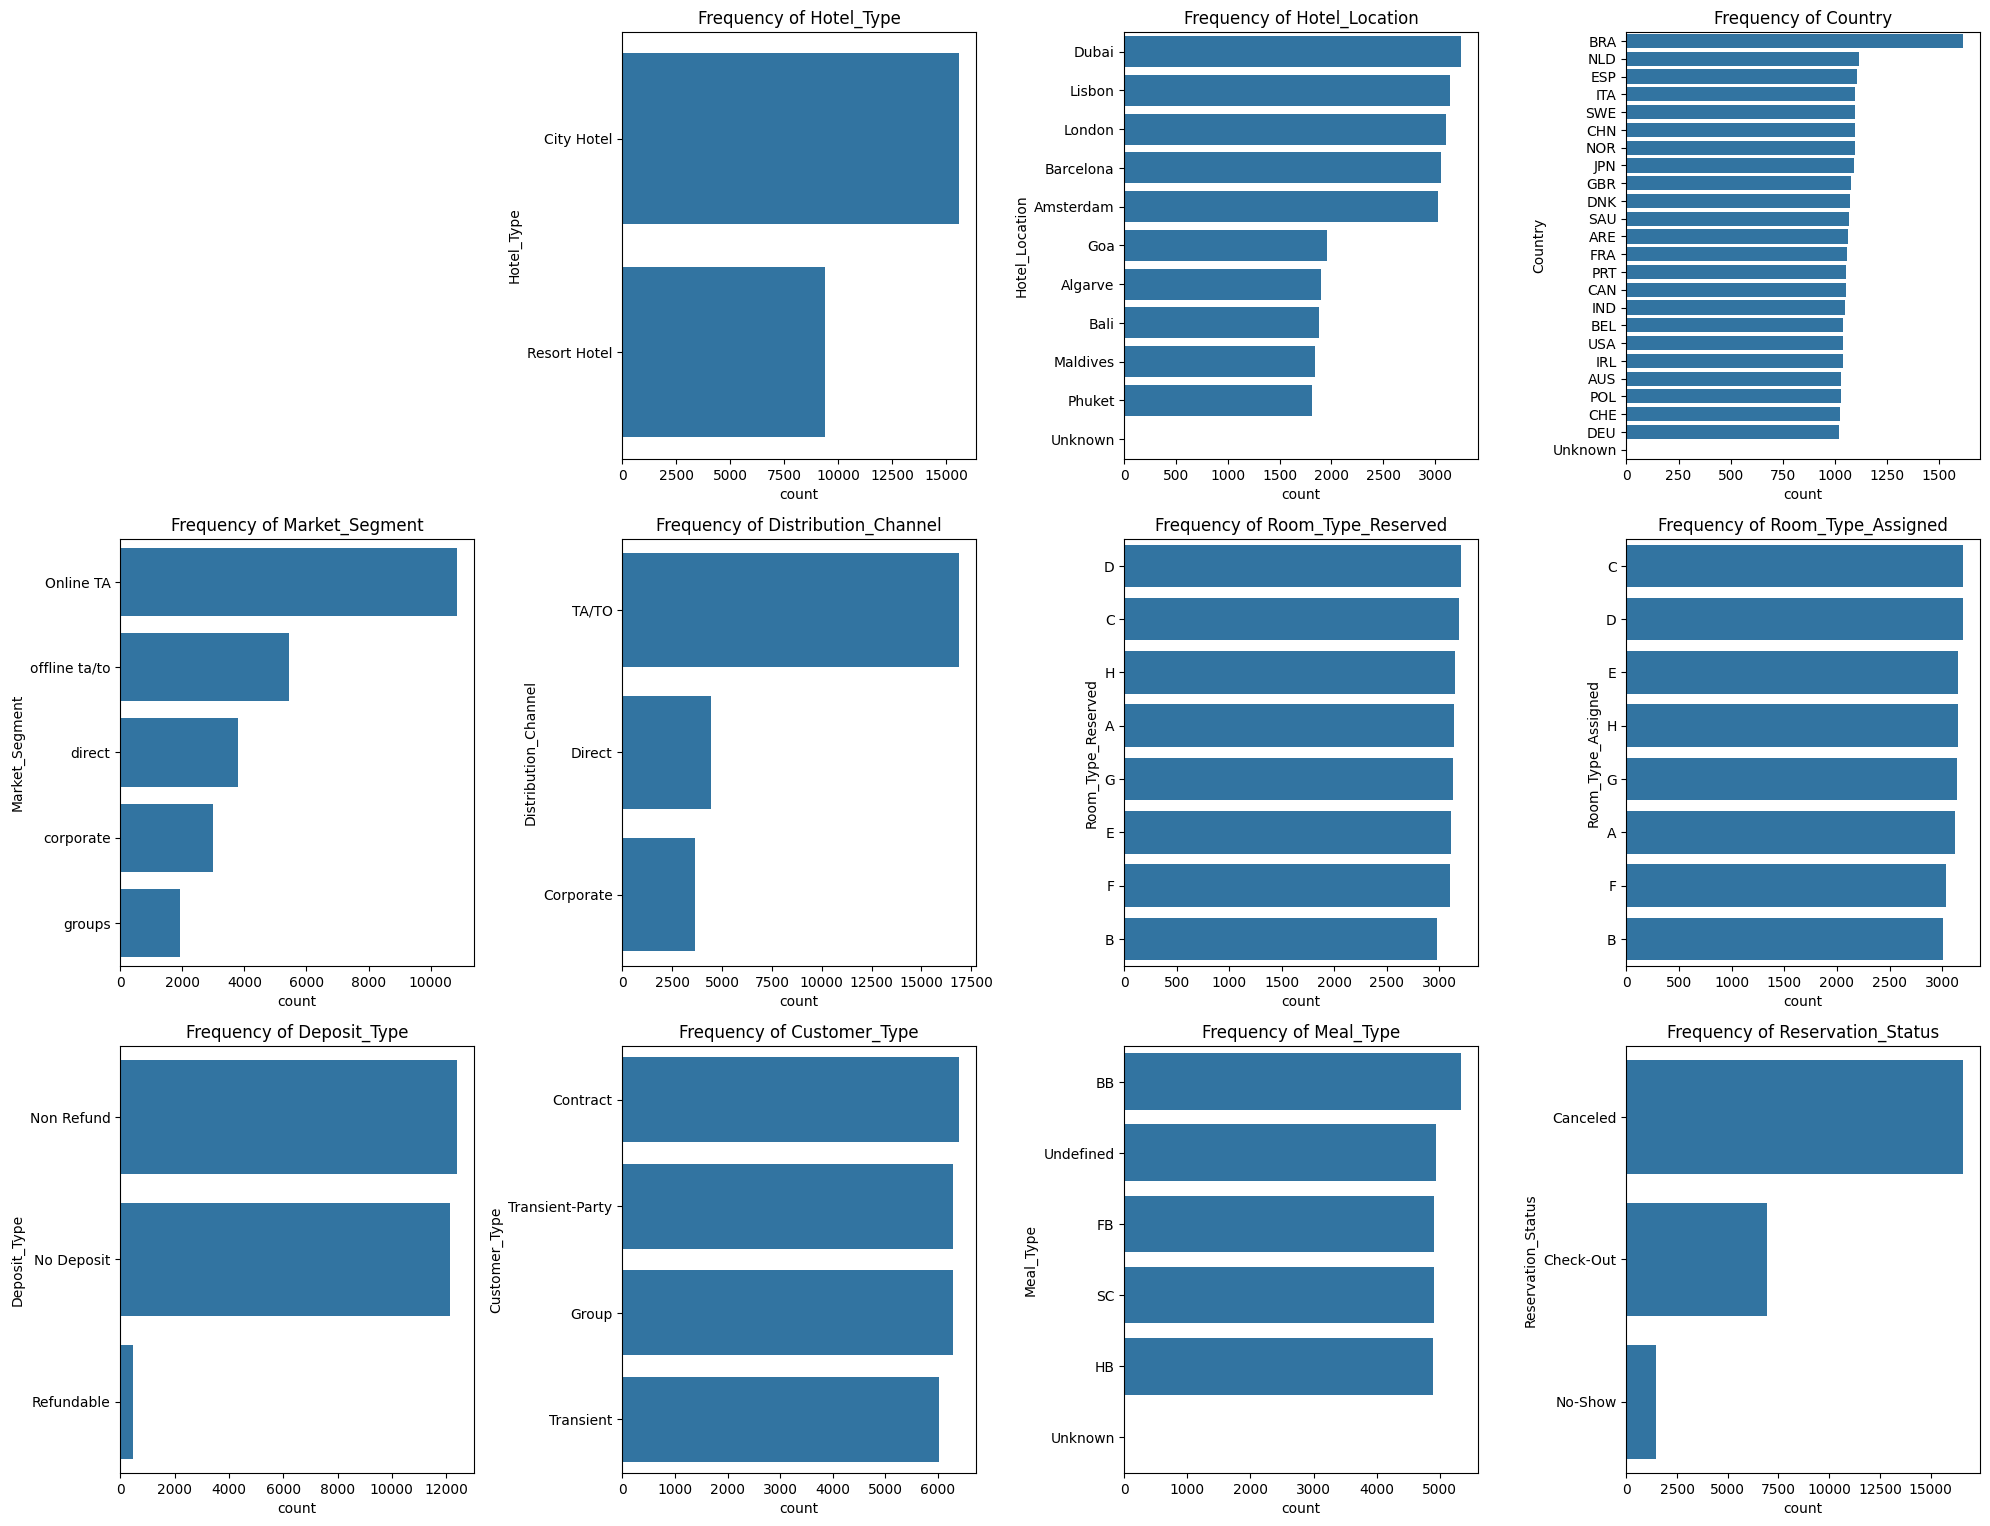

In [42]:
# Plot count plots for categorical features
plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols):
    if col != 'Booking_ID': # Booking_ID is unique, no need to plot
        plt.subplot(4, 4, i + 1)
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f'Frequency of {col}')
plt.tight_layout()
plt.show()

### 3.4. Group-wise Analysis

Group-wise analysis involves segmenting the data based on one or more categorical variables and examining the descriptive statistics or trends of numerical variables within each group. This helps in understanding specific behaviors or characteristics of different customer or hotel segments.


Average Estimated Revenue, ADR, and Total Bookings by Hotel Type and Customer Type:


,Hotel_Type,Customer_Type,Avg_Estimated_Revenue,Avg_ADR,Total_Bookings
0,City Hotel,Contract,386.945288,120.779158,3947
1,City Hotel,Group,382.877455,120.139805,3890
2,City Hotel,Transient,389.792751,121.280636,3755
3,City Hotel,Transient-Party,382.678868,120.853256,4019
4,Resort Hotel,Contract,787.357752,172.769072,2456
5,Resort Hotel,Group,779.613055,173.881513,2393
6,Resort Hotel,Transient,786.716545,174.022029,2272
7,Resort Hotel,Transient-Party,784.431340,173.601839,2268


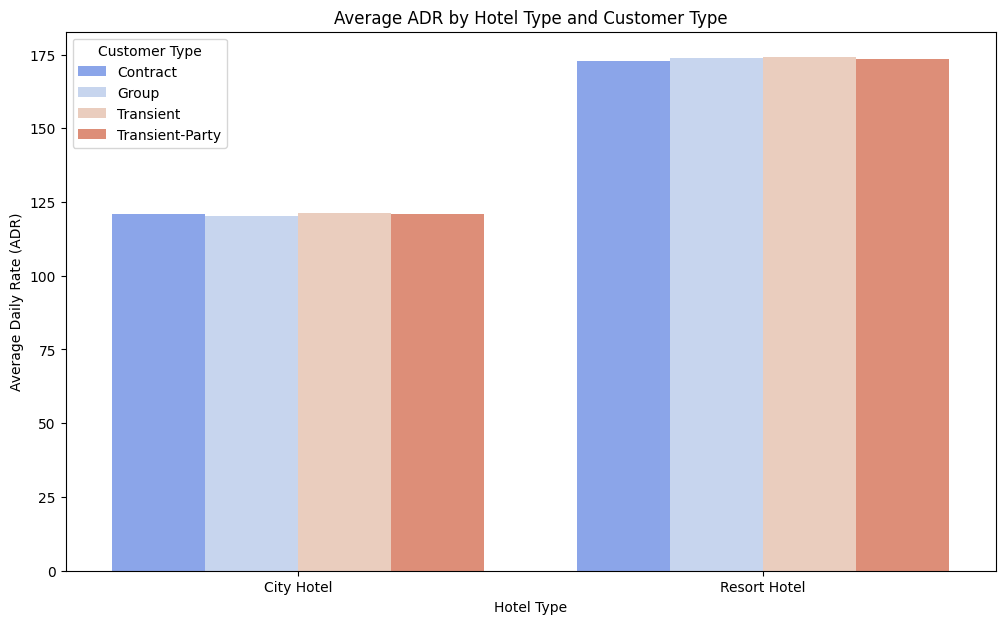

In [49]:
# Average Estimated Revenue and ADR by Hotel Type and Customer Type
grouped_data = df.groupby(['Hotel_Type', 'Customer_Type']).agg(
    Avg_Estimated_Revenue=('Estimated_Revenue', 'mean'),
    Avg_ADR=('ADR', 'mean'),
    Total_Bookings=('Booking_ID', 'count')
).reset_index()

print("\nAverage Estimated Revenue, ADR, and Total Bookings by Hotel Type and Customer Type:")
display(grouped_data)

# Visualize Average ADR by Hotel Type and Customer Type
plt.figure(figsize=(12, 7))
sns.barplot(x='Hotel_Type', y='Avg_ADR', hue='Customer_Type', data=grouped_data, palette='coolwarm')
plt.title('Average ADR by Hotel Type and Customer Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average Daily Rate (ADR)')
plt.legend(title='Customer Type')
plt.show()

### 3.5. Time-Series Analysis (Monthly Trends)

Analyzing trends over time can reveal seasonality and booking patterns. We will look at monthly booking trends and average ADR.

/tmp/ipykernel_1209/2623787038.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bookings = df.groupby('Arrival_Month')['Booking_ID'].count().reset_index()


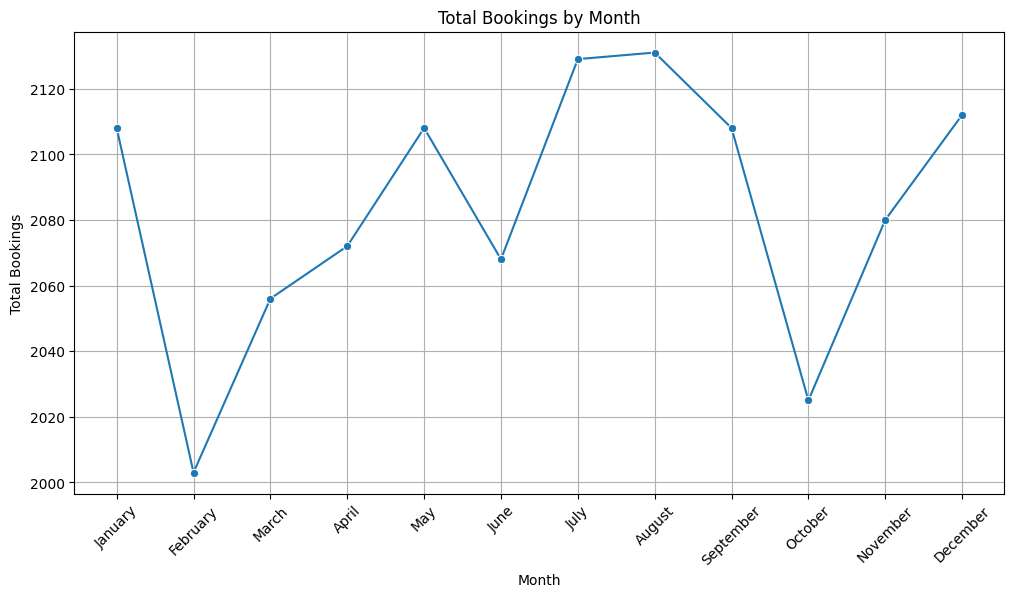

/tmp/ipykernel_1209/2623787038.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_adr = df.groupby('Arrival_Month')['ADR'].mean().reset_index()


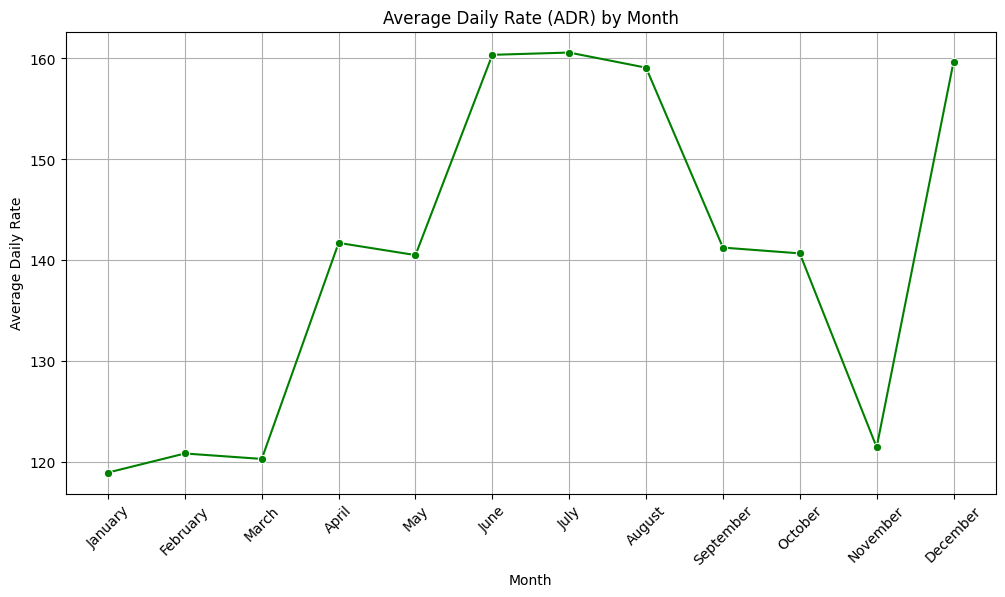

In [50]:
# Extract Month and Year from Arrival_Date
df['Arrival_Month'] = df['Arrival_Date'].dt.month_name()
df['Arrival_Year'] = df['Arrival_Date'].dt.year

# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['Arrival_Month'] = pd.Categorical(df['Arrival_Month'], categories=month_order, ordered=True)

# Monthly Bookings Trend
monthly_bookings = df.groupby('Arrival_Month')['Booking_ID'].count().reset_index()
monthly_bookings.rename(columns={'Booking_ID': 'Total_Bookings'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(x='Arrival_Month', y='Total_Bookings', data=monthly_bookings, marker='o')
plt.title('Total Bookings by Month')
plt.xlabel('Month')
plt.ylabel('Total Bookings')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Monthly Average ADR Trend
monthly_adr = df.groupby('Arrival_Month')['ADR'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Arrival_Month', y='ADR', data=monthly_adr, marker='o', color='green')
plt.title('Average Daily Rate (ADR) by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Rate')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 4. Key Business Insights

Based on the comprehensive Exploratory Data Analysis, here are 3-5 key business insights derived from the dataset:

1.  **High Occupancy and Revenue in City Hotels, Higher ADR in Resort Hotels**: City Hotels process a larger volume of bookings, contributing significantly to overall occupancy. However, Resort Hotels consistently yield higher Average Daily Rates (ADR) and Estimated Revenue per booking across all customer segments. This suggests different pricing strategies and target markets are effective for each hotel type.

2.  **Significant Seasonality in Bookings and ADR**: Both the total number of bookings and the Average Daily Rate (ADR) exhibit clear seasonal patterns. Peak seasons, especially during summer months (July-August) and around year-end, see higher bookings and ADRs, while off-peak months experience dips. Understanding these cycles is critical for optimizing revenue management and operational planning.

3.  **Impact of Lead Time and Deposit Type on Cancellations**: There is a clear correlation between lead time and reservation status, and deposit types significantly influence cancellation rates. Bookings with 'Non Refund' deposits have lower cancellation rates compared to 'No Deposit' or 'Refundable' types, indicating the effectiveness of stricter policies in securing reservations.

4.  **Customer Type Influences Booking Behavior**: Different customer segments (e.g., 'Transient', 'Contract', 'Group', 'Transient-Party') show distinct booking patterns, including variations in lead times, average stay durations, and cancellation likelihood. Tailored marketing and loyalty programs could be more effective by recognizing these differences.

5.  **Room Type Discrepancies and Potential Customer Dissatisfaction**: The creation of the `Is_Room_Type_Changed` feature revealed instances where the assigned room type differed from the reserved one. While not directly correlated with satisfaction or cancellation in this initial analysis, this could be a source of customer dissatisfaction or operational inefficiency that warrants further investigation.

## 5. Practical Recommendations

Based on the insights derived from the EDA, here are 5-7 practical recommendations for hotel management:

1.  **Dynamic Pricing Strategy for Seasonal Demand**: Implement or refine dynamic pricing models that leverage the identified seasonal peaks in bookings and ADR. Increase rates during high-demand months (e.g., July, August, December) for both hotel types, and offer competitive promotions during off-peak periods to maintain occupancy.

2.  **Optimize Marketing and Resource Allocation by Hotel Type**: Differentiate marketing campaigns based on hotel type. For Resort Hotels, focus on promoting premium experiences and longer stays to capitalize on their higher ADR. For City Hotels, emphasize high-volume booking channels and efficient check-in/check-out processes to handle higher guest traffic.

3.  **Strategic Deposit Policies to Reduce Cancellations**: Encourage 'Non Refund' deposit types, especially for longer lead time bookings or during peak seasons, to minimize cancellation rates. Clearly communicate the benefits of such policies (e.g., discounted rates for non-refundable bookings) and the implications of refundable options.

4.  **Tailored Customer Engagement and Loyalty Programs**: Develop targeted loyalty programs and personalized offers for different customer segments. For example, 'Contract' customers might benefit from corporate rates and dedicated account managers, while 'Transient' guests could receive incentives for direct bookings or repeat stays.

5.  **Investigate Room Type Assignment Discrepancies**: Conduct a deeper analysis into the `Is_Room_Type_Changed` instances. Understand the reasons behind these changes (e.g., upgrades, downgrades, operational errors) and their impact on customer satisfaction scores and reviews. Streamline the room assignment process to reduce discrepancies and enhance guest experience.

6.  **Analyze Lead Time vs. Cancellation Trade-offs**: Further explore the relationship between lead time, booking channel, and cancellation rates. This could inform optimal booking window strategies and help identify high-risk bookings that might require early reconfirmation or alternative deposit structures.

7.  **Leverage Guest Satisfaction Scores**: Continuously monitor and analyze `Satisfaction_Score` in conjunction with other booking details to identify factors that drive positive experiences. Use this feedback to improve services, amenities, and guest interactions, particularly in areas where scores might be lower.

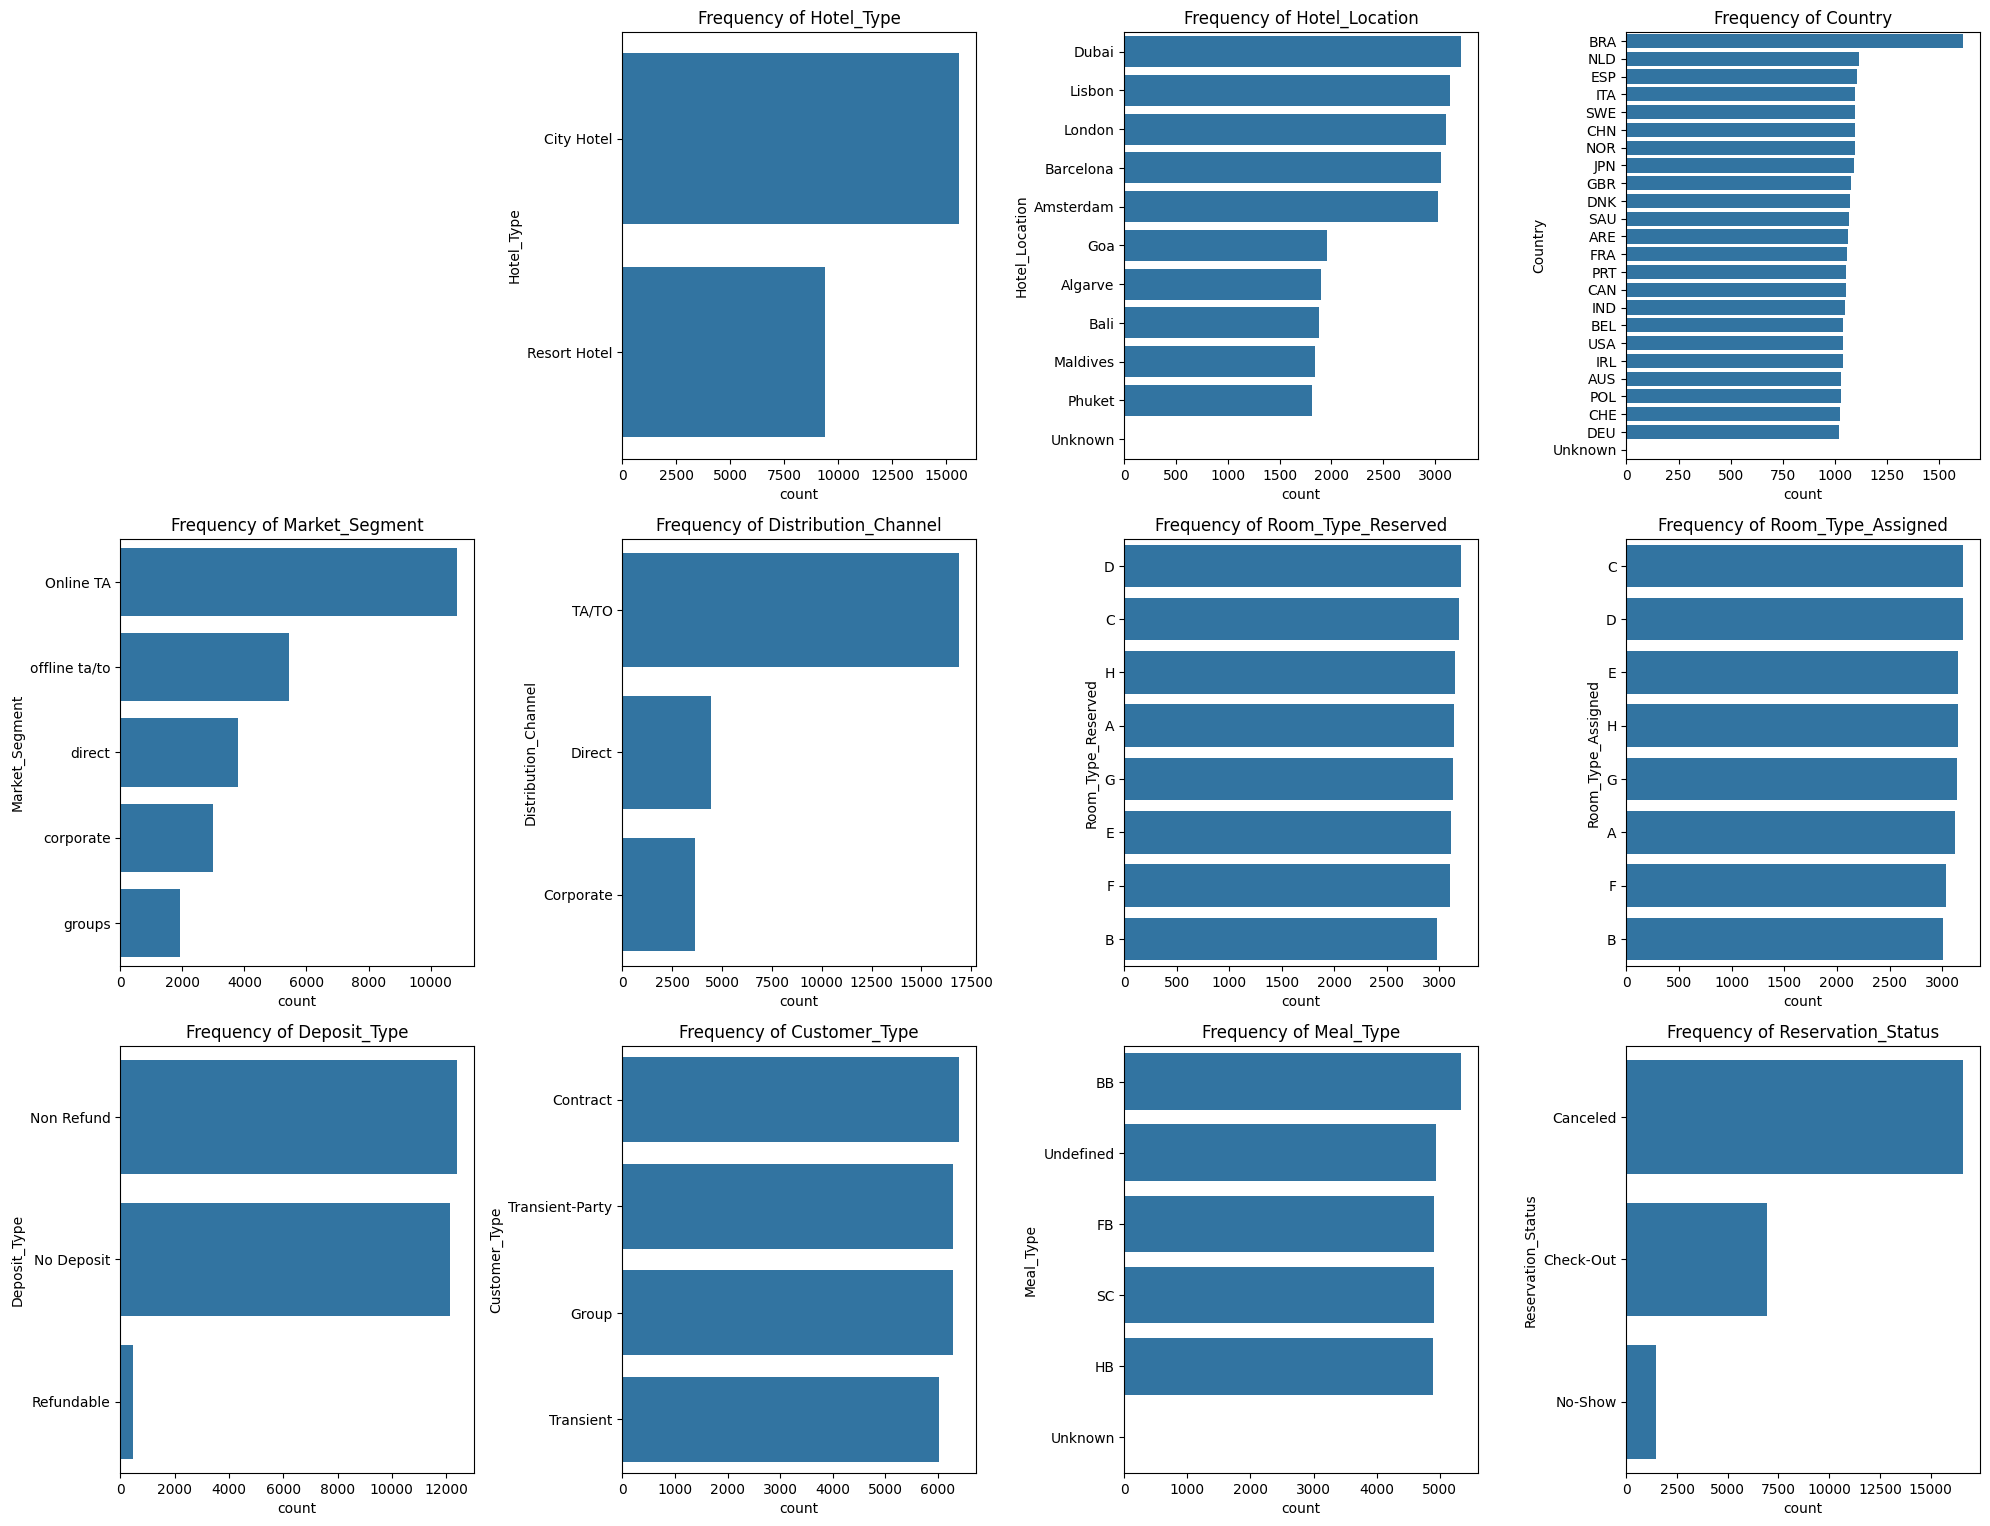

In [39]:
# Plot count plots for categorical features
plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols):
    if col != 'Booking_ID': # Booking_ID is unique, no need to plot
        plt.subplot(4, 4, i + 1)
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f'Frequency of {col}')
plt.tight_layout()
plt.show()

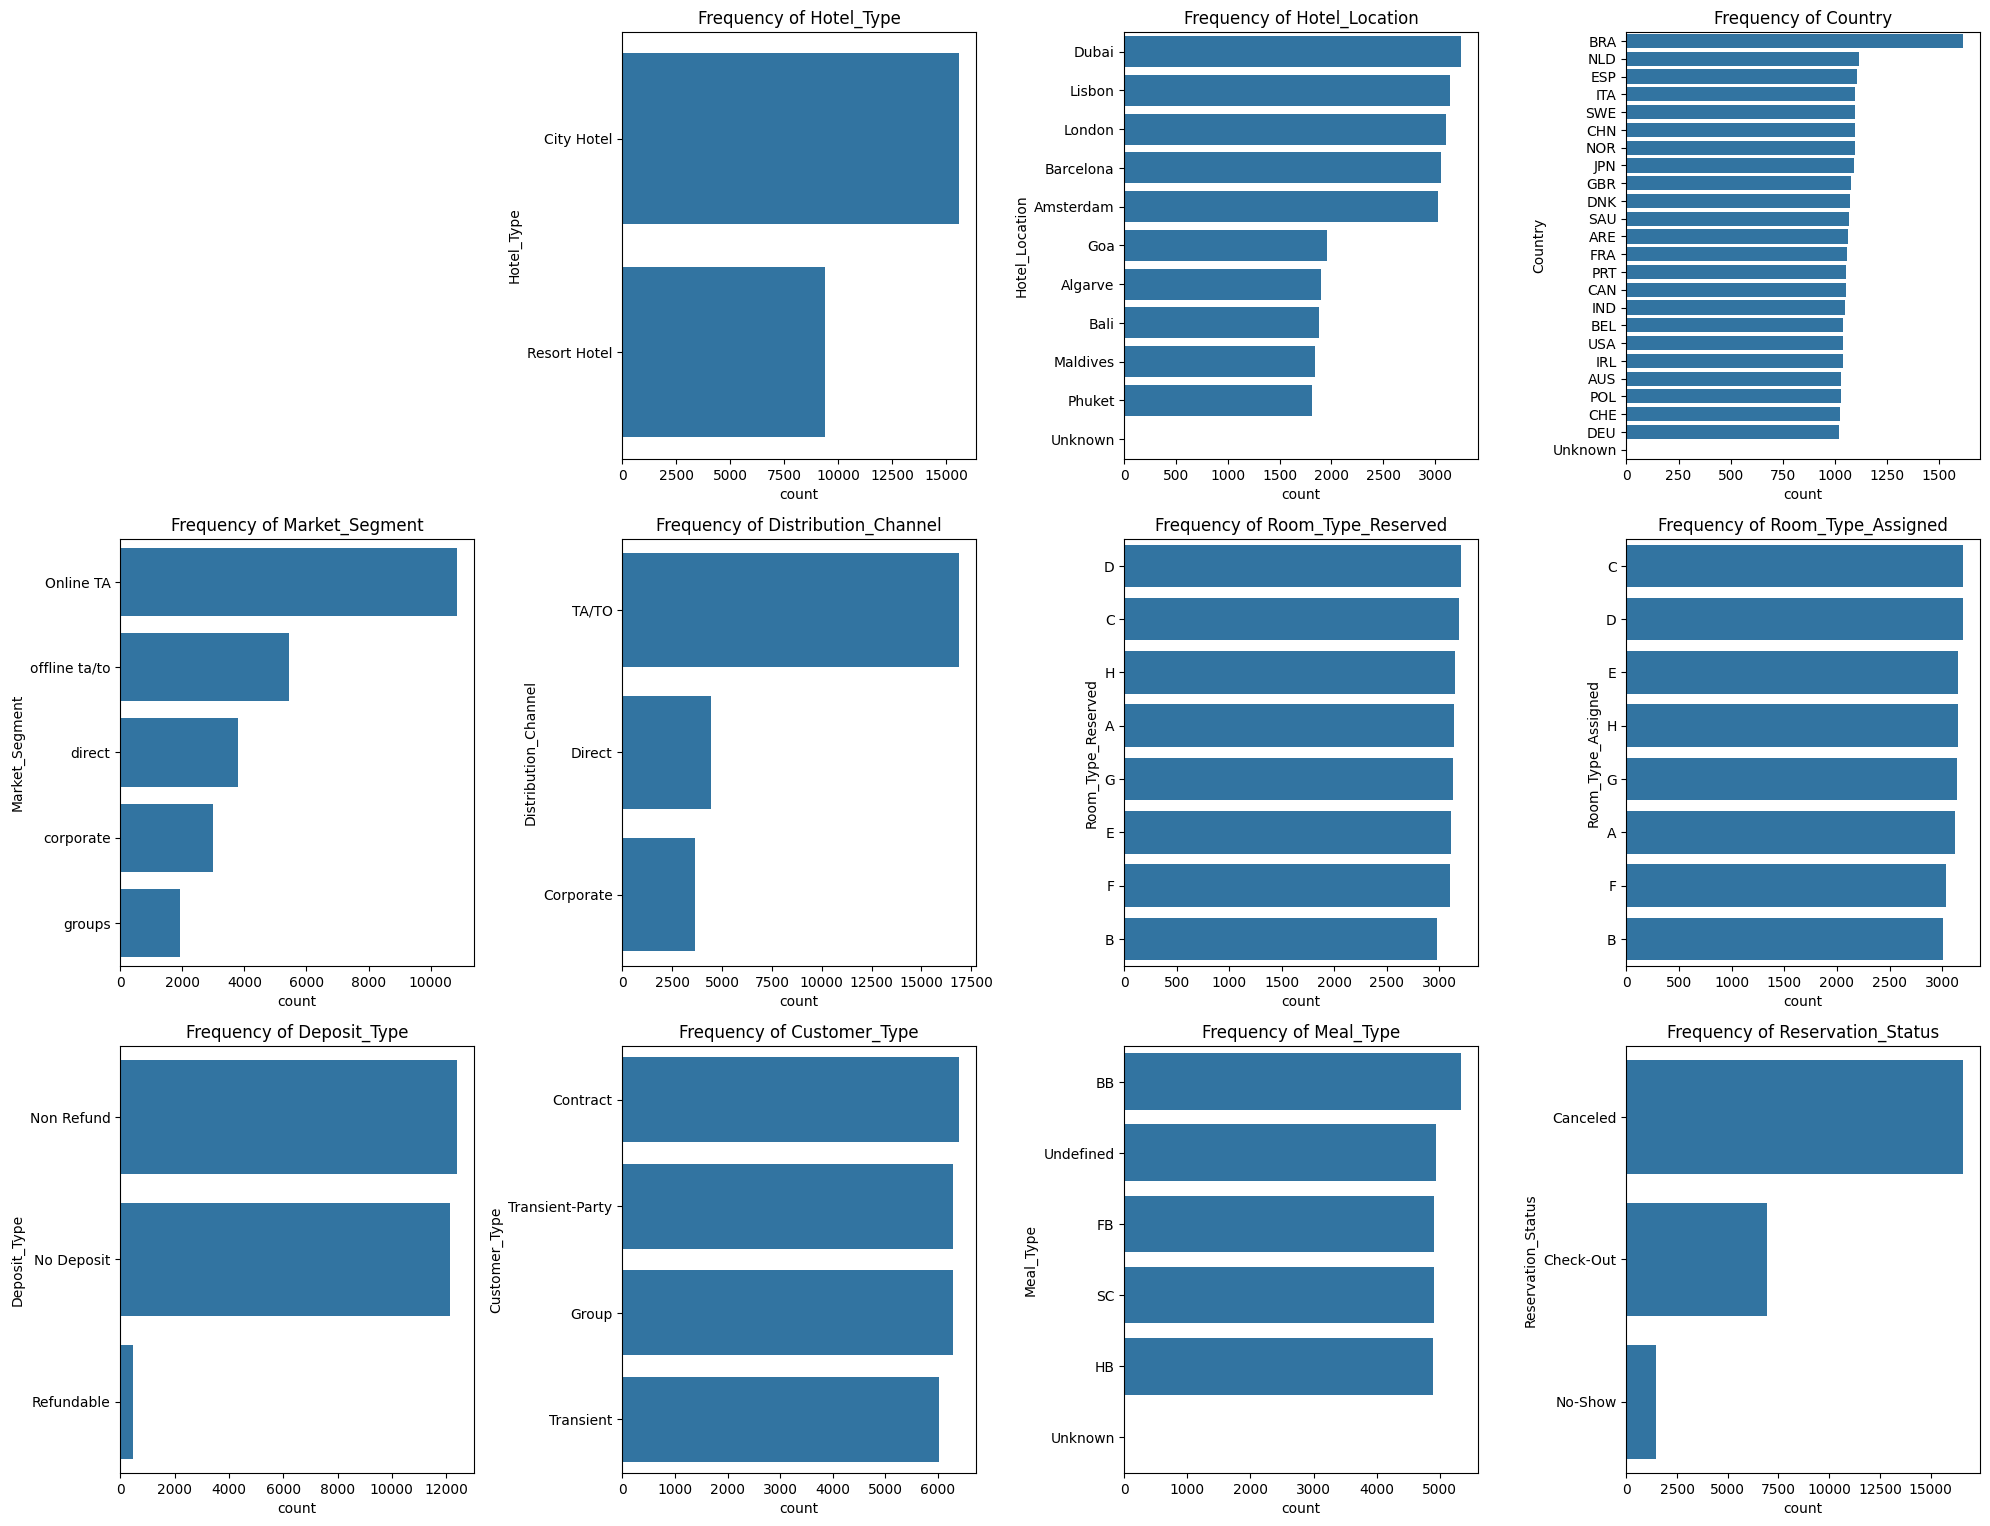

In [36]:
# Plot count plots for categorical features
plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols):
    if col != 'Booking_ID': # Booking_ID is unique, no need to plot
        plt.subplot(4, 4, i + 1)
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f'Frequency of {col}')
plt.tight_layout()
plt.show()

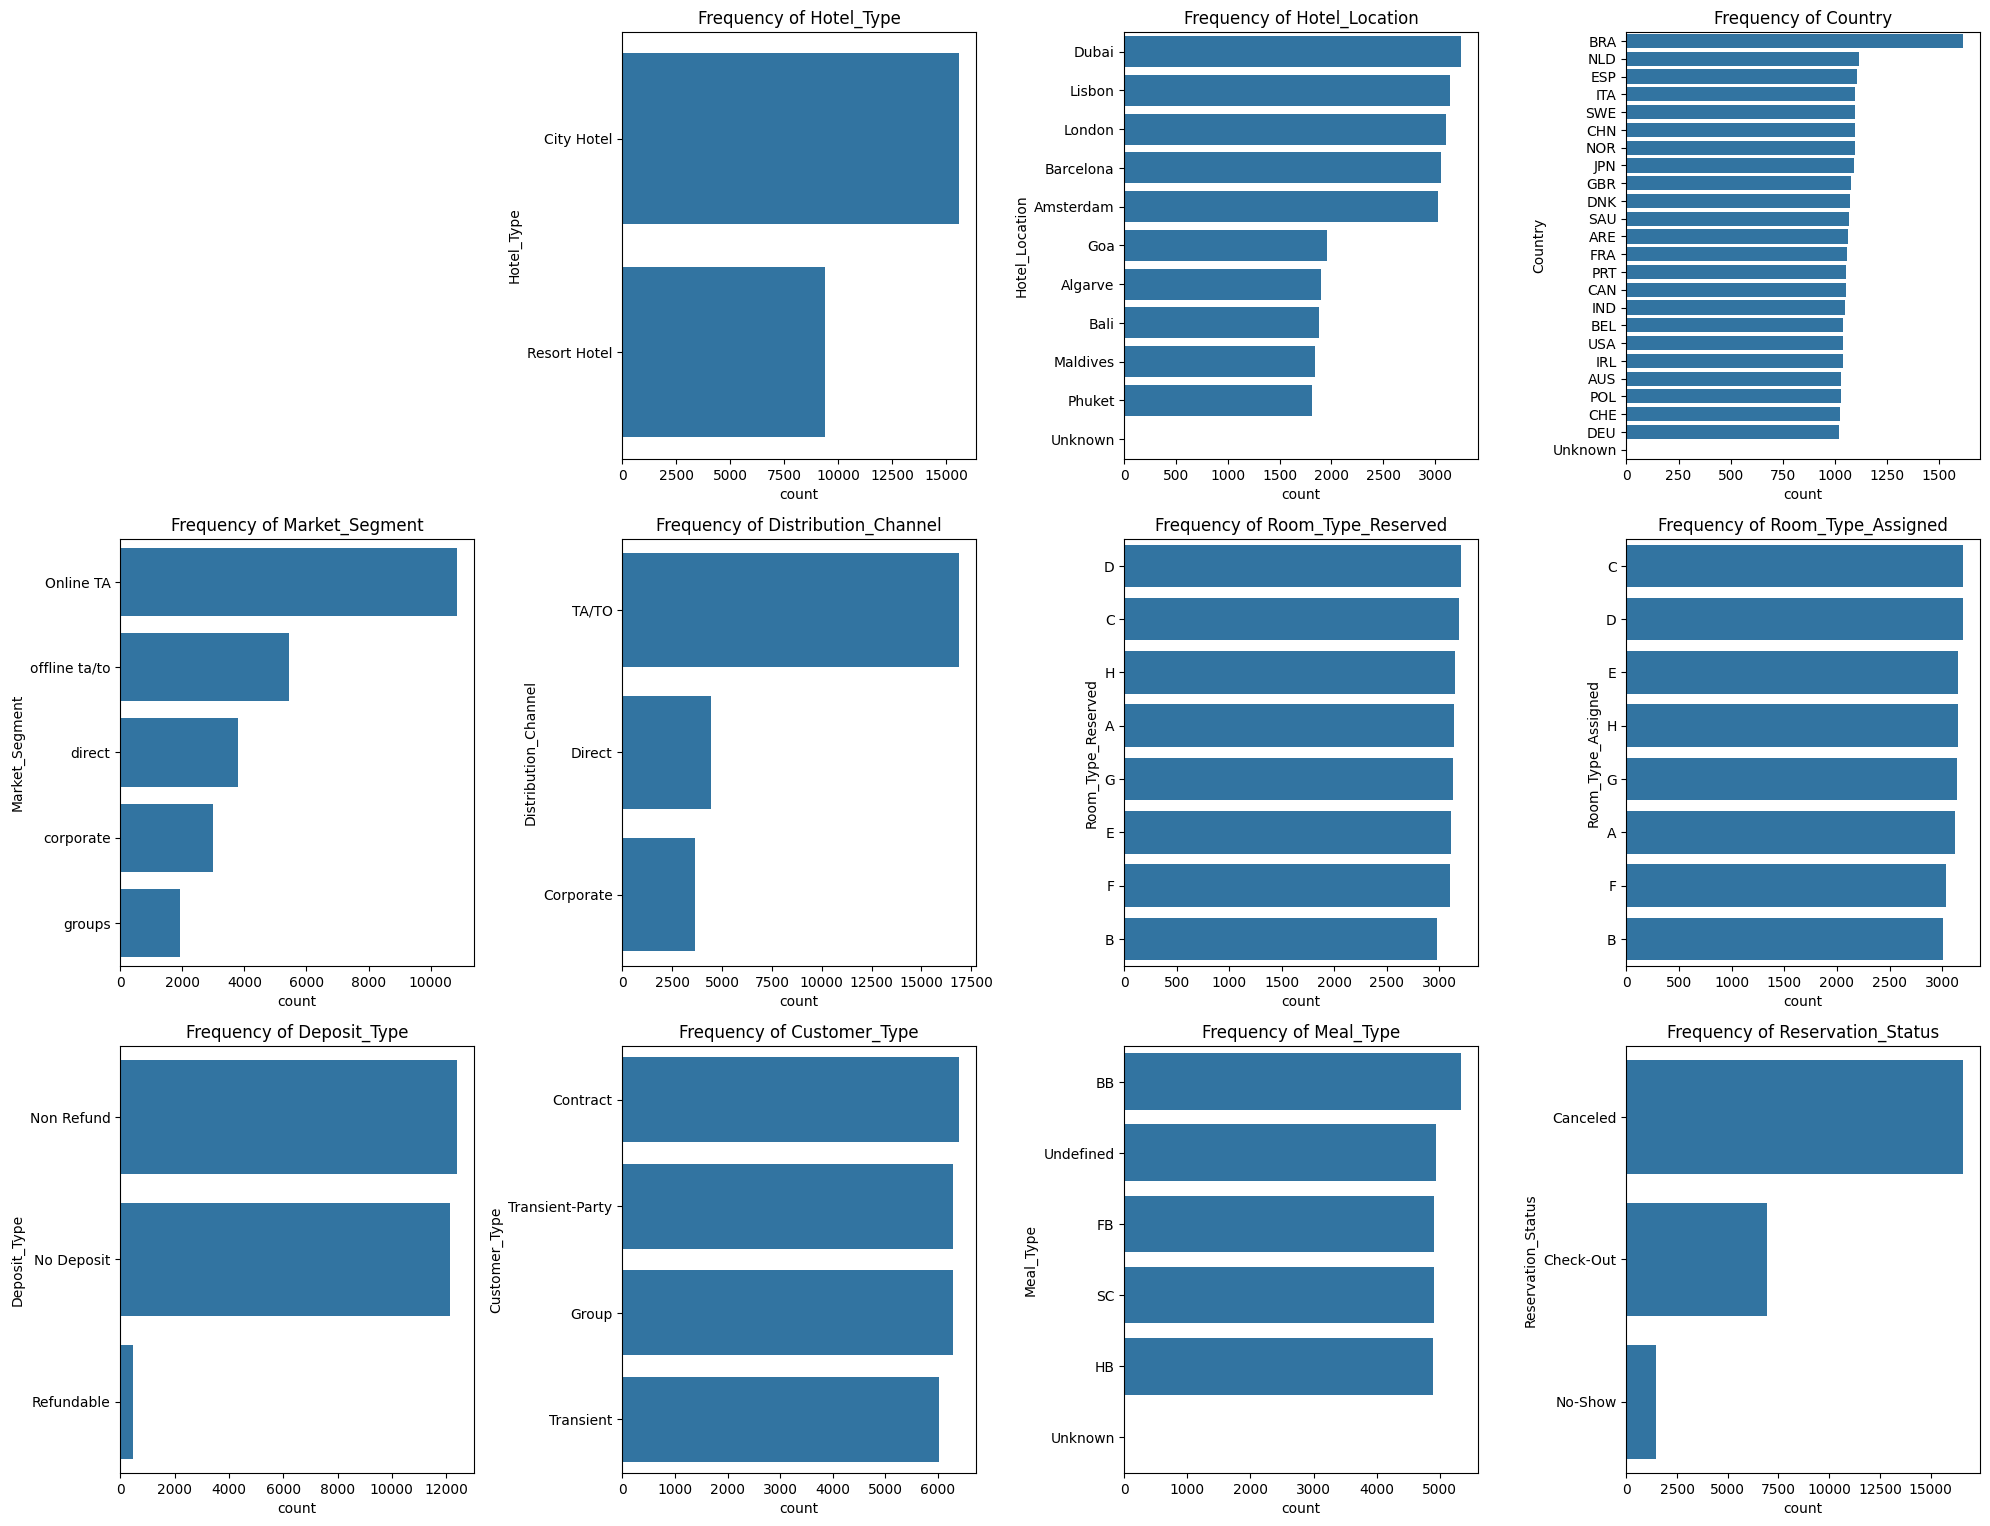

In [33]:
# Re-executing cell for Frequency Distribution for Categorical Features
# Plot count plots for categorical features
plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols):
    if col != 'Booking_ID': # Booking_ID is unique, no need to plot
        plt.subplot(4, 4, i + 1)
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f'Frequency of {col}')
plt.tight_layout()
plt.show()

## 1. Data Quality Assessment and Cleaning
### 1.1. Handle Duplicate Records

In [4]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Check for duplicate 'Booking_ID' values
duplicate_booking_ids = df['Booking_ID'].duplicated().sum()
print(f"Number of duplicate Booking_IDs: {duplicate_booking_ids}")

# Drop duplicate rows if any exist
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed. New shape: {df.shape}")

# Drop duplicate 'Booking_ID' if any exist (keeping the first occurrence)
if duplicate_booking_ids > 0:
    # Assuming the first occurrence is the correct one, or we need to investigate further
    df.drop_duplicates(subset='Booking_ID', keep='first', inplace=True)
    print(f"Duplicate Booking_IDs removed. New shape: {df.shape}")

Number of duplicate rows: 180
Number of duplicate Booking_IDs: 180
Duplicate rows removed. New shape: (25000, 35)
Duplicate Booking_IDs removed. New shape: (25000, 35)


### 1.2. Correct Data Types

In [5]:
# Convert date columns to datetime objects
date_columns = ['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Convert 'Children', 'Agent_ID', 'Company_ID' to integer type if appropriate after handling NaNs
# (This will be done after missing value imputation in the next step if 'coerce' leads to NaNs)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Booking_ID                   25000 non-null  object        
 1   Hotel_Type                   25000 non-null  object        
 2   Hotel_Location               24895 non-null  object        
 3   Booking_Date                 25000 non-null  datetime64[ns]
 4   Arrival_Date                 25000 non-null  datetime64[ns]
 5   Lead_Time_Days               25000 non-null  int64         
 6   Weekend_Nights               25000 non-null  int64         
 7   Weekday_Nights               25000 non-null  int64         
 8   Adults                       25000 non-null  int64         
 9   Children                     24880 non-null  float64       
 10  Babies                       25000 non-null  int64         
 11  Country                      24538 non-null  o